# PSD Parameter Estimation Across an Extended 1D Linear PDE Library — Clean Master


For a linear PDE,
\[
\widehat u(k,t)=\widehat u(k,0)e^{\lambda(k)t},
\qquad
P(k,t)=P(k,0)e^{2\operatorname{Re}\lambda(k)t},
\]
hence for known elapsed time,
\[
\boxed{\operatorname{Re}\lambda(k)=\frac{1}{2t}\log\frac{P(k,t)}{P(k,0)}}.
\]

**Structural-identifiability controls:** advection and third-order dispersion are phase-only; linear loss identifies \(R-\eta\); and SH mixtures can share \(k^2/k^4\) powers with explicit diffusion/hyperdiffusion.

## 0. Imports and run controls

In [1]:
import os, math, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import linregress
from scipy.special import lambertw
from numpy.fft import fft, ifft, fftfreq
from IPython.display import display

np.random.seed(42)
plt.rcParams.update({"figure.dpi":110, "font.size":10})

FULL_RESOLUTION = False
nx = 2048 if FULL_RESOLUTION else 512
L_um = 2500.0
dx_um = L_um / nx

dt = 0.05
n_frames = 30
times = np.arange(n_frames)*dt
FRAME_LIST = [5,10,15,20,25,29]
FRAME_T = 25
SNAP_FRAME = 28

K_MAX = 0.08
K_MIN_SNAPSHOT = 0.005
K_MAX_SNAPSHOT = 0.15
R2_MIN = 0.80

# In 1D, GRID_N means number of non-overlapping segments.
GRID_N = 8
GRID_LIST = [2,4,6,8,10,12,16]

# Known fixed SH rate coefficient (1/time). This makes dimensions explicit.
KAPPA_SH = 1.0

RUN_PER_MODEL_FIGURES = False
SAVE_FIGURES = False
FIG_DIR = "master2_1d_clean_figures"
if SAVE_FIGURES:
    os.makedirs(FIG_DIR, exist_ok=True)

print("1D grid:", nx, "points; dx =", dx_um, "um")

1D grid: 512 points; dx = 4.8828125 um


## 1. Elementary linear operator library

The nine elementary operators from the original notebook are all retained:

\[
\begin{aligned}
D u_{xx}&\to -Dk^2,\\
-cu_x&\to -ick,\\
-\nu u_{xxxx}&\to -\nu k^4,\\
-\kappa_{\rm SH}(1+\ell^2\partial_{xx})^2u
&\to-\kappa_{\rm SH}(1-\ell^2k^2)^2,\\
-D_f(-\partial_{xx})^{\alpha/2}u&\to-D_f|k|^\alpha,\\
-\beta_3u_{xxx}&\to+i\beta_3k^3,\\
+\mu_6u_{xxxxxx}&\to-\mu_6k^6,\\
-\eta u&\to-\eta,\\
\chi(G_\sigma*u-u)&\to\chi(e^{-\sigma^2k^2/2}-1).
\end{aligned}
\]

In [2]:
ELEMENTARY = {
    "Diff": {"params":{"D":750.0}},
    "Adv": {"params":{"c":120.0}},
    "Hyper": {"params":{"nu":2.0e5}},
    "SH": {"params":{"ell":22.0}},
    "FracDiff": {"params":{"Df":350.0,"alpha":1.5}},
    "Disp": {"params":{"beta3":8.0e4}},
    "Sixth": {"params":{"mu6":4.0e7}},
    "Loss": {"params":{"eta":0.20}},
    "Nonlocal": {"params":{"chi":0.80,"sigma":45.0}},
}
ELEMENTARY_NAMES = list(ELEMENTARY)
print("Elementary operators:", ELEMENTARY_NAMES)

Elementary operators: ['Diff', 'Adv', 'Hyper', 'SH', 'FracDiff', 'Disp', 'Sixth', 'Loss', 'Nonlocal']


## 2. Complete linear model library

In [3]:
MODEL_LIBRARY = {}

# 9 original elementary single-operator models
for op in ELEMENTARY_NAMES:
    true = {"R":0.65, **ELEMENTARY[op]["params"]}
    if op == "SH":
        true["R"] = 1.25
    MODEL_LIBRARY["R+"+op] = {
        "kind":"elementary",
        "ops":(op,),
        "true":true,
    }

# 36 original pairwise combinations
for op1,op2 in itertools.combinations(ELEMENTARY_NAMES,2):
    true = {"R":0.65}
    true.update(ELEMENTARY[op1]["params"])
    true.update(ELEMENTARY[op2]["params"])
    if "SH" in (op1,op2):
        true["R"] = 1.25
    MODEL_LIBRARY[f"R+{op1}+{op2}"] = {
        "kind":"pairwise",
        "ops":(op1,op2),
        "true":true,
    }

# Missing 3-way and 4-way combinations of the four core operators.
CORE = ("Diff","Adv","Hyper","SH")
for n_ops in (3,4):
    for ops in itertools.combinations(CORE,n_ops):
        true = {"R":1.25 if "SH" in ops else 0.65}
        if "Diff" in ops:
            true["D"] = 300.0 if "SH" in ops else 500.0
        if "Adv" in ops:
            true["c"] = 120.0
        if "Hyper" in ops:
            true["nu"] = 1.0e5
        if "SH" in ops:
            true["ell"] = 22.0
        MODEL_LIBRARY["R+"+"+".join(ops)] = {
            "kind":"core_mixed",
            "ops":ops,
            "true":true,
        }

# Original named models
MODEL_LIBRARY["R+KSlin"] = {
    "kind":"KS",
    "ops":("KSlin",),
    "true":{"R":0.65,"a2":450.0,"a4":1.5e5},
}
MODEL_LIBRARY["CHlin"] = {
    "kind":"CH",
    "ops":("CHlin",),
    "true":{"A2":450.0,"A4":1.5e5},
}
MODEL_LIBRARY["R+Mixed"] = {
    "kind":"mixed",
    "ops":("Diff","Adv","Disp","Hyper"),
    "true":{"R":0.65,"D":500.0,"c":120.0,"beta3":8.0e4,"nu":1.0e5},
}

MODEL_VARIANTS = list(MODEL_LIBRARY)
assert len(MODEL_VARIANTS) == 53
print("Total first-order linear models:", len(MODEL_VARIANTS))
display(pd.DataFrame([
    {"Tag":tag,"Kind":spec["kind"],"Operators":spec["ops"],"True parameters":spec["true"]}
    for tag,spec in MODEL_LIBRARY.items()
]))

Total first-order linear models: 53


,Tag,Kind,Operators,True parameters
0,R+Diff,elementary,"(Diff,)","{'R': 0.65, 'D': 750.0}"
1,R+Adv,elementary,"(Adv,)","{'R': 0.65, 'c': 120.0}"
2,R+Hyper,elementary,"(Hyper,)","{'R': 0.65, 'nu': 200000.0}"
3,R+SH,elementary,"(SH,)","{'R': 1.25, 'ell': 22.0}"
4,R+FracDiff,elementary,"(FracDiff,)","{'R': 0.65, 'Df': 350.0, 'alpha': 1.5}"
5,R+Disp,elementary,"(Disp,)","{'R': 0.65, 'beta3': 80000.0}"
6,R+Sixth,elementary,"(Sixth,)","{'R': 0.65, 'mu6': 40000000.0}"
7,R+Loss,elementary,"(Loss,)","{'R': 0.65, 'eta': 0.2}"
8,R+Nonlocal,elementary,"(Nonlocal,)","{'R': 0.65, 'chi': 0.8, 'sigma': 45.0}"
9,R+Diff+Adv,pairwise,"(Diff, Adv)","{'R': 0.65, 'D': 750.0, 'c': 120.0}"


## 3. Special models retained from the original notebook

Telegraph and delay equations do not have the same one-branch first-order symbol structure and are therefore kept as special standalone models.

For Telegraph,
\[
u_{tt}+\tau^{-1}u_t=c_T^2u_{xx}+Ru,
\]
\[
\lambda^2+\tau^{-1}\lambda+c_T^2k^2-R=0.
\]

For delay diffusion,
\[
u_t=Ru(t-\tau)+Du_{xx},
\qquad
\lambda=Re^{-\lambda\tau}-Dk^2.
\]

In [4]:
SPECIAL_MODELS = {
    "R+Telegraph":{
        "equation":"u_tt + tau^{-1}u_t = cT^2 u_xx + R u",
        "true":{"R":0.50,"tau":0.80,"cT":90.0},
    },
    "R+DelayDiff":{
        "equation":"u_t = R u(t-tau) + D u_xx",
        "true":{"R":0.50,"D":500.0,"tau":0.50},
    },
}
display(pd.DataFrame(SPECIAL_MODELS).T)

,equation,true
R+Telegraph,u_tt + tau^{-1}u_t = cT^2 u_xx + R u,"{'R': 0.5, 'tau': 0.8, 'cT': 90.0}"
R+DelayDiff,u_t = R u(t-tau) + D u_xx,"{'R': 0.5, 'D': 500.0, 'tau': 0.5}"


## 4. Four periodic 1D initial conditions

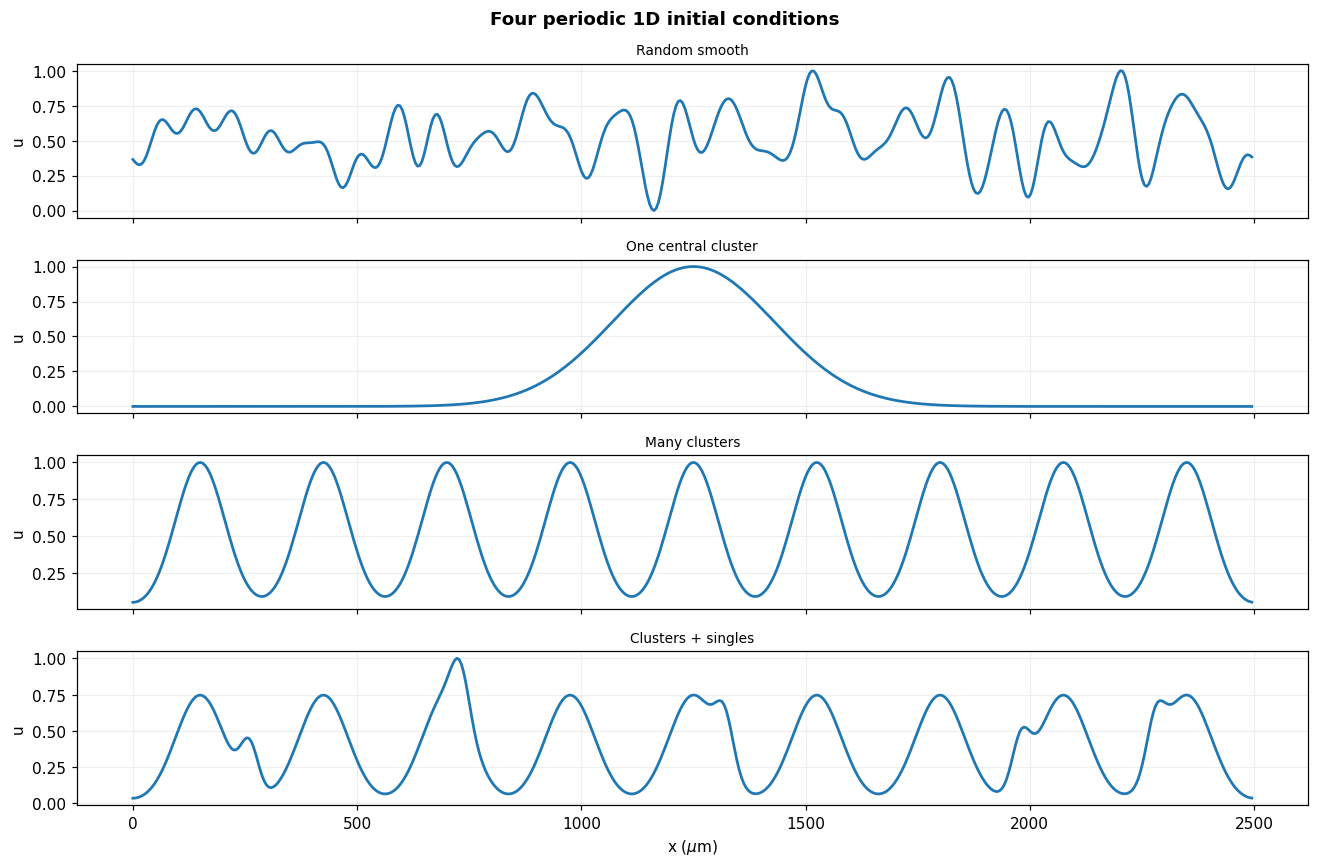

In [5]:
x = np.linspace(0,L_um,nx,endpoint=False)

def periodic_distance(a,b,L=L_um):
    d=np.abs(a-b)
    return np.minimum(d,L-d)

def gaussian_periodic(center,sigma,amplitude=1.0):
    d=periodic_distance(x,center)
    return amplitude*np.exp(-0.5*(d/sigma)**2)

def make_initial_conditions():
    rng=np.random.default_rng(42)
    random_field=rng.normal(0,1,nx)
    k=2*np.pi*fftfreq(nx,d=dx_um)
    filt=np.exp(-(np.abs(k)/0.08)**4)
    random_field=np.real(ifft(fft(random_field)*filt))
    random_field-=random_field.min()
    random_field/=random_field.max()+1e-30

    one_cluster=gaussian_periodic(L_um/2,180)
    one_cluster/=one_cluster.max()

    many=np.zeros(nx)
    centers=np.linspace(150,L_um-150,9)
    for c0 in centers:
        many+=gaussian_periodic(c0,55)
    many/=many.max()

    mixed=many.copy()
    for c0 in [260,730,1320,1980,2280]:
        mixed+=0.45*gaussian_periodic(c0,20)
    mixed/=mixed.max()

    return {
        "Random smooth":random_field,
        "One central cluster":one_cluster,
        "Many clusters":many,
        "Clusters + singles":mixed,
    }

ICs=make_initial_conditions()

fig,axs=plt.subplots(4,1,figsize=(12,8),sharex=True)
for ax,(name,u0) in zip(axs,ICs.items()):
    ax.plot(x,u0,linewidth=1.8)
    ax.set_ylabel("u")
    ax.set_title(name,fontsize=9)
    ax.grid(alpha=.2)
axs[-1].set_xlabel(r"x ($\mu$m)")
fig.suptitle("Four periodic 1D initial conditions",fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Fourier symbols, identifiability, and exact linear solver

In [6]:
def model_parameters(tag):
    return MODEL_LIBRARY[tag]["true"].copy()

def operator_symbol(k,op,p):
    kk=np.asarray(k)
    if op=="Diff": return -p["D"]*kk**2
    if op=="Adv": return -1j*p["c"]*kk
    if op=="Hyper": return -p["nu"]*kk**4
    if op=="SH": return -KAPPA_SH*(1-p["ell"]**2*kk**2)**2
    if op=="FracDiff": return -p["Df"]*np.abs(kk)**p["alpha"]
    if op=="Disp": return 1j*p["beta3"]*kk**3
    if op=="Sixth": return -p["mu6"]*kk**6
    if op=="Loss": return -p["eta"]+0*kk
    if op=="Nonlocal": return p["chi"]*(np.exp(-0.5*p["sigma"]**2*kk**2)-1.0)
    raise ValueError(op)

def complex_symbol(k,tag,p,include_reaction=True):
    spec=MODEL_LIBRARY[tag]
    k=np.asarray(k)
    lam=np.zeros_like(k,dtype=complex)

    if spec["kind"]=="CH":
        return p["A2"]*k**2-p["A4"]*k**4

    if include_reaction:
        lam+=p.get("R",0.0)

    if spec["kind"]=="KS":
        return lam+p["a2"]*k**2-p["a4"]*k**4

    for op in spec["ops"]:
        lam+=operator_symbol(k,op,p)
    return lam

def real_symbol(k,tag,p):
    return np.real(complex_symbol(np.asarray(k),tag,p,True))

def invisible_names(tag):
    out=[]
    for op in MODEL_LIBRARY[tag]["ops"]:
        if op=="Adv": out.append("c")
        if op=="Disp": out.append("beta3")
    return list(dict.fromkeys(out))

def primitive_confounded(tag):
    ops=set(MODEL_LIBRARY[tag]["ops"])
    return "SH" in ops and ("Diff" in ops or "Hyper" in ops)

def effective_poly_truth(tag):
    p=MODEL_LIBRARY[tag]["true"]
    ops=set(MODEL_LIBRARY[tag]["ops"])
    c0=p.get("R",0.0); c2=c4=c6=0.0
    if "Loss" in ops: c0-=p["eta"]
    if "Diff" in ops: c2-=p["D"]
    if "Hyper" in ops: c4-=p["nu"]
    if "Sixth" in ops: c6-=p["mu6"]
    if "SH" in ops:
        c0-=KAPPA_SH
        c2+=2*KAPPA_SH*p["ell"]**2
        c4-=KAPPA_SH*p["ell"]**4
    return {"c0":c0,"c2":c2,"c4":c4,"c6":c6}

def identifiable_names(tag):
    spec=MODEL_LIBRARY[tag]
    kind=spec["kind"]
    ops=spec["ops"]

    if kind=="CH": return ["A2","A4"]
    if kind=="KS": return ["R","a2","a4"]

    if primitive_confounded(tag):
        names=["c0","c2","c4"]
        if "Sixth" in ops: names.append("c6")
        return names

    names=["R"]
    for op in ops:
        if op=="Diff": names.append("D")
        elif op=="Hyper": names.append("nu")
        elif op=="SH": names.append("ell")
        elif op=="FracDiff": names += ["Df","alpha"]
        elif op=="Sixth": names.append("mu6")
        elif op=="Loss":
            if "R" in names: names.remove("R")
            names.append("R_eff")
        elif op=="Nonlocal": names += ["chi","sigma"]
    return list(dict.fromkeys(names))

def true_identifiable_value(tag,name):
    p=MODEL_LIBRARY[tag]["true"]
    if name in p: return p[name]
    if name=="R_eff": return p["R"]-p["eta"]
    if name in ("c0","c2","c4","c6"): return effective_poly_truth(tag)[name]
    return np.nan

def simulate_linear(u0,tag,p):
    u=np.asarray(u0,float).copy()
    k=2*np.pi*fftfreq(nx,d=dx_um)
    growth=np.exp(complex_symbol(k,tag,p,True)*dt)
    stack=[]
    for _ in range(n_frames):
        stack.append(u.copy())
        u=np.real(ifft(fft(u)*growth))
    return np.asarray(stack)

## 6. 1D PSD utilities and known-time fitting

In [7]:
def psd_1d(u,dx=dx_um):
    z=np.asarray(u,float)-np.mean(u)
    F=fft(z)
    P=np.abs(F)**2/len(z)
    k=2*np.pi*fftfreq(len(z),d=dx)
    pos=k>0
    return k[pos],P[pos]

def normalize_1d(k,P):
    v=np.isfinite(k)&np.isfinite(P)&(P>0)&(k>0)
    if v.sum()<3:
        return np.full_like(P,np.nan,dtype=float),np.nan
    norm=np.trapezoid(P[v],k[v])
    return P/(norm+1e-30),norm

def fit_real_symbol(k,y,tag):
    k=np.asarray(k,float); y=np.asarray(y,float)
    names=identifiable_names(tag)
    true=MODEL_LIBRARY[tag]["true"]

    if len(names)==1 and names[0] in ("R","R_eff"):
        val=float(np.mean(y))
        pred=np.full_like(y,val)
        return {names[0]:val},np.nan,pred

    if any(n in names for n in ("c0","c2","c4","c6")):
        degree=3 if "c6" in names else 2
        cf=np.polyfit(k**2,y,degree)
        pred=np.polyval(cf,k**2)
        a=cf[::-1]
        fit={"c0":a[0],"c2":a[1],"c4":a[2]}
        if degree==3: fit["c6"]=a[3]
        ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
        return fit,(1-ssr/sst if sst>0 else np.nan),pred

    p0=[]; lo=[]; hi=[]
    for nm in names:
        tv=true_identifiable_value(tag,nm)
        if nm in ("R","R_eff","a2","A2"):
            p0.append(tv*0.9 if tv!=0 else 0.01)
            lo.append(-20*abs(tv)-10); hi.append(20*abs(tv)+10)
        elif nm=="alpha":
            p0.append(tv*0.9); lo.append(0.2); hi.append(6.0)
        elif nm in ("ell","sigma"):
            p0.append(tv*0.9); lo.append(0.1); hi.append(500.0)
        else:
            p0.append(tv*0.9); lo.append(0.0); hi.append(max(1.0,20*abs(tv)))

    def fitted_curve(k,*theta):
        p=true.copy()
        for nm,val in zip(names,theta):
            if nm=="R_eff":
                p["R"]=float(val)+p["eta"]
            else:
                p[nm]=float(val)
        return real_symbol(k,tag,p)

    popt,_=curve_fit(
        fitted_curve,k,y,p0=np.asarray(p0),
        bounds=(np.asarray(lo),np.asarray(hi)),maxfev=300000
    )
    pred=fitted_curve(k,*popt)
    ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
    R2=1-ssr/sst if sst>0 else np.nan
    return dict(zip(names,popt)),R2,pred

def relative_error(est,true):
    return 100*(est-true)/(abs(true)+1e-30)

## 7. Scenario 3: unknown elapsed time

With unknown \(t\),
\[
y(k)=\log[P_t/P_0]=2t\,\operatorname{Re}\lambda(k),
\]
so absolute rate coefficients are generally known only up to a common scale. The recovery below reports coefficient ratios or shape parameters and explicitly flags SH power-sharing.

For pure SH only, the fixed known \(\kappa_{\rm SH}\) supplies an absolute rate scale. If \(\kappa_{\rm SH}\) were unknown, that absolute-time recovery would no longer be available.

In [8]:
INVISIBLE_OPS={"Adv","Disp"}

def identifiable_combinations_S3(tag):
    spec=MODEL_LIBRARY[tag]; kind=spec["kind"]
    ops=tuple(o for o in spec["ops"] if o not in INVISIBLE_OPS)
    if kind=="CH": return ["A2/A4"]
    if kind=="KS": return ["a2/R","a4/R"]
    if ops==("SH",): return ["ell","R","2*dt (requires known fixed kappa_SH)"]
    if "SH" in ops: return ["net polynomial coefficient ratios; primitive SH/Diff/Hyper separation not claimed"]
    c0="R-eta" if "Loss" in ops else "R"
    out=[]
    if "Diff" in ops: out.append(f"D/({c0})")
    if "Hyper" in ops: out.append(f"nu/({c0})")
    if "Sixth" in ops: out.append(f"mu6/({c0})")
    if "FracDiff" in ops: out += ["alpha",f"Df/({c0})"]
    if "Nonlocal" in ops: out += ["sigma",f"chi/({c0})"]
    return out if out else ["nothing: constant-only real symbol"]

def recover_S3(k,y,tag):
    k=np.asarray(k,float); y=np.asarray(y,float)
    spec=MODEL_LIBRARY[tag]; kind=spec["kind"]
    ops=tuple(o for o in spec["ops"] if o not in INVISIBLE_OPS)

    if kind=="CH":
        cf=np.polyfit(k**2,y,2); pred=np.polyval(cf,k**2)
        b4,b2,b0=cf; rec={}
        if abs(b4)>1e-30: rec["A2/A4"]=-b2/b4
        return rec,pred

    if kind=="KS":
        cf=np.polyfit(k**2,y,2); pred=np.polyval(cf,k**2)
        b4,b2,b0=cf; rec={}
        if abs(b0)>1e-30:
            rec["a2/R"]=b2/b0; rec["a4/R"]=-b4/b0
        return rec,pred

    if ops==("SH",):
        cf=np.polyfit(k**2,y,2); pred=np.polyval(cf,k**2)
        c0,c2,c4=cf[::-1]; rec={}
        if abs(c2)>1e-30:
            ell2=-2*c4/c2
            if ell2>0:
                ell=np.sqrt(ell2)
                s=c2/(2*KAPPA_SH*ell2)
                if abs(s)>1e-30:
                    rec["ell"]=ell
                    rec["2*dt"]=s
                    rec["R"]=c0/s+KAPPA_SH
        return rec,pred

    if "SH" in ops:
        degree=3 if "Sixth" in ops else 2
        cf=np.polyfit(k**2,y,degree); pred=np.polyval(cf,k**2)
        a=cf[::-1]; c0=a[0]; rec={}
        if abs(c0)>1e-30:
            if len(a)>1: rec["net_k2/c0"]=a[1]/c0
            if len(a)>2: rec["net_k4/c0"]=a[2]/c0
            if len(a)>3: rec["net_k6/c0"]=a[3]/c0
        rec["note"]="SH shares spectral powers with other operators; primitive separation not claimed."
        return rec,pred

    has_frac="FracDiff" in ops
    has_nonlocal="Nonlocal" in ops
    has_diff="Diff" in ops
    has_hyper="Hyper" in ops
    has_sixth="Sixth" in ops

    if has_frac or has_nonlocal:
        def model(k,*th):
            it=iter(th); A=next(it)
            out=np.full_like(k,A,dtype=float)
            if has_diff: out+=next(it)*k**2
            if has_hyper: out+=next(it)*k**4
            if has_sixth: out+=next(it)*k**6
            if has_frac:
                B=next(it); al=next(it); out+=B*np.abs(k)**al
            if has_nonlocal:
                C=next(it); sg=next(it); out+=C*(np.exp(-0.5*sg**2*k**2)-1.0)
            return out

        p0=[float(np.mean(y))]; lo=[-np.inf]; hi=[np.inf]
        if has_diff: p0+=[-100]; lo+=[-np.inf]; hi+=[np.inf]
        if has_hyper: p0+=[-1e5]; lo+=[-np.inf]; hi+=[np.inf]
        if has_sixth: p0+=[-1e7]; lo+=[-np.inf]; hi+=[np.inf]
        if has_frac: p0+=[-100,1.5]; lo+=[-np.inf,0.2]; hi+=[np.inf,6]
        if has_nonlocal: p0+=[-1,45]; lo+=[-np.inf,0.1]; hi+=[np.inf,500]

        try:
            popt,_=curve_fit(model,k,y,p0=p0,bounds=(lo,hi),maxfev=300000)
            pred=model(k,*popt)
        except Exception:
            return {"note":"non-polynomial fit failed"},np.full_like(y,np.mean(y))

        it=iter(popt); A=next(it); rec={}
        if has_diff:
            B=next(it)
            if abs(A)>1e-30: rec["D/c0"]=-B/A
        if has_hyper:
            B=next(it)
            if abs(A)>1e-30: rec["nu/c0"]=-B/A
        if has_sixth:
            B=next(it)
            if abs(A)>1e-30: rec["mu6/c0"]=-B/A
        if has_frac:
            B=next(it); al=next(it); rec["alpha"]=al
            if abs(A)>1e-30: rec["Df/c0"]=-B/A
        if has_nonlocal:
            C=next(it); sg=next(it); rec["sigma"]=sg
            if abs(A)>1e-30: rec["chi/c0"]=C/A
        return rec,pred

    has_loss="Loss" in ops
    degree=0
    if has_diff: degree=max(degree,1)
    if has_hyper: degree=max(degree,2)
    if has_sixth: degree=max(degree,3)

    if degree==0:
        return {"note":"constant-only real symbol; time scale not identifiable"},np.full_like(y,np.mean(y))

    cf=np.polyfit(k**2,y,degree); pred=np.polyval(cf,k**2)
    a=cf[::-1]; c0=a[0]
    c0lab="R-eta" if has_loss else "R"
    rec={}
    if abs(c0)>1e-30:
        if has_diff: rec[f"D/({c0lab})"]=-a[1]/c0
        if has_hyper: rec[f"nu/({c0lab})"]=-a[2]/c0
        if has_sixth: rec[f"mu6/({c0lab})"]=-a[3]/c0
    return rec,pred

## 8. Scenarios 1–5

In [9]:
def scenario1(stack,tag,kmax=K_MAX):
    kref,_=psd_1d(stack[0])
    P=np.asarray([psd_1d(fr)[1] for fr in stack])
    lam=np.full(len(kref),np.nan)
    tr2=np.full(len(kref),np.nan)

    for j in range(len(kref)):
        q=np.isfinite(P[:,j])&(P[:,j]>0)
        if q.sum()<6: continue
        lr=linregress(times[q],np.log(P[q,j]))
        lam[j]=lr.slope/2
        tr2[j]=lr.rvalue**2

    v=np.isfinite(lam)&(kref>0)&(kref<kmax)&(tr2>0.5)
    if v.sum()<5: return None
    fit,R2,pred=fit_real_symbol(kref[v],lam[v],tag)
    return {"k":kref[v],"lambda":lam[v],"pred":pred,"fit":fit,"R2":R2,"temporal_R2":tr2[v]}

def scenario2(stack,tag,frame_t=FRAME_T,kmax=K_MAX):
    k,P0=psd_1d(stack[0]); _,Pt=psd_1d(stack[frame_t])
    t=times[frame_t]
    v=np.isfinite(P0)&np.isfinite(Pt)&(P0>0)&(Pt>0)&(k>0)&(k<kmax)
    kv=k[v]; lam=np.log(Pt[v]/P0[v])/(2*t)
    fit,R2,pred=fit_real_symbol(kv,lam,tag)
    return {"k":kv,"lambda":lam,"pred":pred,"fit":fit,"R2":R2}

def scenario3(stack,tag,frame_t=FRAME_T,kmax=K_MAX):
    k,P0=psd_1d(stack[0]); _,Pt=psd_1d(stack[frame_t])
    v=np.isfinite(P0)&np.isfinite(Pt)&(P0>0)&(Pt>0)&(k>0)&(k<kmax)
    kv=k[v]; y=np.log(Pt[v]/P0[v])
    rec,pred=recover_S3(kv,y,tag)
    ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
    return {"k":kv,"y":y,"pred":pred,"recovered":rec,"R2":1-ssr/sst if sst>0 else np.nan}

def snapshot_degree(tag):
    spec=MODEL_LIBRARY[tag]; kind=spec["kind"]; ops=spec["ops"]
    if kind in ("KS","CH"): return 2
    if "Sixth" in ops: return 3
    if "Hyper" in ops or "SH" in ops: return 2
    if "Diff" in ops: return 1
    if "FracDiff" in ops or "Nonlocal" in ops: return 3
    return 0

def scenario4(stack,tag,frame=SNAP_FRAME,kmin=K_MIN_SNAPSHOT,kmax=K_MAX_SNAPSHOT):
    k,P=psd_1d(stack[frame]); Pn,_=normalize_1d(k,P)
    v=np.isfinite(Pn)&(Pn>0)&(k>=kmin)&(k<=kmax)
    kv=k[v]; y=np.log(Pn[v]+1e-30)
    if len(kv)<5: return None
    deg=snapshot_degree(tag)
    if deg==0:
        coef=np.array([np.mean(y)]); pred=np.full_like(y,coef[0])
    else:
        coef=np.polyfit(kv**2,y,deg); pred=np.polyval(coef,kv**2)
    ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
    return {"k":kv,"logP":y,"coef":coef,"pred":pred,
            "R2":1-ssr/sst if sst>0 else np.nan,
            "status":"single-snapshot spectral-shape diagnostic only"}

def fit_segment_shape(segment,tag):
    segment=np.asarray(segment,float)
    if len(segment)<16 or np.std(segment)<1e-10: return None
    k,P=psd_1d(segment,dx=dx_um); Pn,_=normalize_1d(k,P)
    v=np.isfinite(Pn)&(Pn>0)&(k>=K_MIN_SNAPSHOT)&(k<=K_MAX_SNAPSHOT)
    kv=k[v]; y=np.log(Pn[v]+1e-30)
    if len(kv)<5: return None
    deg=snapshot_degree(tag)
    if deg==0:
        coef=np.array([np.mean(y)]); pred=np.full_like(y,coef[0])
    else:
        coef=np.polyfit(kv**2,y,deg); pred=np.polyval(coef,kv**2)
    ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
    R2=1-ssr/sst if sst>0 else np.nan
    metric=coef[-2] if len(coef)>=2 else coef[-1]
    return {"metric":float(metric),"R2":float(R2)}

def scenario5(stack,tag,frame=SNAP_FRAME,grid=GRID_N,r2_min=R2_MIN):
    u=stack[frame]; n=len(u)//grid
    rows=[]
    for j in range(grid):
        rr=fit_segment_shape(u[j*n:(j+1)*n],tag)
        if rr is not None: rows.append({"segment":j,**rr})
    if not rows: return None
    df=pd.DataFrame(rows)
    good=df[np.isfinite(df["R2"])&(df["R2"]>=r2_min)].copy()
    return {
        "df_segments":df,
        "median_metric":float(np.nanmedian(good["metric"])) if len(good) else np.nan,
        "mean_metric":float(np.nanmean(good["metric"])) if len(good) else np.nan,
        "median_R2":float(np.nanmedian(good["R2"])) if len(good) else np.nan,
        "mean_R2":float(np.nanmean(good["R2"])) if len(good) else np.nan,
        "n_good":int(len(good)),
        "n_total":int(len(df)),
        "grid":grid,
    }

## 9. Detailed Scenario 5: 1D segmented reaction–diffusion \(D/R\)

For reaction–diffusion,
\[
u_t=Ru+Du_{xx},
\]
a single segment satisfies
\[
\log_{10}P_i(k,t)
=
\log_{10}P_i(k,0)
+\frac{2Rt}{\ln 10}
-\frac{2Dt}{\ln 10}k^2.
\]

Thus the observed \(k^2\) slope contains both the reaction–diffusion contribution and any local initial-condition spectral slope. Segmentation is therefore an **empirical bias-reduction test**, not a proof that the initial-condition bias averages to zero.

For the synthetic validation below, \(R\) and elapsed time are known, \(D\) is estimated from the local slope, and \(\log_{10}(D/R)\) is reported.

In [10]:
def fit_segment_RD(segment,R_known,elapsed_time):
    segment=np.asarray(segment,float)
    if len(segment)<16 or np.std(segment)<1e-10: return None
    k,P=psd_1d(segment,dx=dx_um)
    v=np.isfinite(P)&(P>0)&(k>K_MIN_SNAPSHOT)&(k<K_MAX_SNAPSHOT)
    kf=k[v]; Pf=P[v]
    if len(kf)<5: return None
    X=np.column_stack([np.ones(len(kf)),kf**2])
    y=np.log10(Pf+1e-30)
    beta,*_=np.linalg.lstsq(X,y,rcond=None)
    A,B=beta; pred=X@beta
    ssr=np.sum((y-pred)**2); sst=np.sum((y-y.mean())**2)
    R2=1-ssr/sst if sst>0 else np.nan
    D_hat=-B*np.log(10)/(2*elapsed_time)
    lodr=np.log10(D_hat/R_known) if D_hat>0 and R_known>0 else np.nan
    return {"D_hat":float(D_hat),"log10_DR":lodr,"R2":float(R2)}

def fit_tiled_RD_1d(img,R_known,elapsed_time,grid_n,r2_min=R2_MIN):
    n=len(img)//grid_n; rows=[]
    for j in range(grid_n):
        rr=fit_segment_RD(img[j*n:(j+1)*n],R_known,elapsed_time)
        if rr is not None: rows.append({"segment":j,**rr})
    if not rows: return None
    df=pd.DataFrame(rows)
    good=df[np.isfinite(df["log10_DR"])&np.isfinite(df["R2"])&(df["R2"]>=r2_min)].copy()
    if not len(good):
        return {"median":np.nan,"mean":np.nan,"std":np.nan,"n_good":0,"n_total":len(df),"df_segments":df}
    vals=good["log10_DR"].values
    return {"median":float(np.median(vals)),"mean":float(np.mean(vals)),
            "std":float(np.std(vals)),"n_good":len(good),"n_total":len(df),"df_segments":df}

## 10. Run all 53 linear models through all five scenarios

In [11]:
ALL_RESULTS={}
ALL_STACKS={}

for model_index,tag in enumerate(MODEL_VARIANTS,1):
    p=model_parameters(tag)
    print(f"[{model_index:02d}/{len(MODEL_VARIANTS)}] {tag}")

    stacks={ic:simulate_linear(u0,tag,p) for ic,u0 in ICs.items()}
    ALL_STACKS[tag]=stacks

    results={"tag":tag,"true":p,"S1":{},"S2":{},"S3":{},"S4":{},"S5":{}}

    for ic,stack in stacks.items():
        for scen,func in [("S1",scenario1),("S2",scenario2),("S3",scenario3),("S4",scenario4),("S5",scenario5)]:
            try:
                results[scen][ic]=func(stack,tag)
            except Exception as e:
                results[scen][ic]=None
                print("  ",ic,scen,"failed:",type(e).__name__,str(e)[:120])

    ALL_RESULTS[tag]=results

print("Finished",len(ALL_RESULTS),"linear models.")

[01/53] R+Diff
[02/53] R+Adv
[03/53] R+Hyper
[04/53] R+SH
[05/53] R+FracDiff
[06/53] R+Disp
[07/53] R+Sixth
[08/53] R+Loss
[09/53] R+Nonlocal
[10/53] R+Diff+Adv
[11/53] R+Diff+Hyper
[12/53] R+Diff+SH
[13/53] R+Diff+FracDiff
[14/53] R+Diff+Disp
[15/53] R+Diff+Sixth
[16/53] R+Diff+Loss
[17/53] R+Diff+Nonlocal
[18/53] R+Adv+Hyper
[19/53] R+Adv+SH
[20/53] R+Adv+FracDiff
[21/53] R+Adv+Disp
[22/53] R+Adv+Sixth
[23/53] R+Adv+Loss
[24/53] R+Adv+Nonlocal
[25/53] R+Hyper+SH
[26/53] R+Hyper+FracDiff
[27/53] R+Hyper+Disp
[28/53] R+Hyper+Sixth
[29/53] R+Hyper+Loss
[30/53] R+Hyper+Nonlocal
[31/53] R+SH+FracDiff
[32/53] R+SH+Disp
[33/53] R+SH+Sixth
[34/53] R+SH+Loss
[35/53] R+SH+Nonlocal
[36/53] R+FracDiff+Disp
[37/53] R+FracDiff+Sixth
[38/53] R+FracDiff+Loss
[39/53] R+FracDiff+Nonlocal
[40/53] R+Disp+Sixth
[41/53] R+Disp+Loss
[42/53] R+Disp+Nonlocal
[43/53] R+Sixth+Loss
[44/53] R+Sixth+Nonlocal
[45/53] R+Loss+Nonlocal
[46/53] R+Diff+Adv+Hyper
[47/53] R+Diff+Adv+SH
[48/53] R+Diff+Hyper+SH
[49/53] R+A

## 11. Optional per-model figures

In [12]:
if RUN_PER_MODEL_FIGURES:
    for tag,res in ALL_RESULTS.items():
        stacks=ALL_STACKS[tag]

        fig,axs=plt.subplots(4,1,figsize=(12,9),sharex=True)
        for ax,(ic,stack) in zip(axs,stacks.items()):
            for fid in FRAME_LIST:
                ax.plot(x,stack[fid],linewidth=1,label=f"t={times[fid]:.2f}")
            ax.set_title(ic); ax.set_ylabel("u"); ax.grid(alpha=.2)
        axs[0].legend(ncol=3,fontsize=7)
        axs[-1].set_xlabel(r"x ($\mu$m)")
        fig.suptitle(tag+" — linear evolution",fontweight="bold")
        plt.tight_layout(); plt.show()

        for scen in ("S1","S2","S3","S4"):
            fig,axs=plt.subplots(2,2,figsize=(12,9))
            for ax,(ic,rr) in zip(axs.ravel(),res[scen].items()):
                ax.set_title(ic); ax.grid(alpha=.2)
                if rr is None:
                    ax.text(.5,.5,"failed",ha="center",va="center",transform=ax.transAxes)
                    continue
                if scen in ("S1","S2"):
                    ax.scatter(rr["k"],rr["lambda"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\lambda(k)$")
                elif scen=="S3":
                    ax.scatter(rr["k"],rr["y"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\log(P_t/P_0)$")
                else:
                    ax.scatter(rr["k"],rr["logP"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\log P_{\rm norm}$")
                ax.set_xlabel("k")
            fig.suptitle(f"{tag} — {scen}",fontweight="bold")
            plt.tight_layout(); plt.show()

## 12. Scenario-5 reaction–diffusion segmentation sweep

,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments
0,Random smooth,2,NaN,3.0621,NaN,0,2
1,Random smooth,4,NaN,3.0621,NaN,0,4
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6
3,Random smooth,8,2.0305,3.0621,-1.0316,3,8
4,Random smooth,10,2.1147,3.0621,-0.9474,3,10
5,Random smooth,12,NaN,3.0621,NaN,0,0
6,Random smooth,16,NaN,3.0621,NaN,0,0
7,One central cluster,2,NaN,3.0621,NaN,0,2
8,One central cluster,4,1.9594,3.0621,-1.1027,2,4
9,One central cluster,6,1.9238,3.0621,-1.1383,2,6


Best segmentation by initial condition:


,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments,AbsError
0,Clusters + singles,6,2.0623,3.0621,-0.9999,1,6,0.9999
1,One central cluster,10,1.9823,3.0621,-1.0799,10,10,1.0799
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6,0.3714


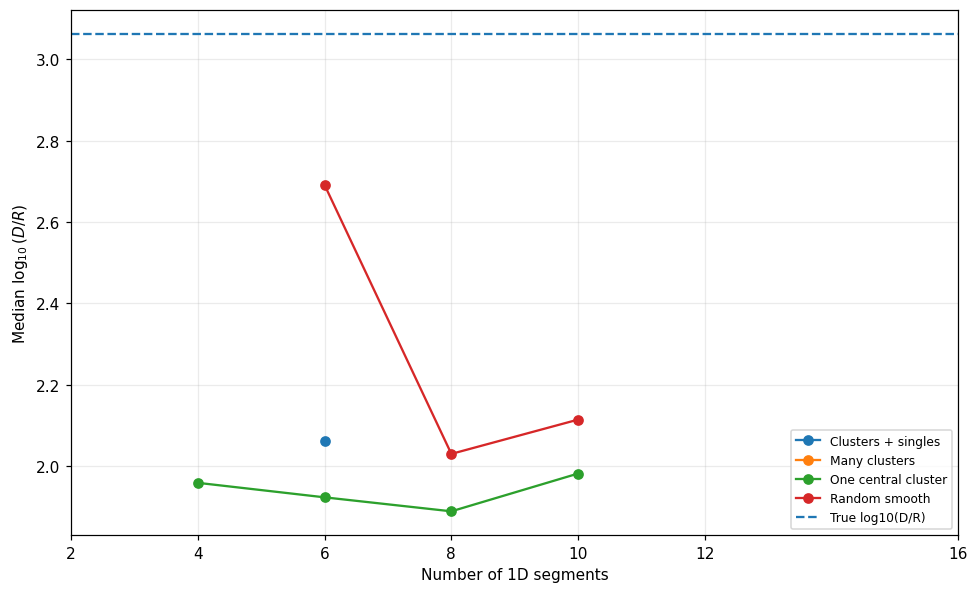

In [13]:
S5_RD_TAG="R+Diff"
R_TRUE=MODEL_LIBRARY[S5_RD_TAG]["true"]["R"]
D_TRUE=MODEL_LIBRARY[S5_RD_TAG]["true"]["D"]
TRUE_LOG10_DR=np.log10(D_TRUE/R_TRUE)
ELAPSED_S5=times[SNAP_FRAME]

rows=[]; S5_RD_DETAILS={}
for ic,stack in ALL_STACKS[S5_RD_TAG].items():
    img=stack[SNAP_FRAME]
    for grid_n in GRID_LIST:
        rr=fit_tiled_RD_1d(img,R_TRUE,ELAPSED_S5,grid_n,R2_MIN)
        S5_RD_DETAILS[(ic,grid_n)]=rr
        rows.append({
            "Initial condition":ic,
            "Grid":grid_n,
            "Median log10(D/R)":np.nan if rr is None else rr["median"],
            "True log10(D/R)":TRUE_LOG10_DR,
            "Error":np.nan if rr is None or not np.isfinite(rr["median"]) else rr["median"]-TRUE_LOG10_DR,
            "Good segments":0 if rr is None else rr["n_good"],
            "Total fitted segments":0 if rr is None else rr["n_total"],
        })

S5_RD_GRID_DF=pd.DataFrame(rows)
display(S5_RD_GRID_DF.round(4))

best=[]
for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    g=grp[np.isfinite(grp["Error"])].copy()
    if len(g):
        g["AbsError"]=np.abs(g["Error"])
        g=g.sort_values(["AbsError","Good segments"],ascending=[True,False])
        best.append(g.iloc[0])
S5_RD_BEST_DF=pd.DataFrame(best).reset_index(drop=True) if best else pd.DataFrame()
print("Best segmentation by initial condition:")
display(S5_RD_BEST_DF.round(4))

fig,ax=plt.subplots(figsize=(9,5.5))
for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(grp["Grid"],grp["Median log10(D/R)"],marker="o",label=ic)
ax.axhline(TRUE_LOG10_DR,linestyle="--",linewidth=1.5,label="True log10(D/R)")
ax.set_xlabel("Number of 1D segments")
ax.set_ylabel(r"Median $\log_{10}(D/R)$")
ax.set_xticks(GRID_LIST); ax.grid(alpha=.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 13. Final master summary

In [14]:
def fmt_dict(d):
    if not isinstance(d,dict): return ""
    out=[]
    for k,v in d.items():
        if isinstance(v,str): out.append(f"{k}: {v}")
        else:
            try: out.append(f"{k}={float(v):.5g}")
            except Exception: out.append(f"{k}={v}")
    return "; ".join(out)

MASTER_ROWS=[]
for tag,res in ALL_RESULTS.items():
    for scen in ("S1","S2","S3","S4","S5"):
        for ic in ICs:
            rr=res[scen].get(ic)
            row={
                "PDE":tag,
                "Operators":" + ".join(MODEL_LIBRARY[tag]["ops"]),
                "Scenario":scen,
                "Initial condition":ic,
                "True parameters":fmt_dict(res["true"]),
                "Recovered / metric":"",
                "R2":np.nan,
                "Median abs parameter error (%)":np.nan,
                "Good segments":np.nan,
                "Total segments":np.nan,
                "PSD-invisible":"; ".join(invisible_names(tag)),
                "Status":"",
            }

            if rr is None:
                row["Status"]="failed / unavailable"

            elif scen in ("S1","S2"):
                row["Recovered / metric"]=fmt_dict(rr.get("fit",{}))
                row["R2"]=rr.get("R2",np.nan)
                errs=[]
                for nm,est in rr.get("fit",{}).items():
                    tv=true_identifiable_value(tag,nm)
                    if np.isfinite(tv) and abs(tv)>1e-30:
                        errs.append(abs(relative_error(est,tv)))
                row["Median abs parameter error (%)"]=np.nanmedian(errs) if errs else np.nan
                row["Status"]="known-time PSD-symbol recovery"

            elif scen=="S3":
                row["Recovered / metric"]=fmt_dict(rr.get("recovered",{}))
                row["R2"]=rr.get("R2",np.nan)
                row["Status"]="unknown-time ratio / shape recovery"

            elif scen=="S4":
                row["Recovered / metric"]="shape coefficients="+np.array2string(np.asarray(rr.get("coef",[])),precision=4)
                row["R2"]=rr.get("R2",np.nan)
                row["Status"]="single-snapshot shape diagnostic only"

            elif scen=="S5":
                row["Recovered / metric"]=f"median accepted-segment metric={rr.get('median_metric',np.nan):.5g}"
                row["R2"]=rr.get("median_R2",np.nan)
                row["Good segments"]=rr.get("n_good",np.nan)
                row["Total segments"]=rr.get("n_total",np.nan)
                row["Status"]="segmented regional shape diagnostic"

            MASTER_ROWS.append(row)

MASTER_SUMMARY_DF=pd.DataFrame(MASTER_ROWS)
assert len(MASTER_SUMMARY_DF)==len(MODEL_LIBRARY)*5*len(ICs)

print(f"MASTER SUMMARY: {len(MODEL_LIBRARY)} PDEs x 5 scenarios x {len(ICs)} ICs = {len(MASTER_SUMMARY_DF)} rows")
display(MASTER_SUMMARY_DF)

MASTER_R2_MATRIX=(
    MASTER_SUMMARY_DF
    .pivot_table(index=["PDE","Initial condition"],columns="Scenario",values="R2",aggfunc="first")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)
print("Compact R2 matrix:")
display(MASTER_R2_MATRIX.round(4))

PDE_SCENARIO_MEDIAN_R2=(
    MASTER_SUMMARY_DF
    .groupby(["PDE","Scenario"],as_index=False)["R2"].median()
    .pivot(index="PDE",columns="Scenario",values="R2")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)
print("Median R2 across the four ICs:")
display(PDE_SCENARIO_MEDIAN_R2.round(4))

KNOWN_TIME_ERROR=(
    MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"].isin(["S1","S2"])]
    .pivot_table(index=["PDE","Initial condition"],columns="Scenario",
                 values="Median abs parameter error (%)",aggfunc="first")
    .reindex(columns=["S1","S2"])
)
print("Known-time parameter error (%):")
display(KNOWN_TIME_ERROR.round(3))

S3_RECOVERABILITY_DF=pd.DataFrame([
    {"PDE":tag,
     "Recoverable in S3":"; ".join(identifiable_combinations_S3(tag)),
     "PSD-invisible":"; ".join(invisible_names(tag))}
    for tag in MODEL_LIBRARY
])
print("Scenario-3 structural recoverability:")
display(S3_RECOVERABILITY_DF)

MASTER_SUMMARY_DF.to_csv("MASTER2_1D_ALL_PDEs_ALL_5_SCENARIOS_tidy.csv",index=False)
MASTER_R2_MATRIX.to_csv("MASTER2_1D_ALL_PDEs_R2_matrix.csv")
PDE_SCENARIO_MEDIAN_R2.to_csv("MASTER2_1D_PDE_scenario_median_R2.csv")
KNOWN_TIME_ERROR.to_csv("MASTER2_1D_known_time_parameter_error.csv")
S3_RECOVERABILITY_DF.to_csv("MASTER2_1D_S3_recoverability.csv",index=False)
S5_RD_GRID_DF.to_csv("MASTER2_1D_Scenario5_RD_grid_sweep.csv",index=False)
print("Saved all summary CSV files.")

MASTER SUMMARY: 53 PDEs x 5 scenarios x 4 ICs = 1060 rows


,PDE,Operators,Scenario,Initial condition,True parameters,Recovered / metric,R2,Median abs parameter error (%),Good segments,Total segments,PSD-invisible,Status
0,R+Diff,Diff,S1,Random smooth,R=0.65; D=750,R=0.65; D=750,1.000000,2.311045e-12,NaN,NaN,,known-time PSD-symbol recovery
1,R+Diff,Diff,S1,One central cluster,R=0.65; D=750,R=0.65211; D=751.77,0.999990,2.805075e-01,NaN,NaN,,known-time PSD-symbol recovery
2,R+Diff,Diff,S1,Many clusters,R=0.65; D=750,R=0.65; D=750,1.000000,5.120873e-09,NaN,NaN,,known-time PSD-symbol recovery
3,R+Diff,Diff,S1,Clusters + singles,R=0.65; D=750,R=0.65; D=750,1.000000,7.972062e-13,NaN,NaN,,known-time PSD-symbol recovery
4,R+Diff,Diff,S2,Random smooth,R=0.65; D=750,R=0.65; D=750,1.000000,1.619728e-12,NaN,NaN,,known-time PSD-symbol recovery
...,...,...,...,...,...,...,...,...,...,...,...,...
1055,R+Mixed,Diff + Adv + Disp + Hyper,S4,Clusters + singles,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,shape coefficients=[ 1.1947e+05 -6.4596e+03 8...,0.963639,NaN,NaN,NaN,c; beta3,single-snapshot shape diagnostic only
1056,R+Mixed,Diff + Adv + Disp + Hyper,S5,Random smooth,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-604.36,0.943285,NaN,5.0,8.0,c; beta3,segmented regional shape diagnostic
1057,R+Mixed,Diff + Adv + Disp + Hyper,S5,One central cluster,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-384.39,0.951665,NaN,8.0,8.0,c; beta3,segmented regional shape diagnostic
1058,R+Mixed,Diff + Adv + Disp + Hyper,S5,Many clusters,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-873.24,0.841909,NaN,7.0,8.0,c; beta3,segmented regional shape diagnostic


Compact R2 matrix:


Scenario                                  S1      S2      S3      S4      S5
PDE              Initial condition                                          
CHlin            Clusters + singles   1.0000  1.0000  1.0000  0.9365  0.9276
                 Many clusters        1.0000  1.0000  1.0000  0.9486  0.8584
                 One central cluster  1.0000  1.0000  1.0000  0.8509  0.9523
                 Random smooth        1.0000  1.0000  1.0000  0.9314  0.9475
R+Adv            Clusters + singles      NaN     NaN  0.0000  0.0000     NaN
...                                      ...     ...     ...     ...     ...
R+Sixth+Loss     Random smooth        1.0000  1.0000  1.0000  0.9365  0.9556
R+Sixth+Nonlocal Clusters + singles   1.0000  1.0000  0.9989  0.9458  0.9404
                 Many clusters        1.0000  1.0000  0.9989  0.9468  0.9369
                 One central cluster  0.9629  0.9679  0.9680  0.9253  0.9847
                 Random smooth        1.0000  1.0000  0.9989  0.9402  0.9489

[212 rows x 5 columns]

Median R2 across the four ICs:


...

Known-time parameter error (%):


Scenario                                  S1      S2
PDE              Initial condition                  
CHlin            Clusters + singles    0.000   0.000
                 Many clusters         0.000   0.000
                 One central cluster   0.086   0.070
                 Random smooth         0.000   0.000
R+Adv            Clusters + singles    0.000   0.000
...                                      ...     ...
R+Sixth+Loss     Random smooth         0.000   0.000
R+Sixth+Nonlocal Clusters + singles    0.000   0.000
                 Many clusters         0.000   0.000
                 One central cluster  61.795  59.294
                 Random smooth         0.000   0.000

[212 rows x 2 columns]

Scenario-3 structural recoverability:


,PDE,Recoverable in S3,PSD-invisible
0,R+Diff,D/(R),
1,R+Adv,nothing: constant-only real symbol,c
2,R+Hyper,nu/(R),
3,R+SH,ell; R; 2*dt (requires known fixed kappa_SH),
4,R+FracDiff,alpha; Df/(R),
5,R+Disp,nothing: constant-only real symbol,beta3
6,R+Sixth,mu6/(R),
7,R+Loss,nothing: constant-only real symbol,
8,R+Nonlocal,sigma; chi/(R),
9,R+Diff+Adv,D/(R),c


Saved all summary CSV files.


## 14. Interpretation notes

- **S1:** full time series recovers \(\mathrm{Re}\lambda(k)\) from temporal slopes.
- **S2:** two known-time frames recover \(\mathrm{Re}\lambda(k)\) from the PSD ratio.
- **S3:** unknown elapsed time generally leaves coefficient ratios and shape parameters.
- **Advection:** \(c\) is phase-only and cannot be recovered from PSD magnitude.
- **Third-order dispersion:** \(\beta_3\) is also phase-only.
- **Linear loss:** only \(R-\eta\) is visible to the linear PSD.
- **SH:** \(\kappa_{\rm SH}=1\) is treated as known. If it is unknown, absolute-time recovery from pure SH is no longer valid.
- **SH mixtures:** explicit diffusion and hyperdiffusion share the SH \(k^2/k^4\) powers; effective coefficients are reported when primitives are not structurally separable.
- **S4:** an arbitrary single snapshot is a spectral-shape diagnostic, not absolute parameter recovery.
- **S5:** segmentation is an empirical regional-bias-reduction approach. Accepted-segment summaries use only segments with \(R^2\ge0.80\).
- **Cross-scenario \(R^2\):** S1–S3, S4, and S5 fit different statistical objects; their \(R^2\) values should not be interpreted as identical measures of identifiability.


# 14. Complete five-scenario plotting for every PDE

This section adds the missing visualization layer. For every PDE, it generates a compact **five-scenario summary figure** across all four initial conditions.

The five panels are interpreted differently:

- **S1:** full-time-series recovery of \(\mathrm{Re}\lambda(k)\)
- **S2:** two-frame, known-time recovery of \(\mathrm{Re}\lambda(k)\)
- **S3:** unknown-time identifiable ratios / shape recovery
- **S4:** single-snapshot spectral-shape diagnostic
- **S5:** 1D segmented regional diagnostic using only accepted segments in the summary

The \(R^2\) values are shown for fit quality, but they should not be interpreted as identical statistical quantities across all five scenarios.


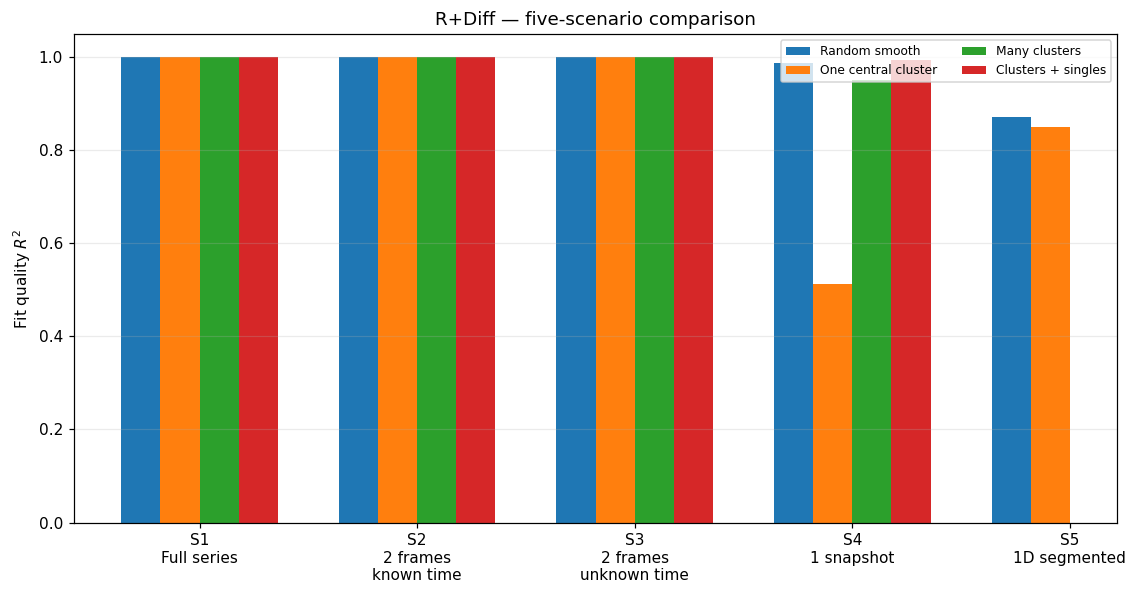

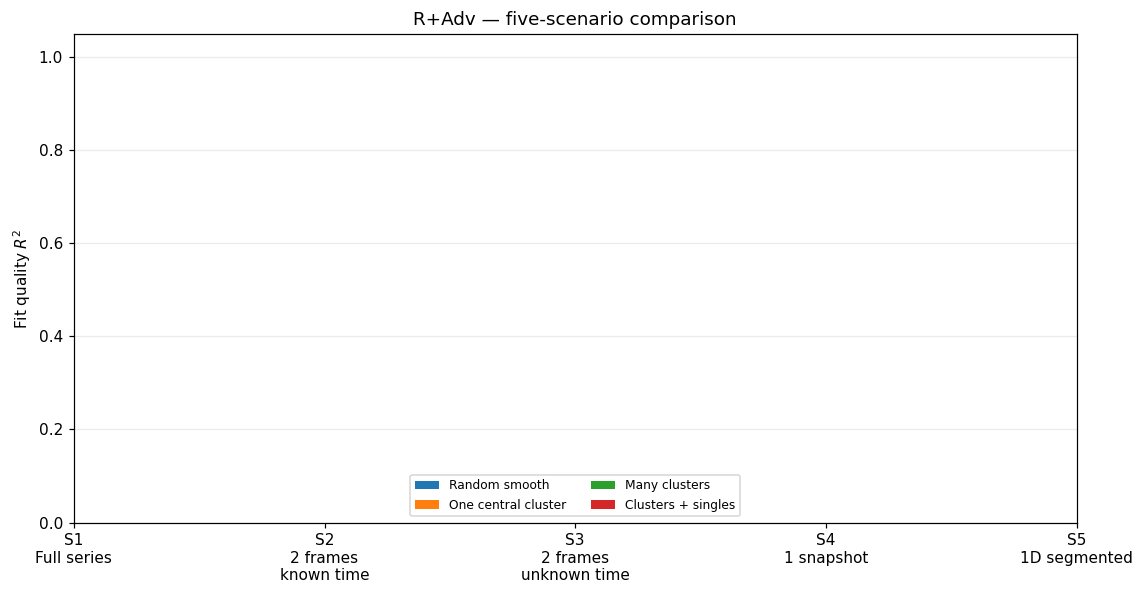

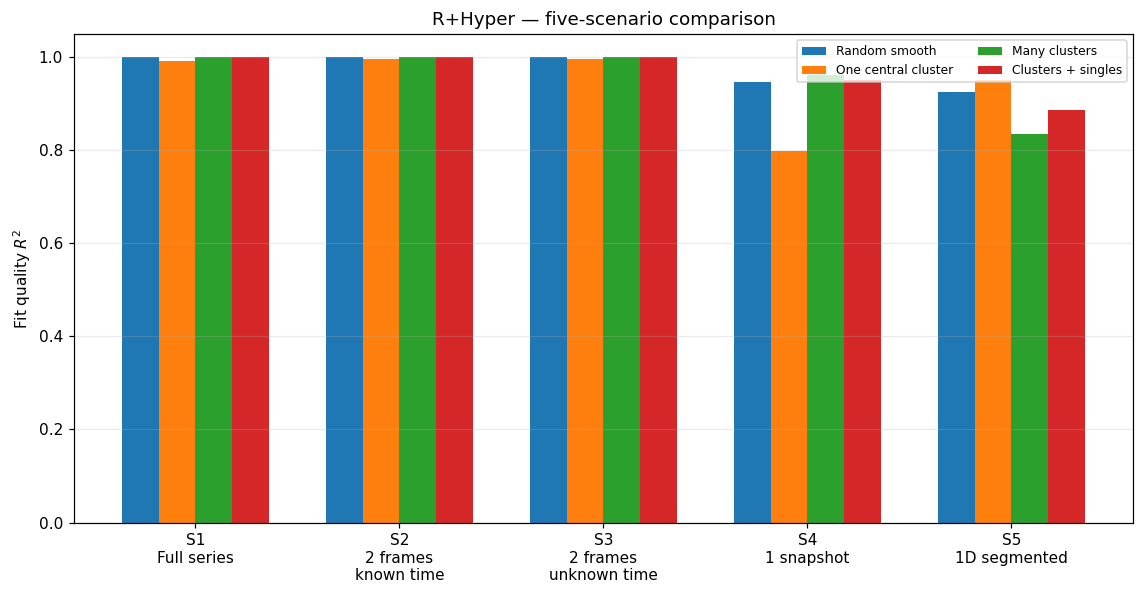

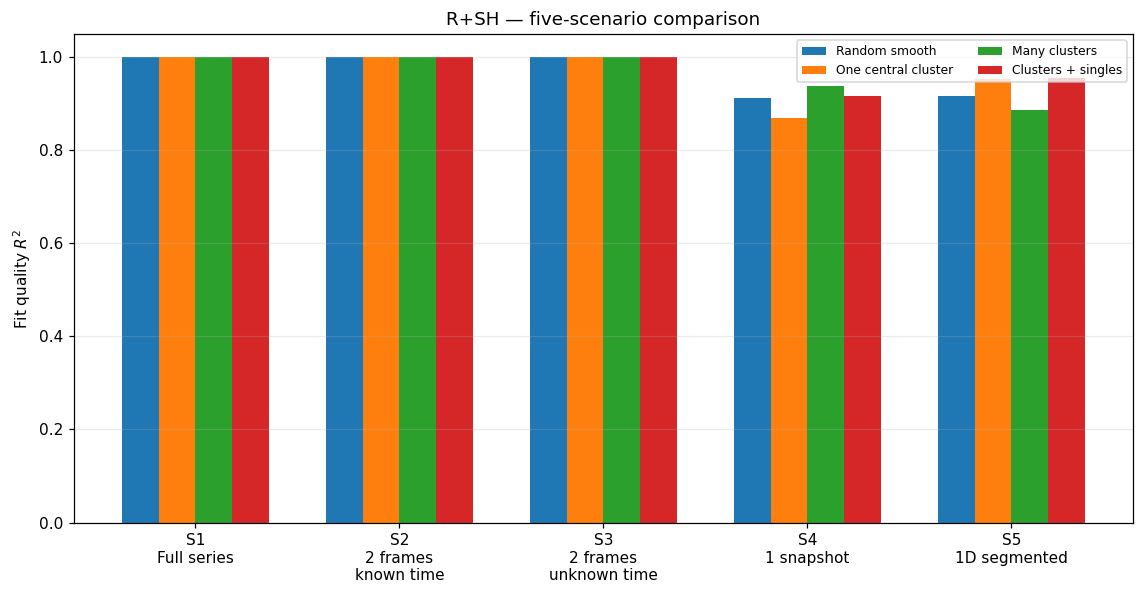

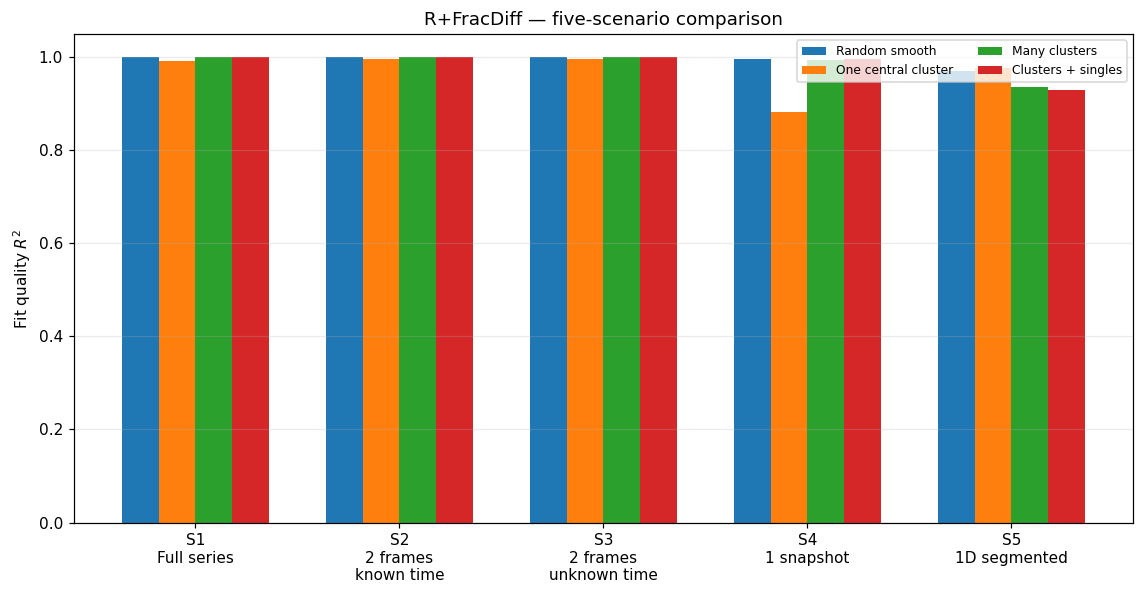

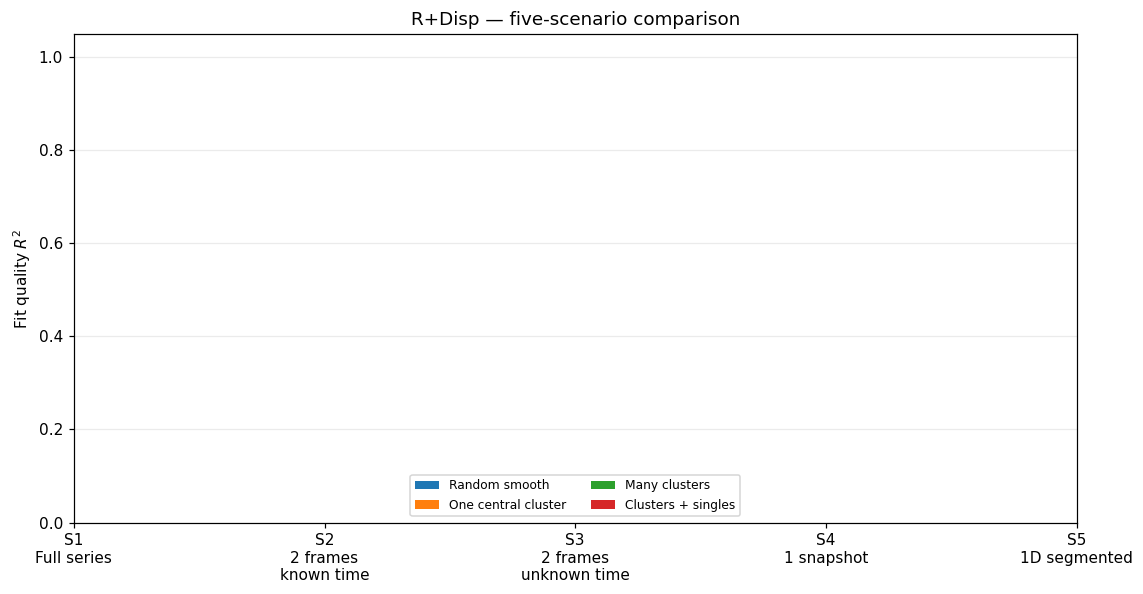

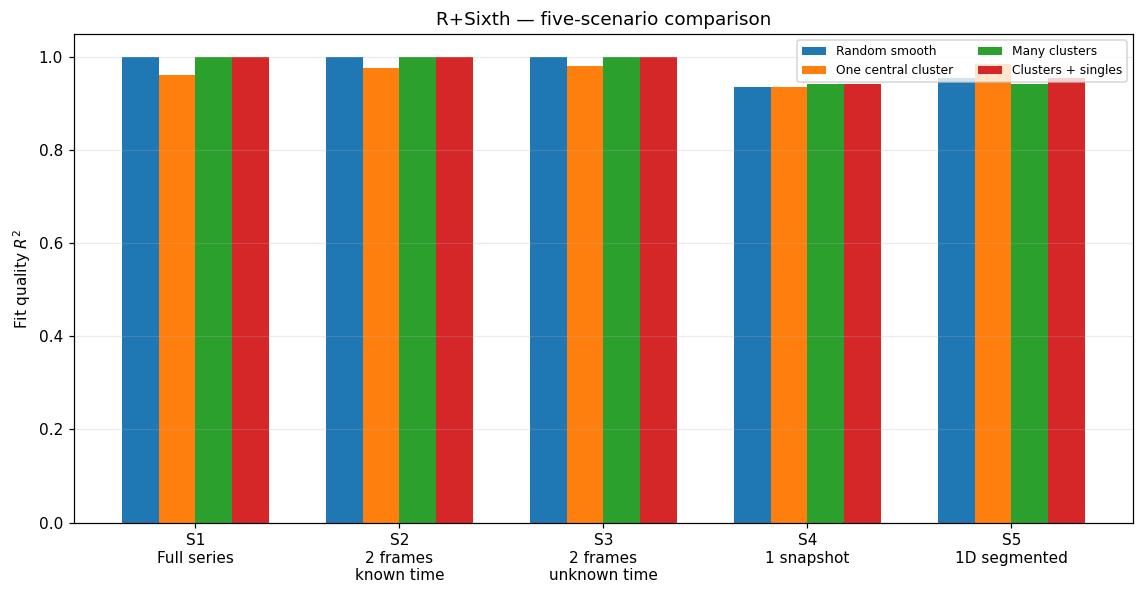

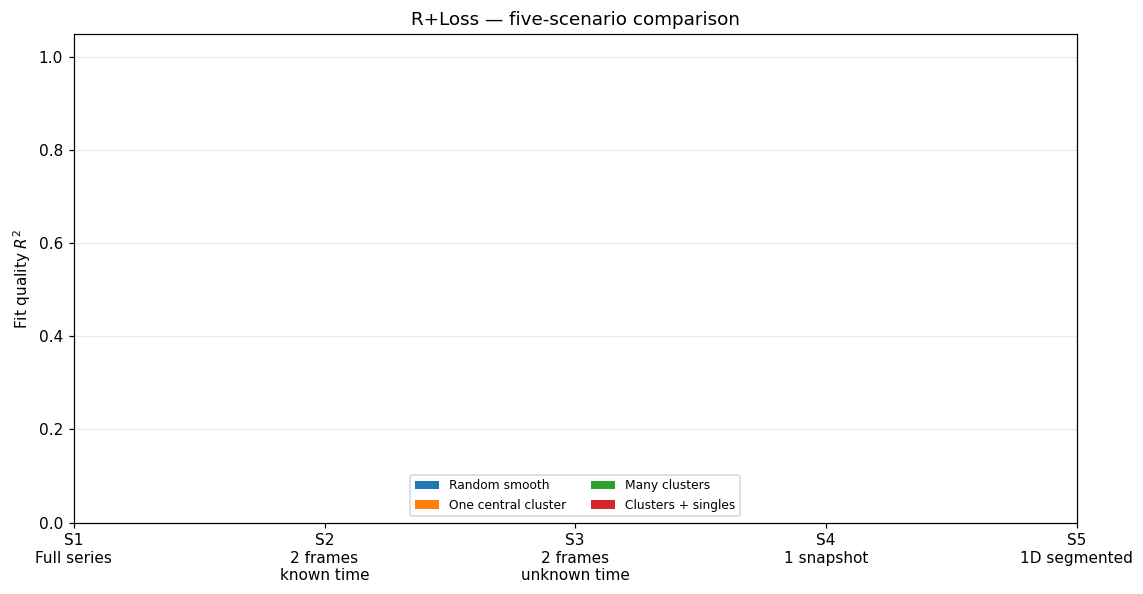

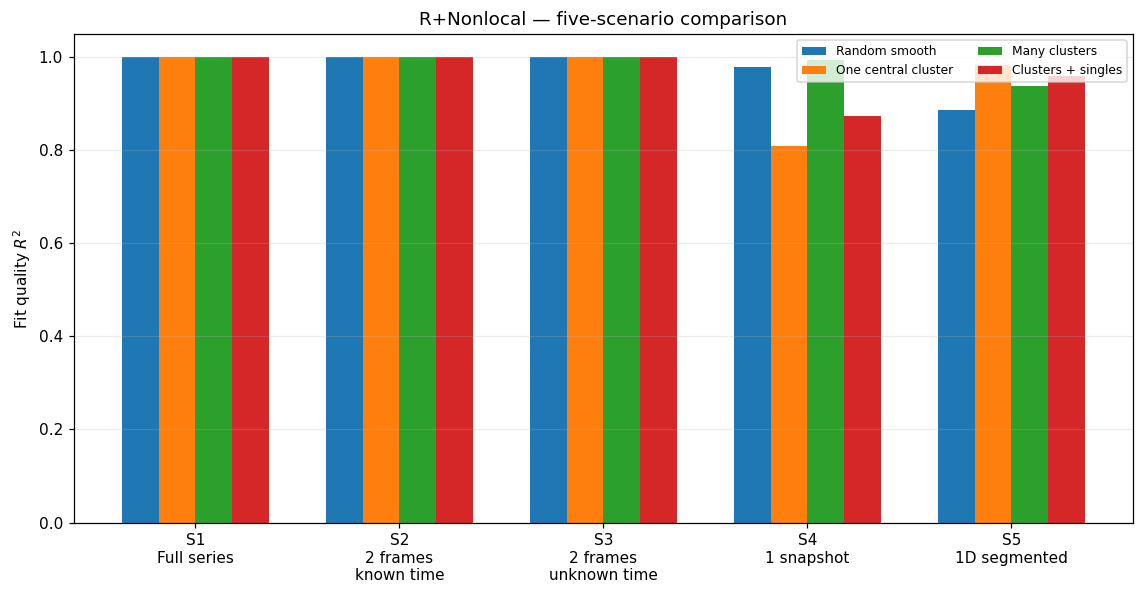

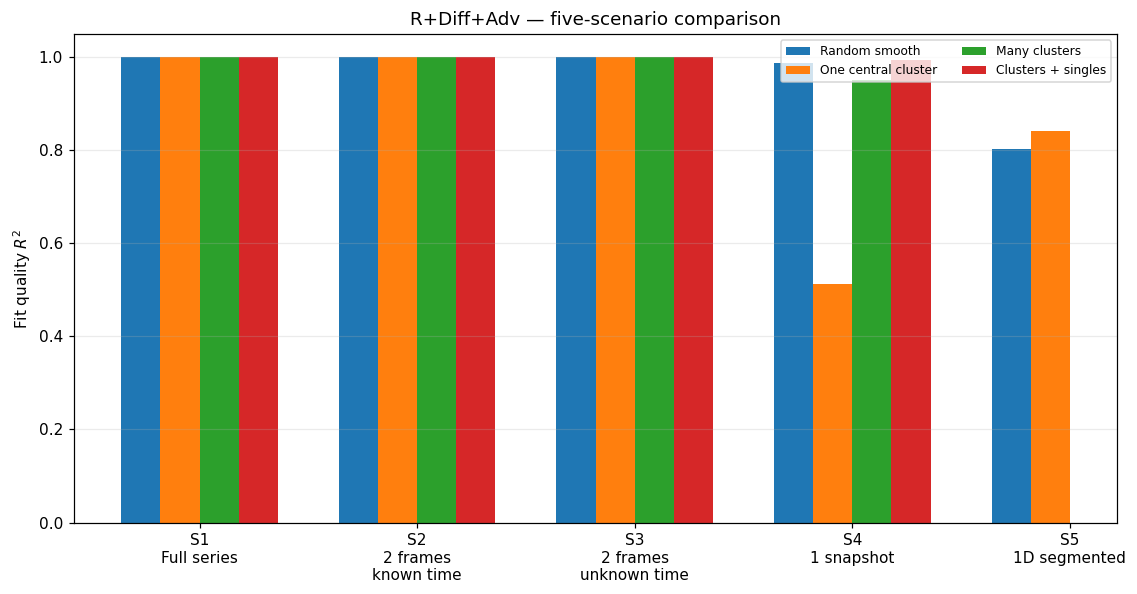

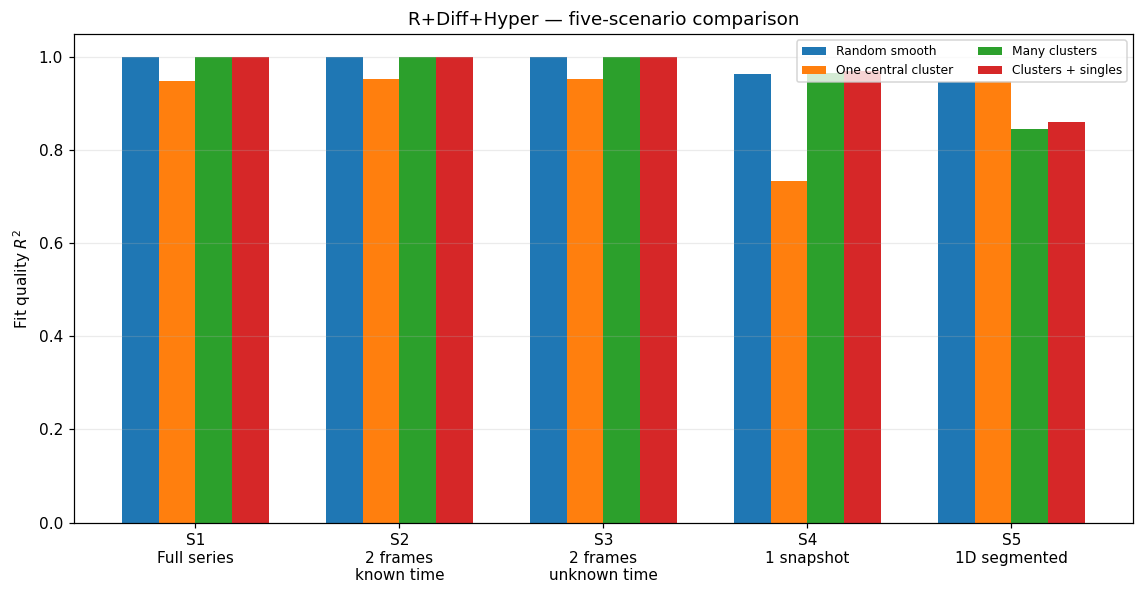

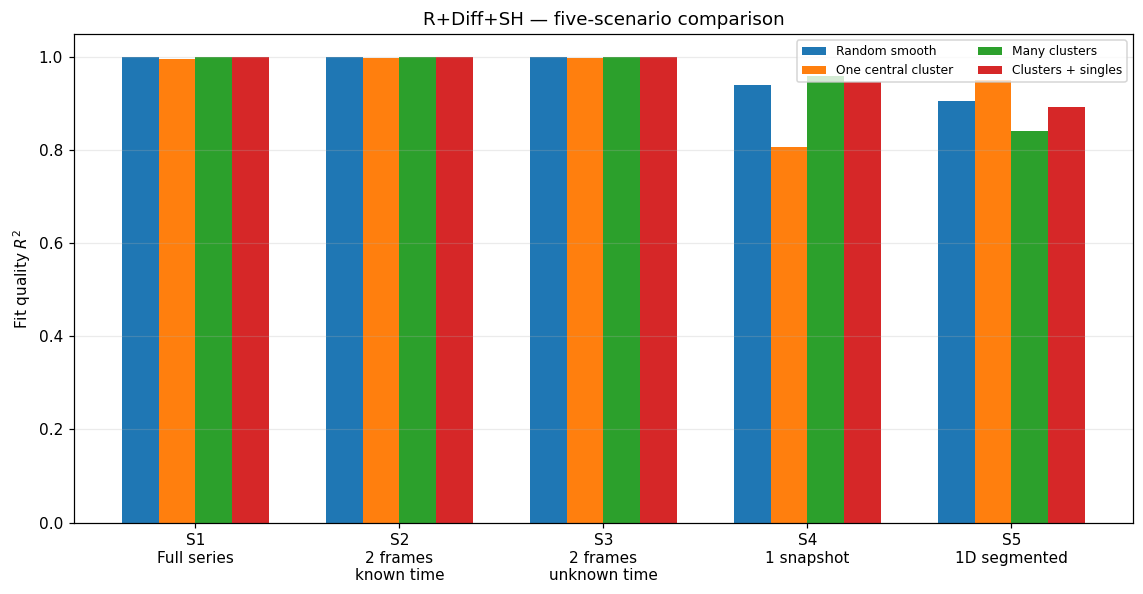

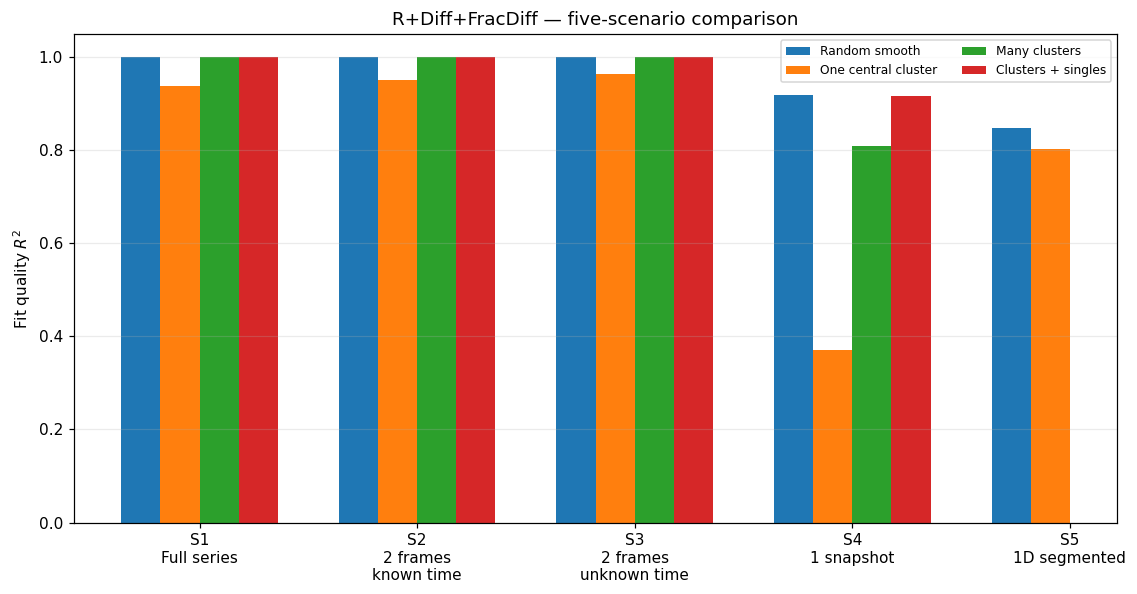

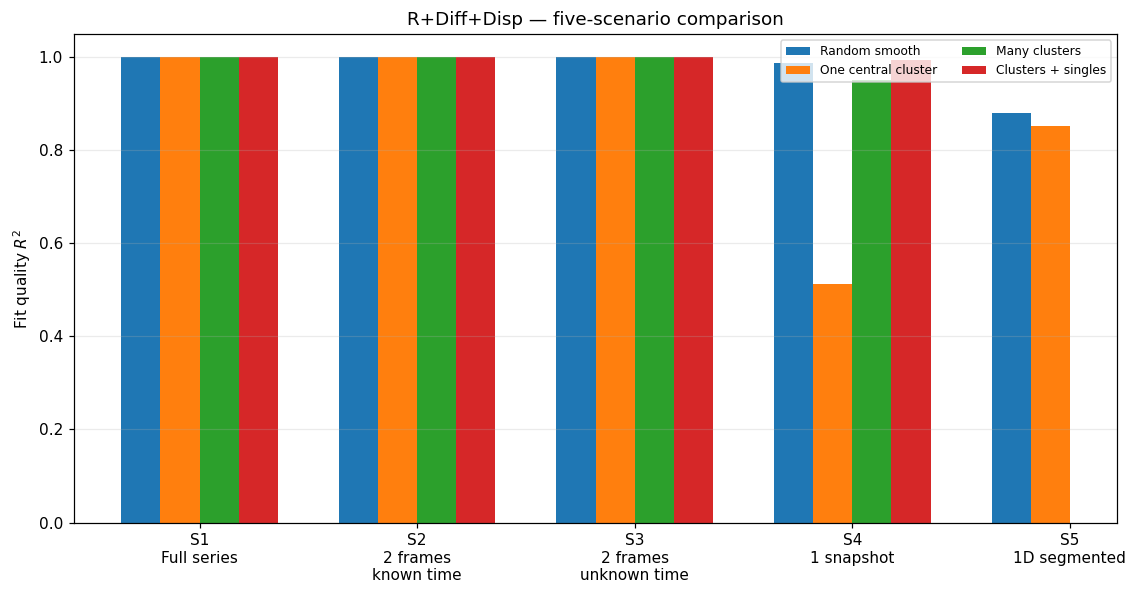

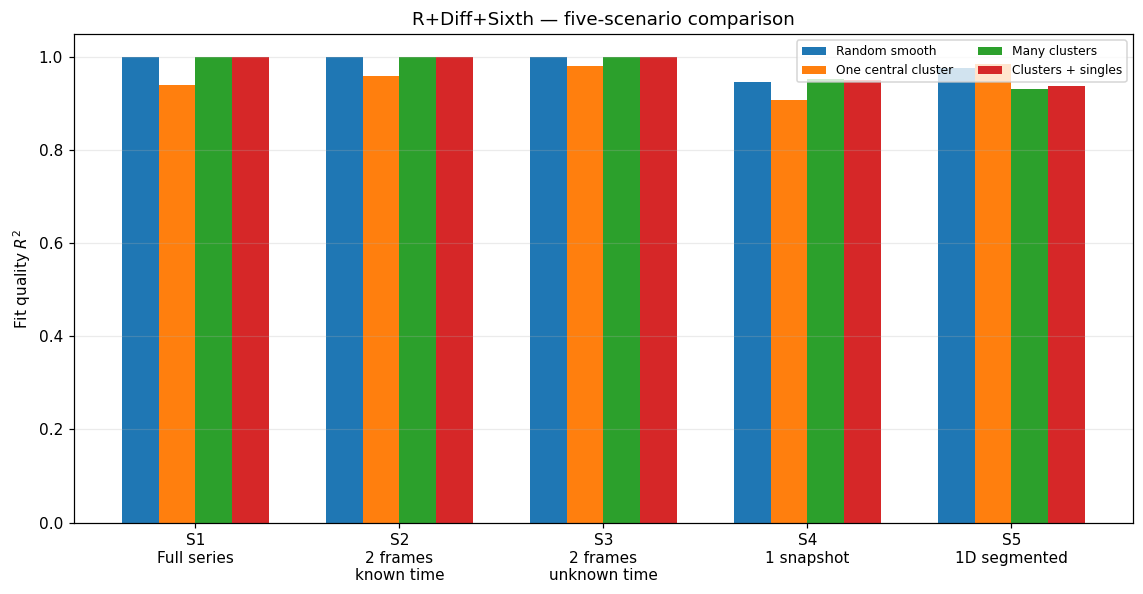

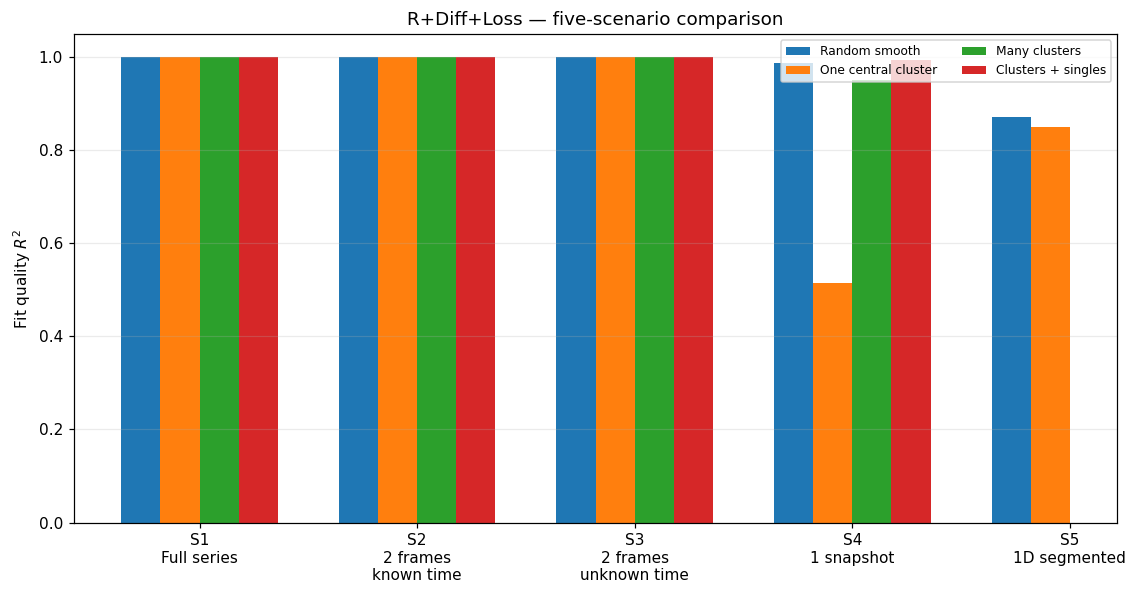

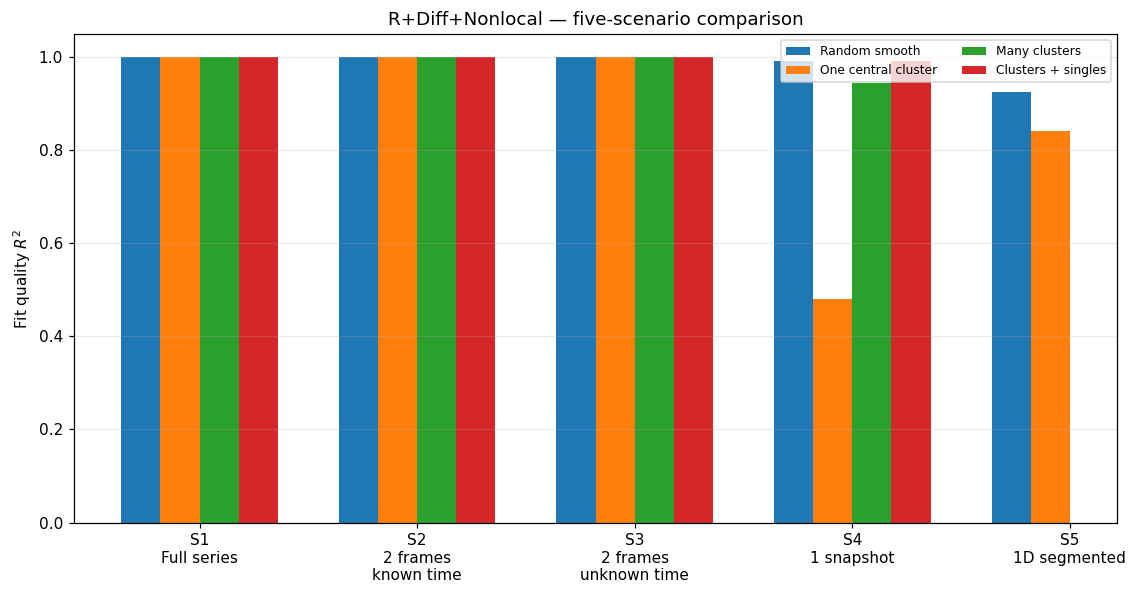

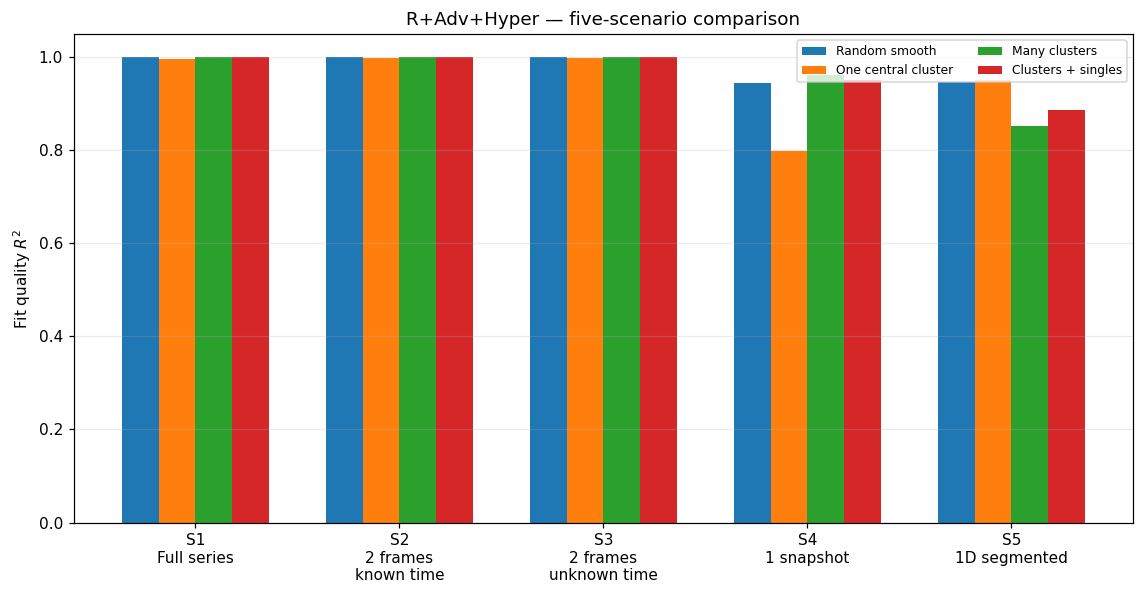

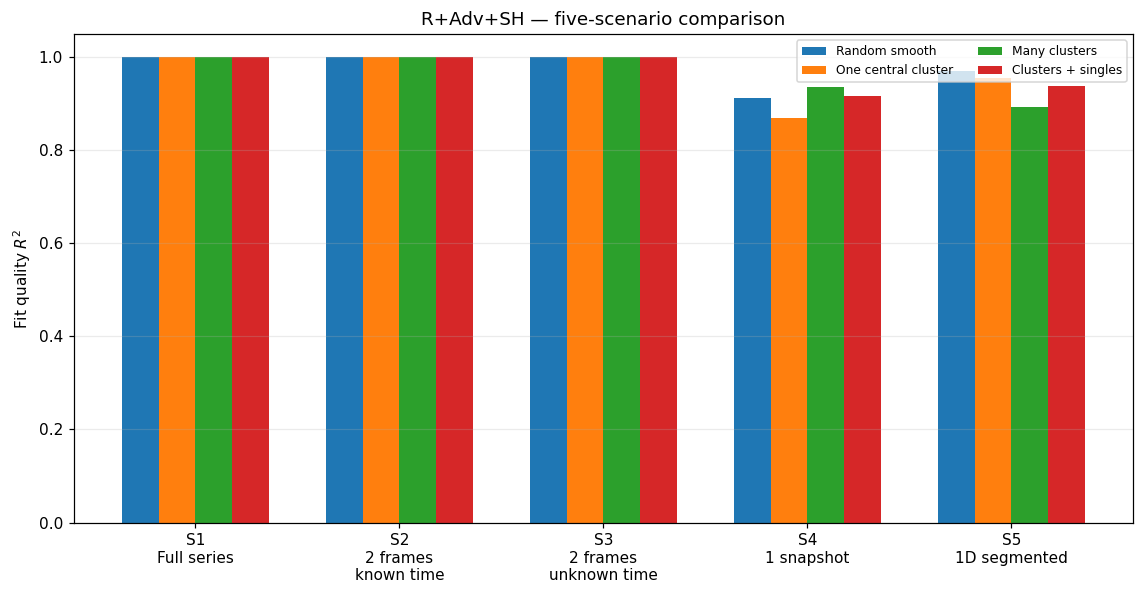

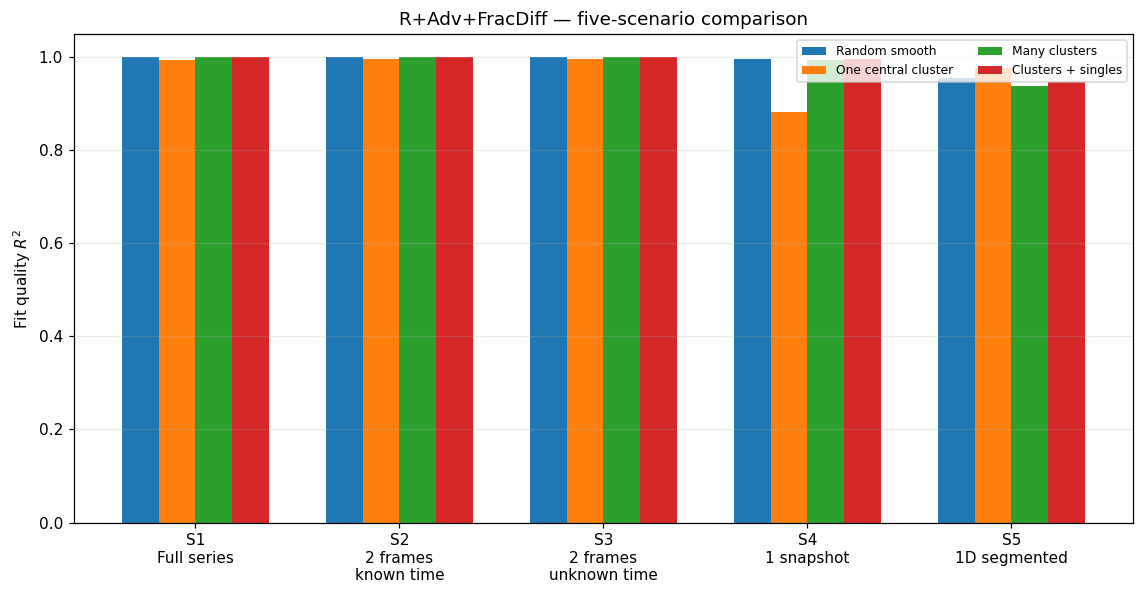

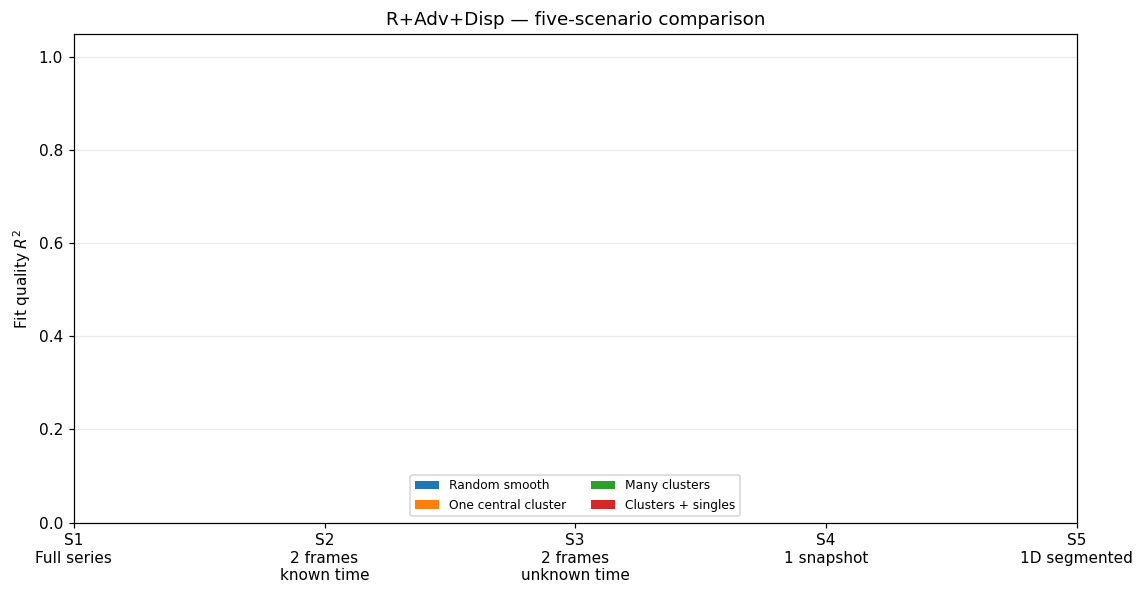

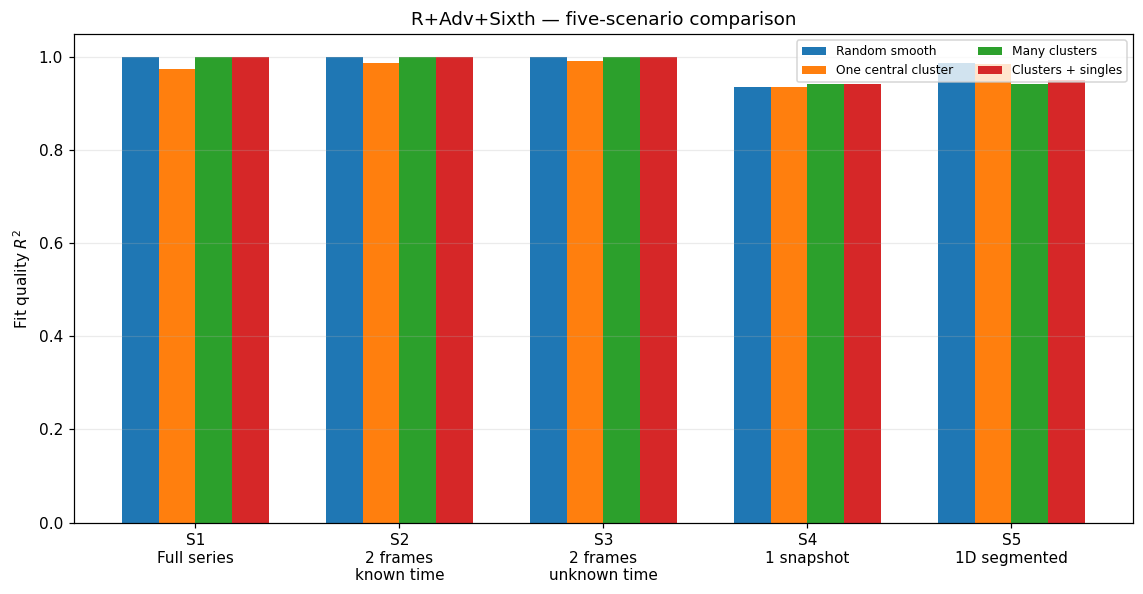

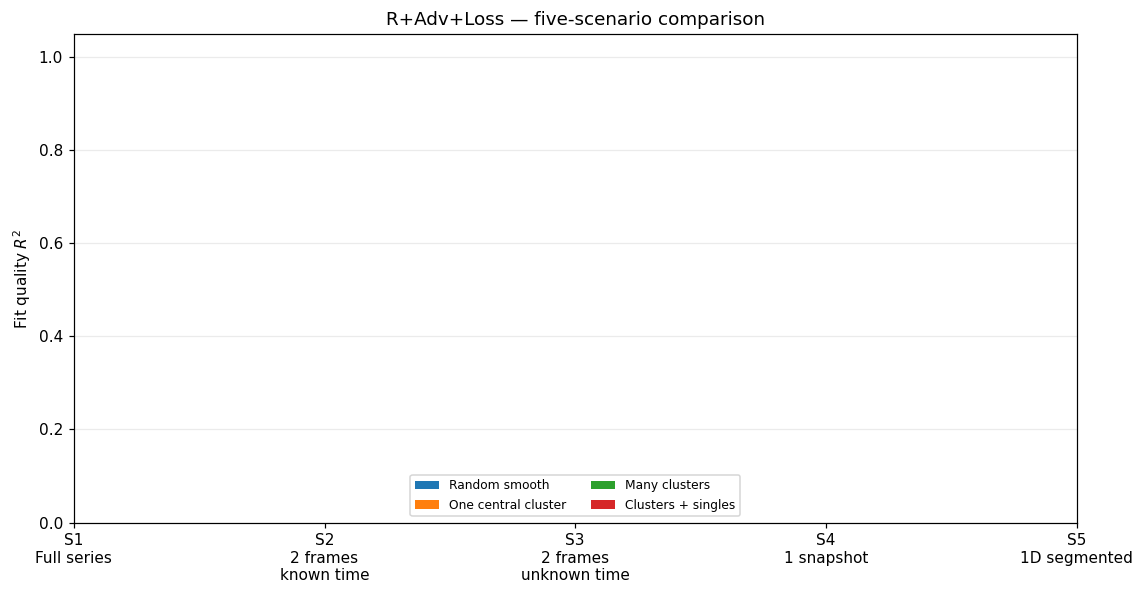

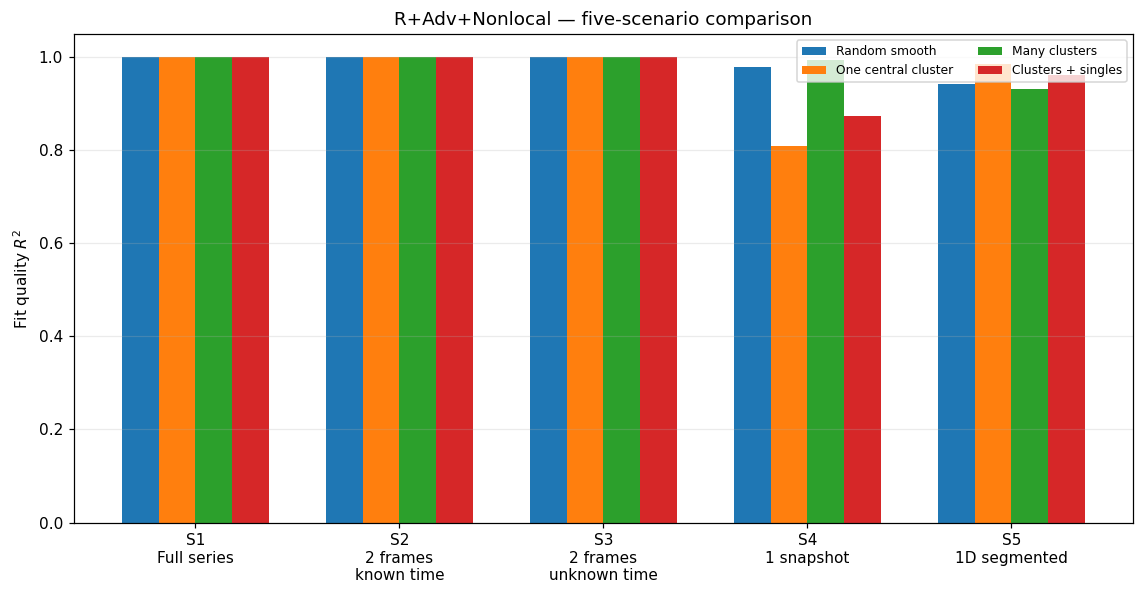

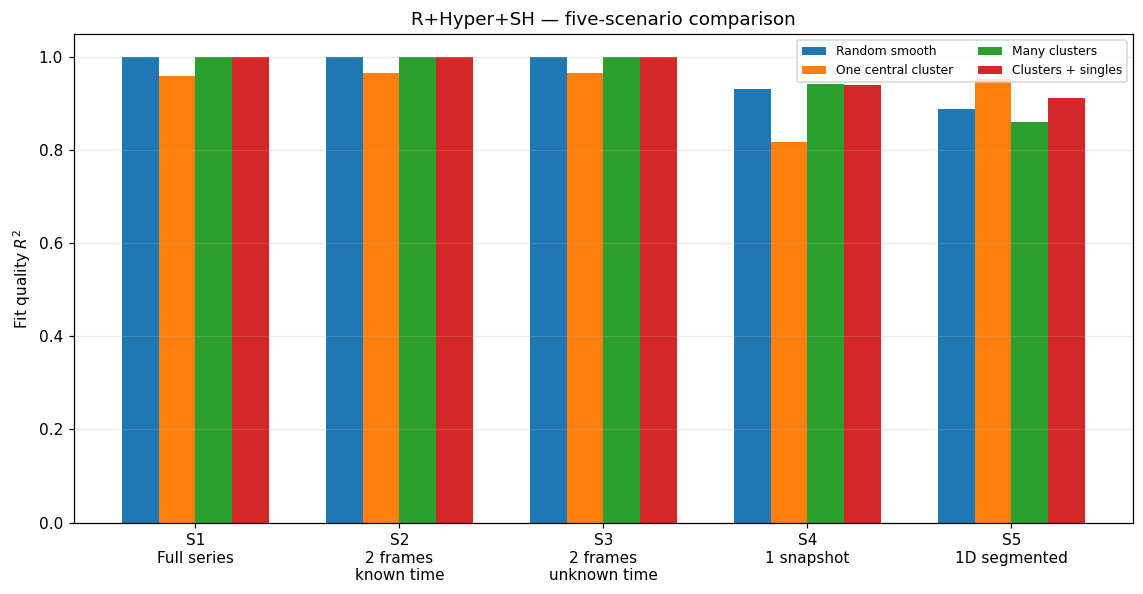

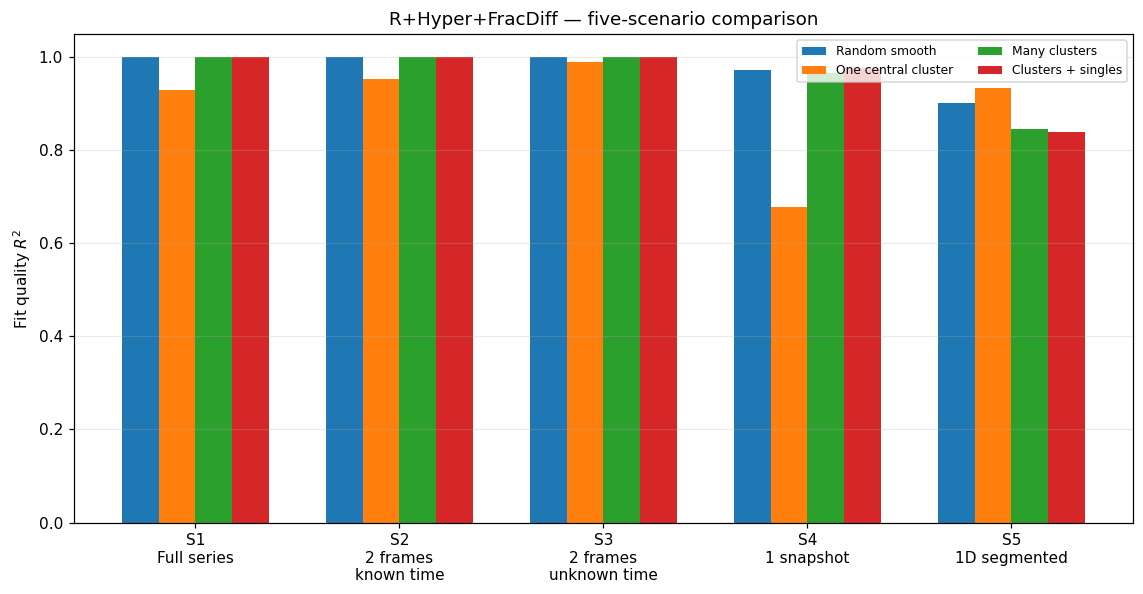

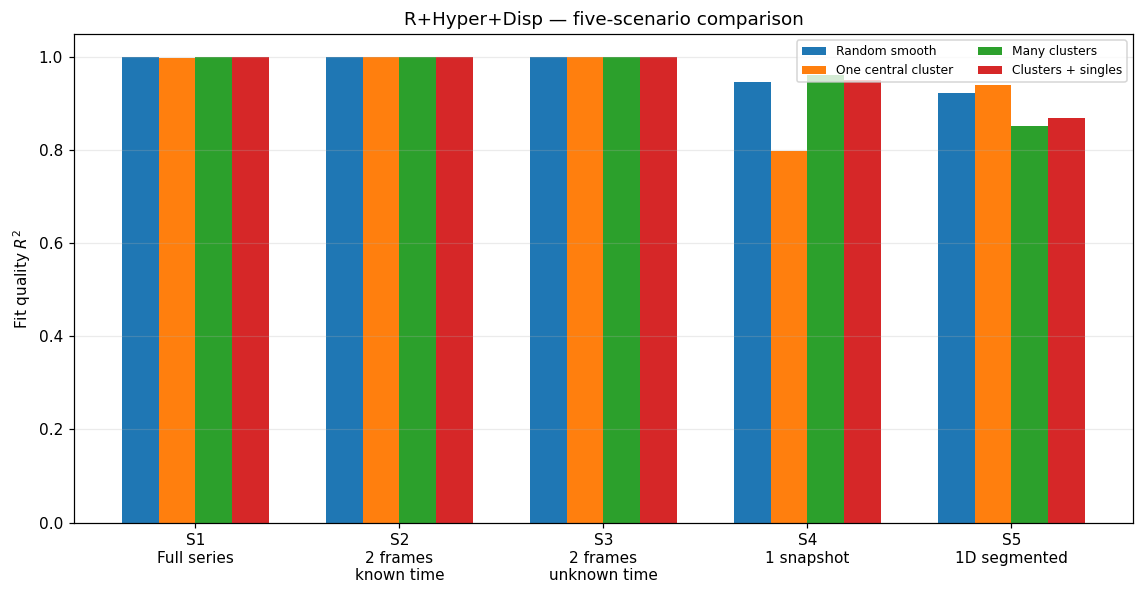

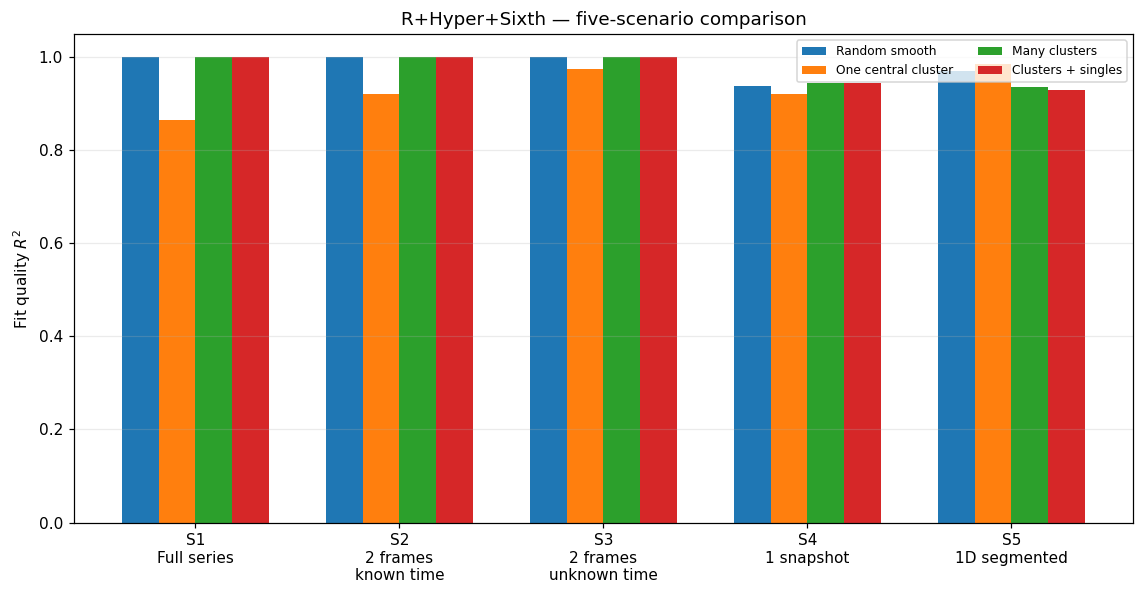

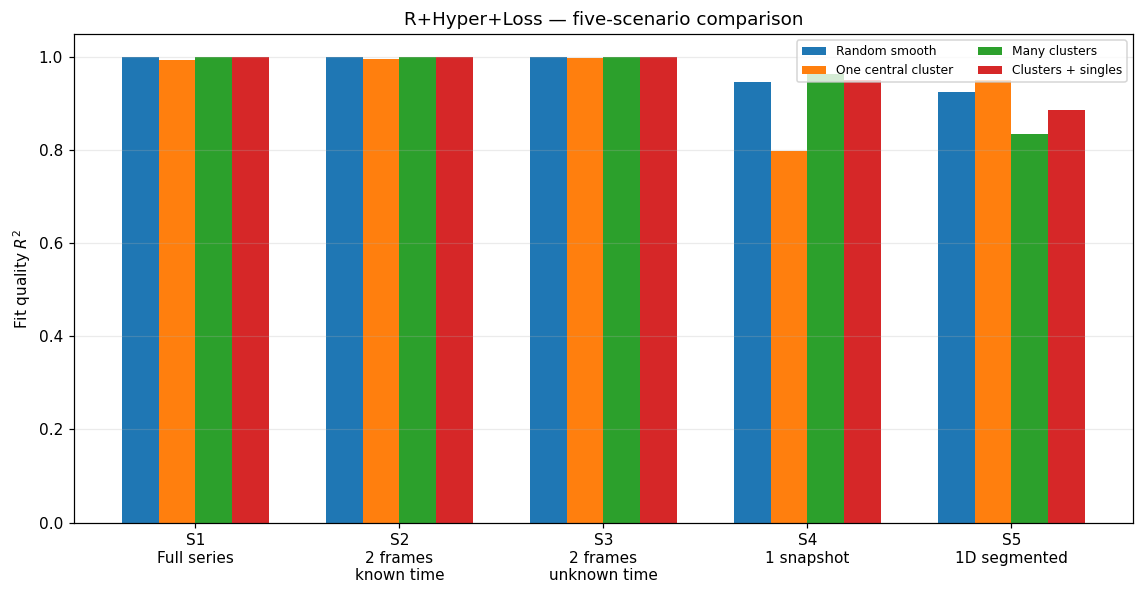

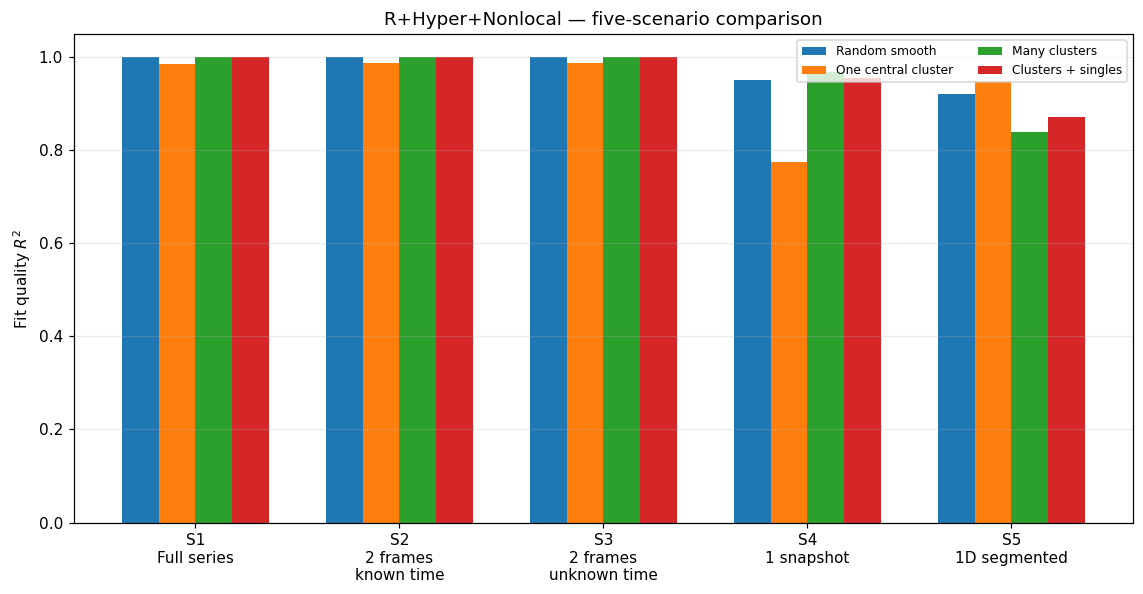

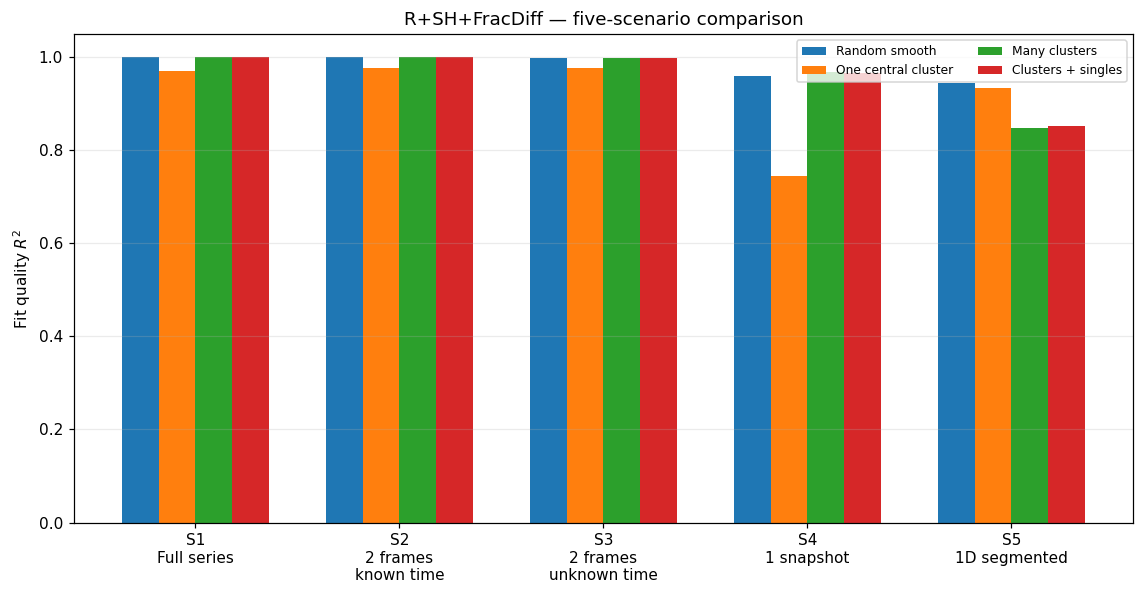

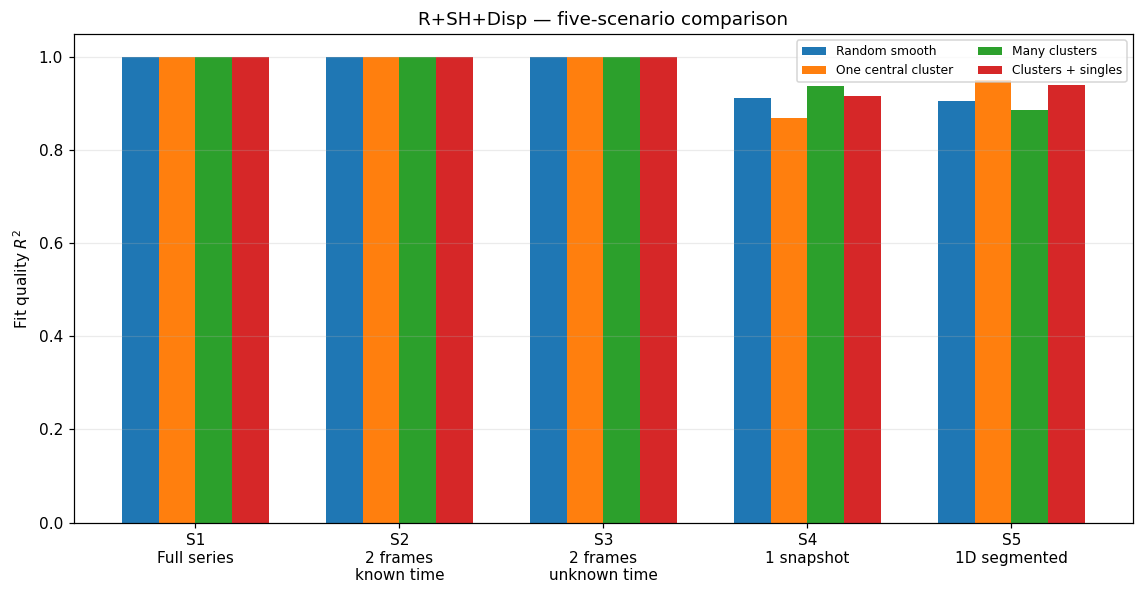

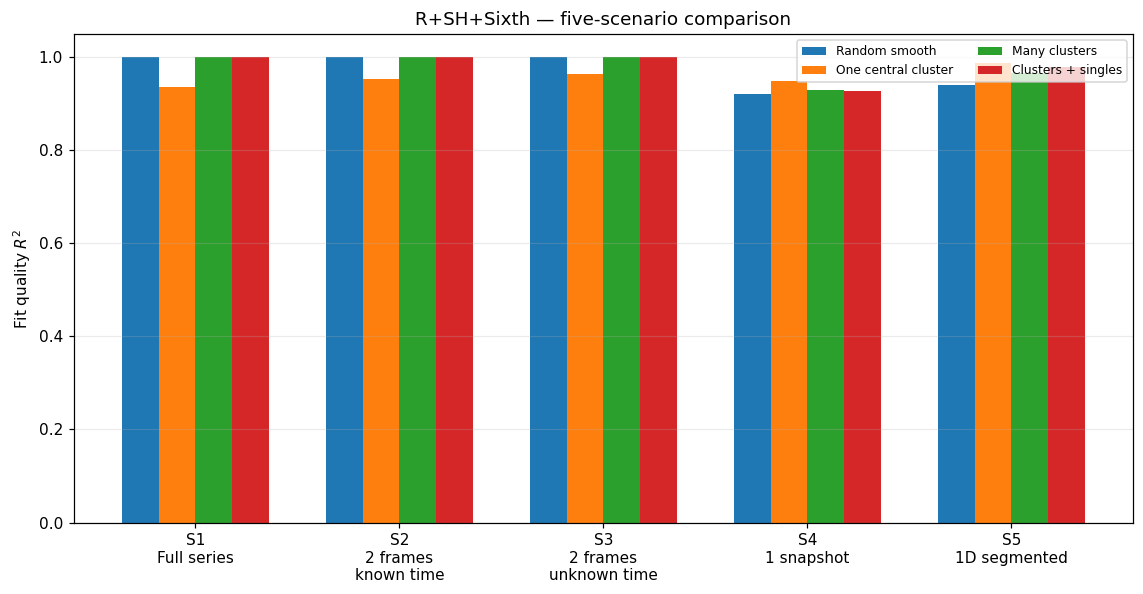

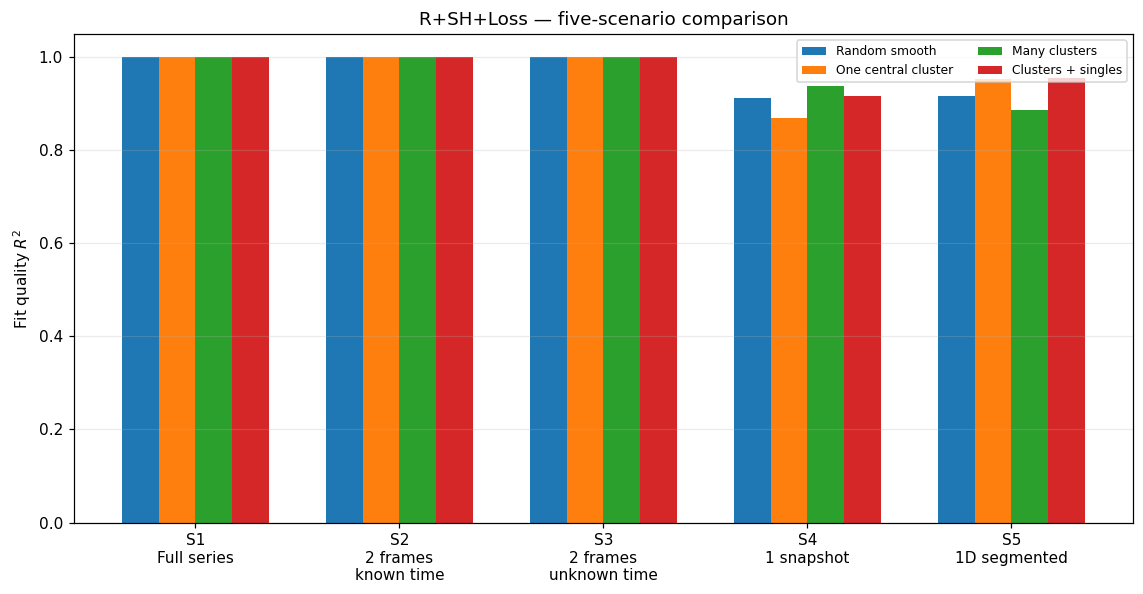

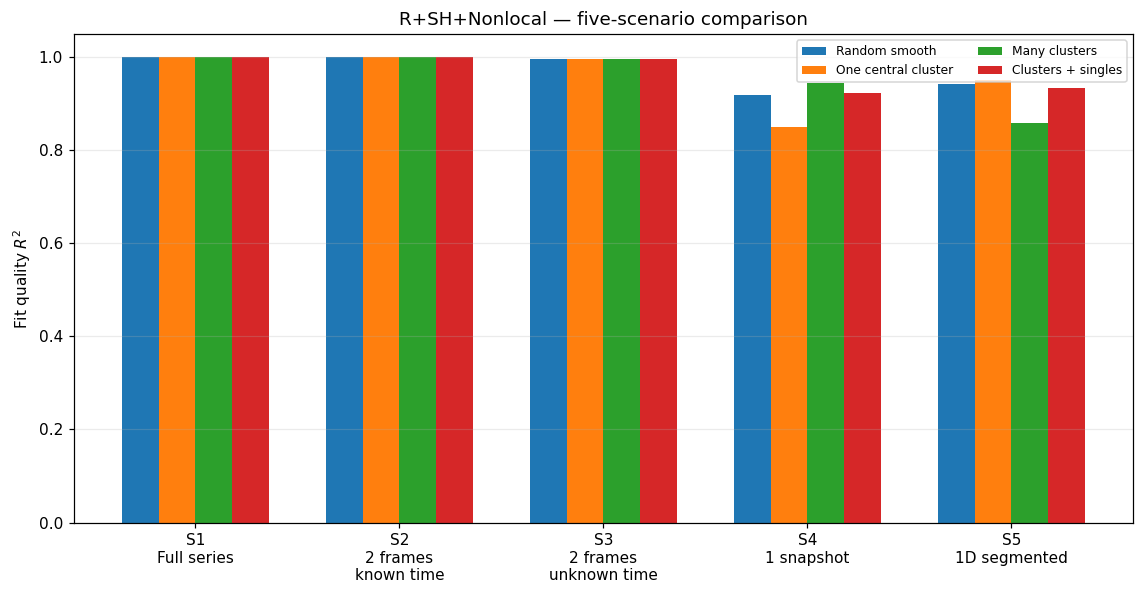

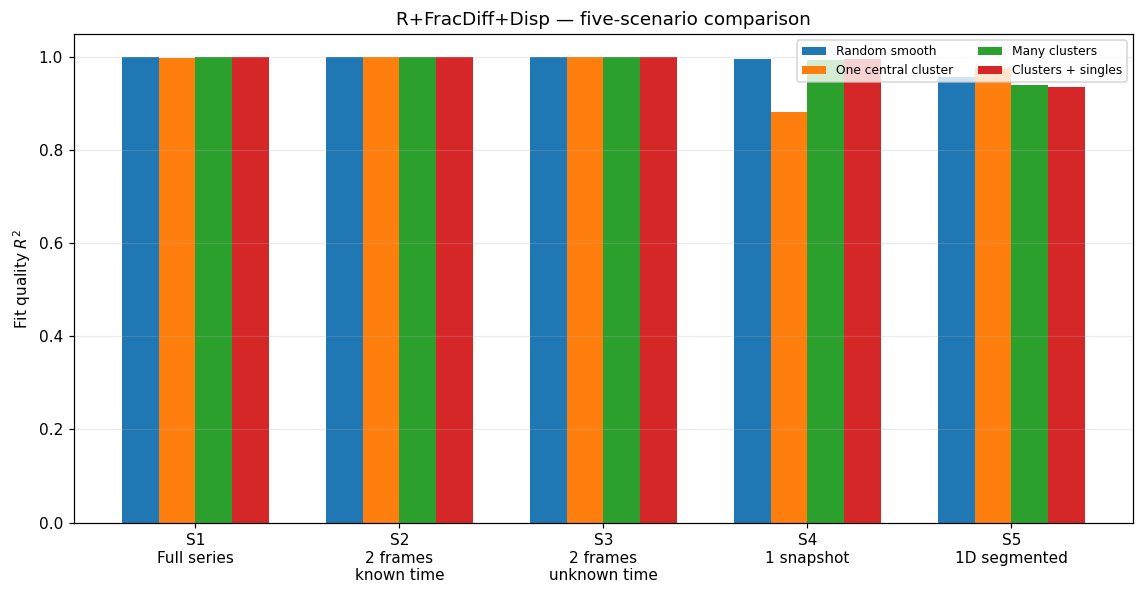

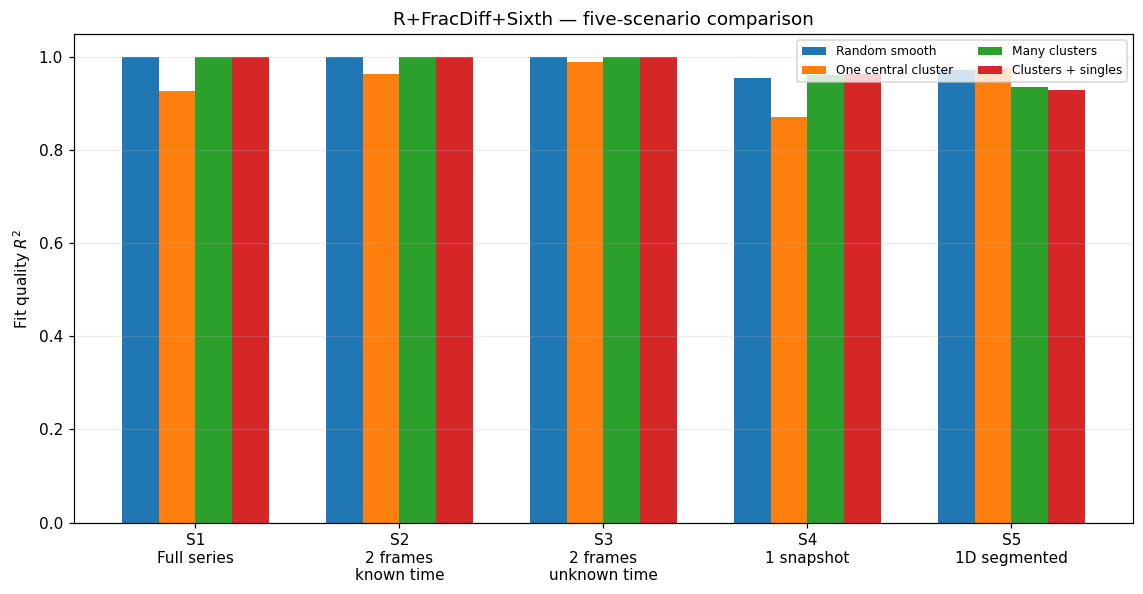

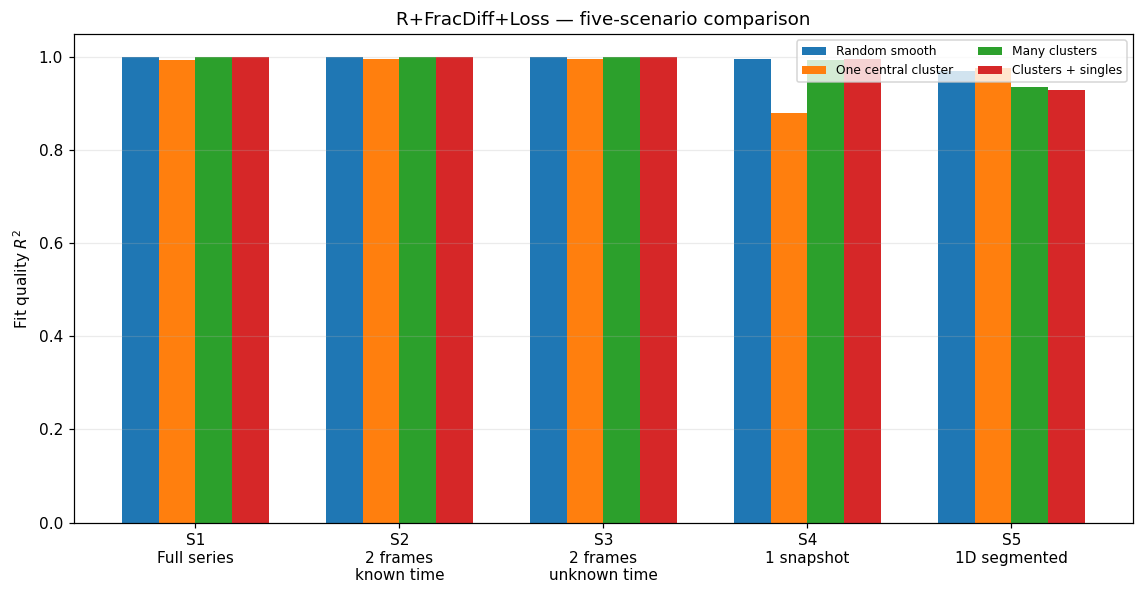

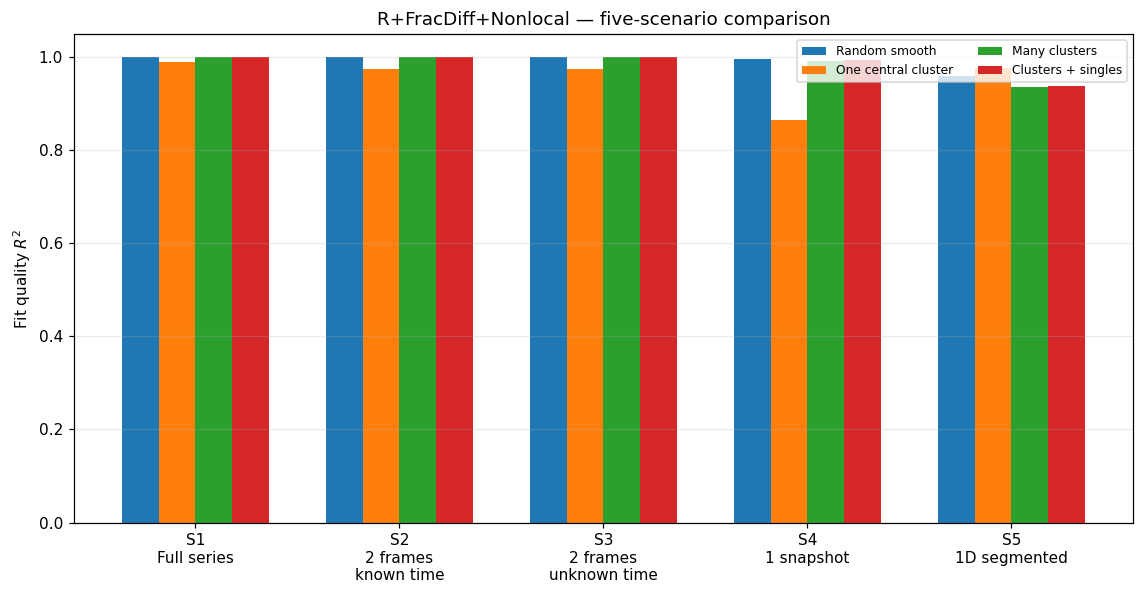

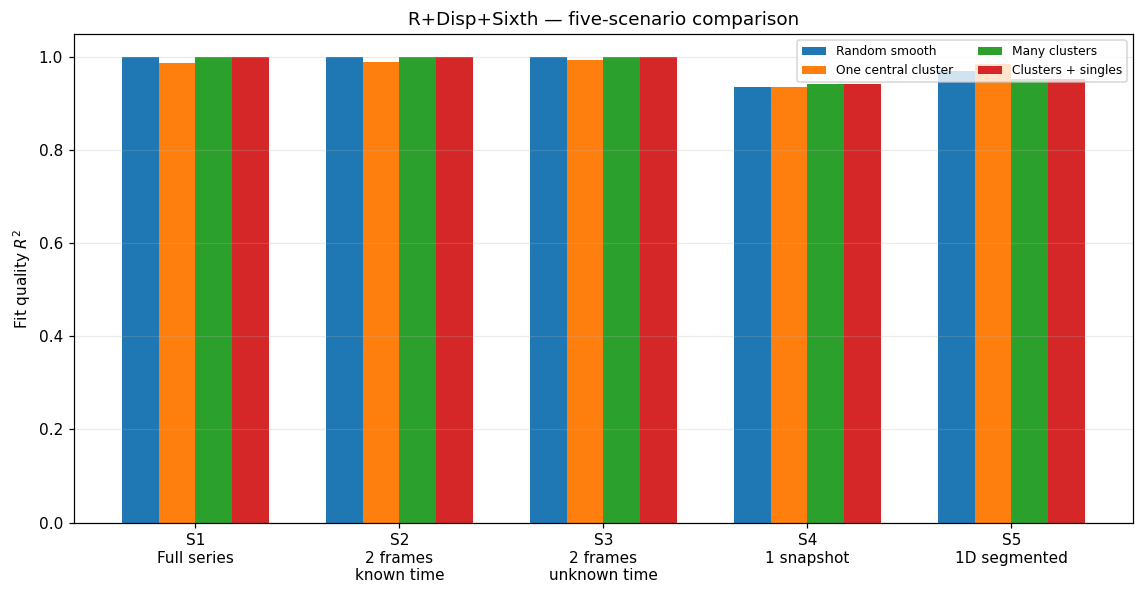

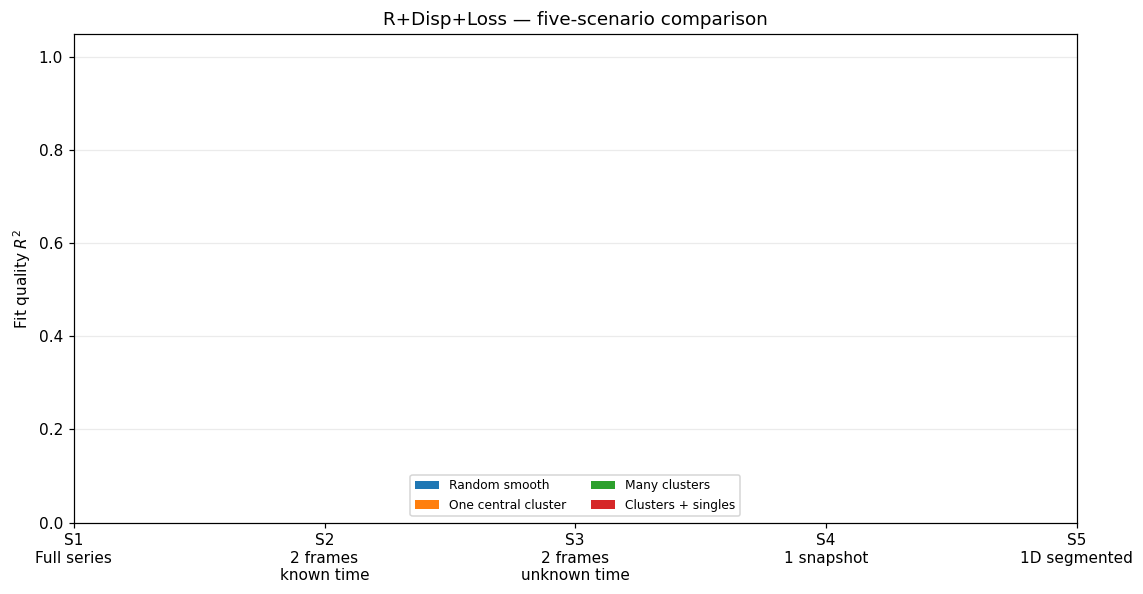

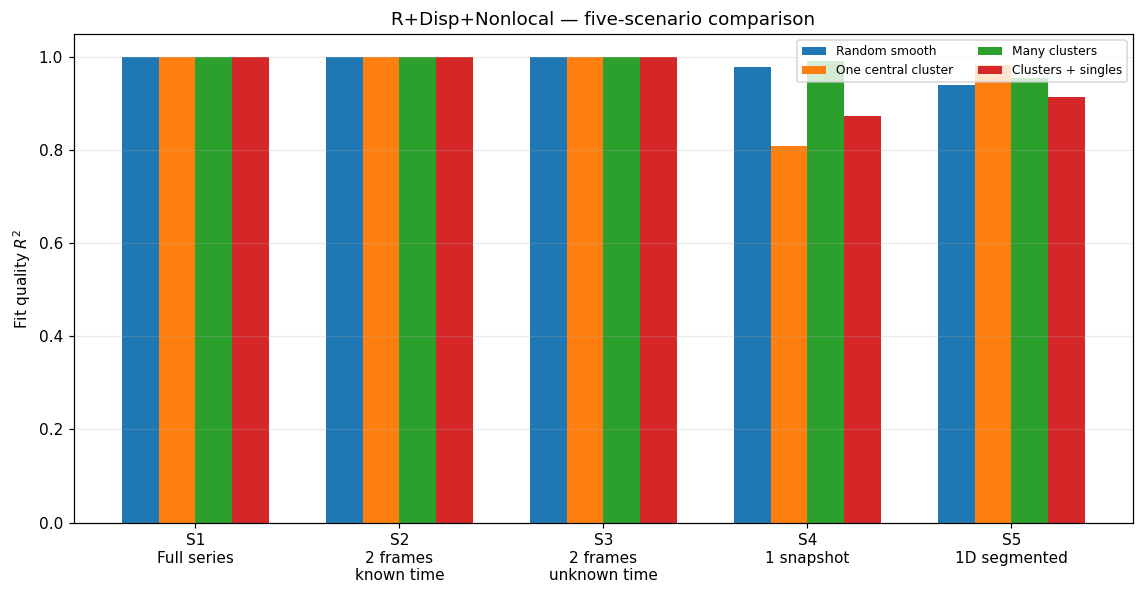

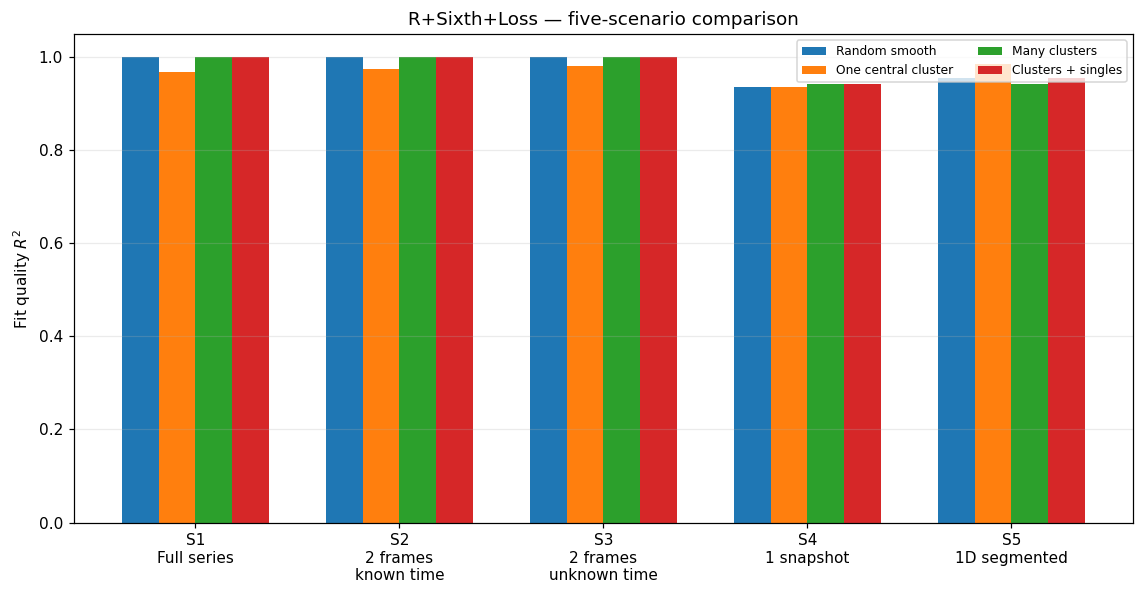

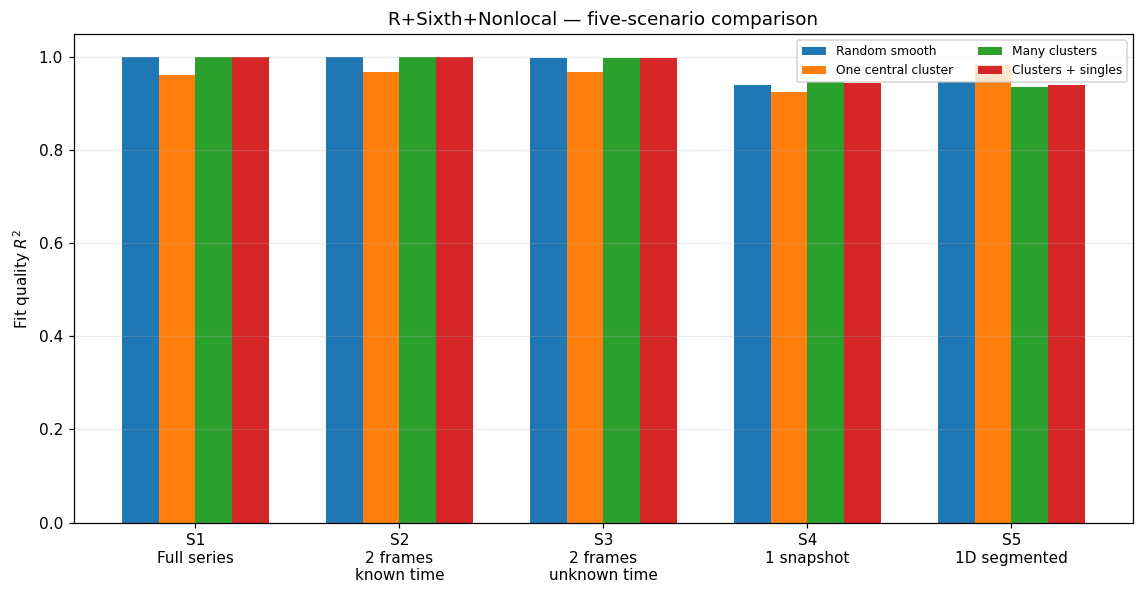

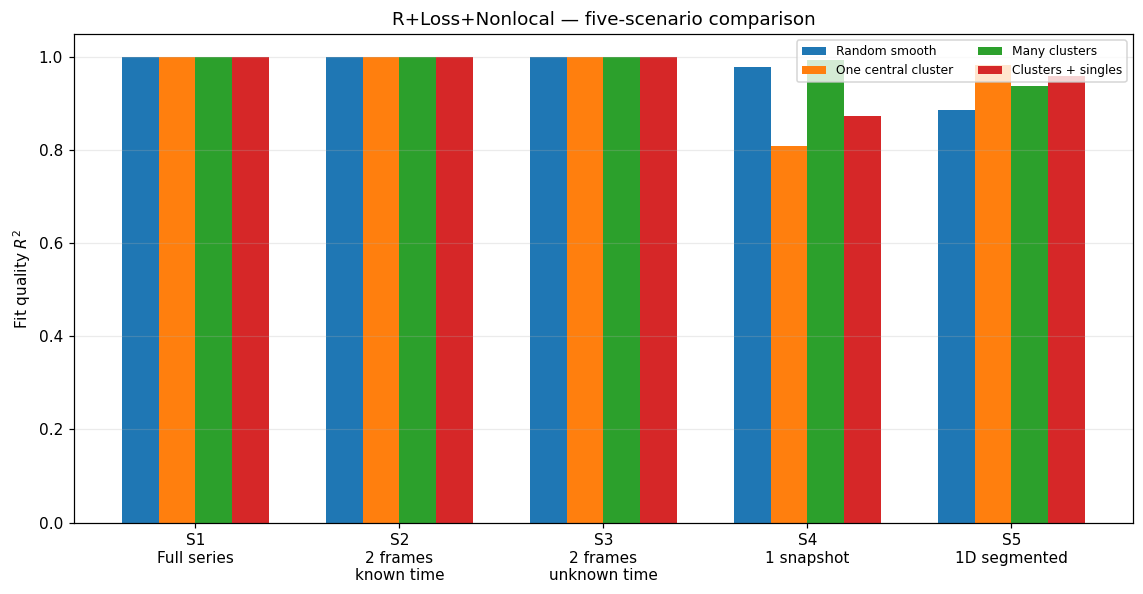

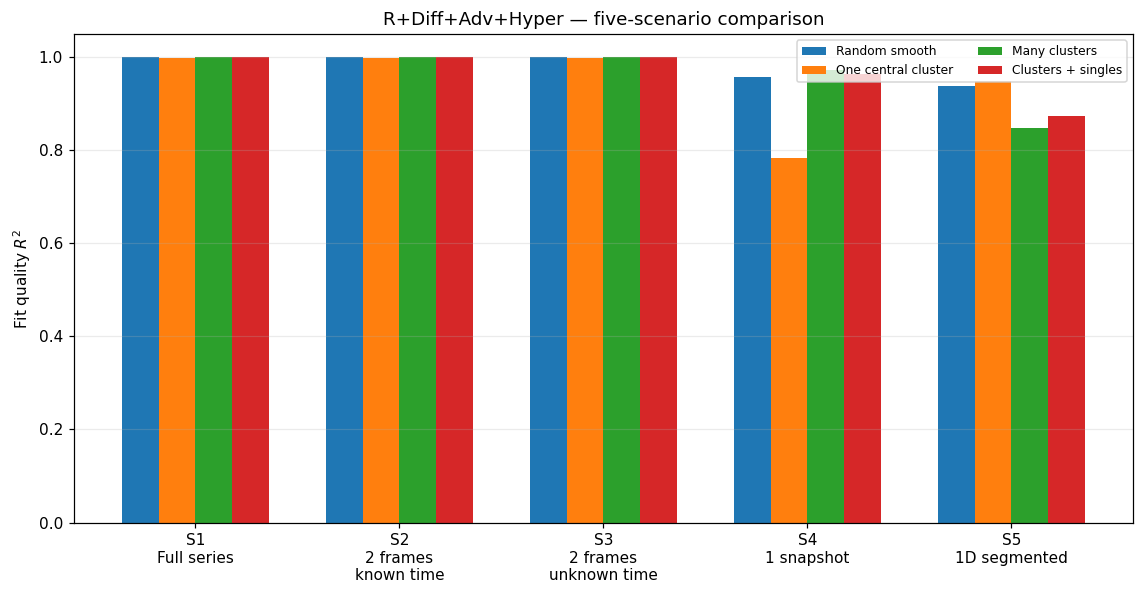

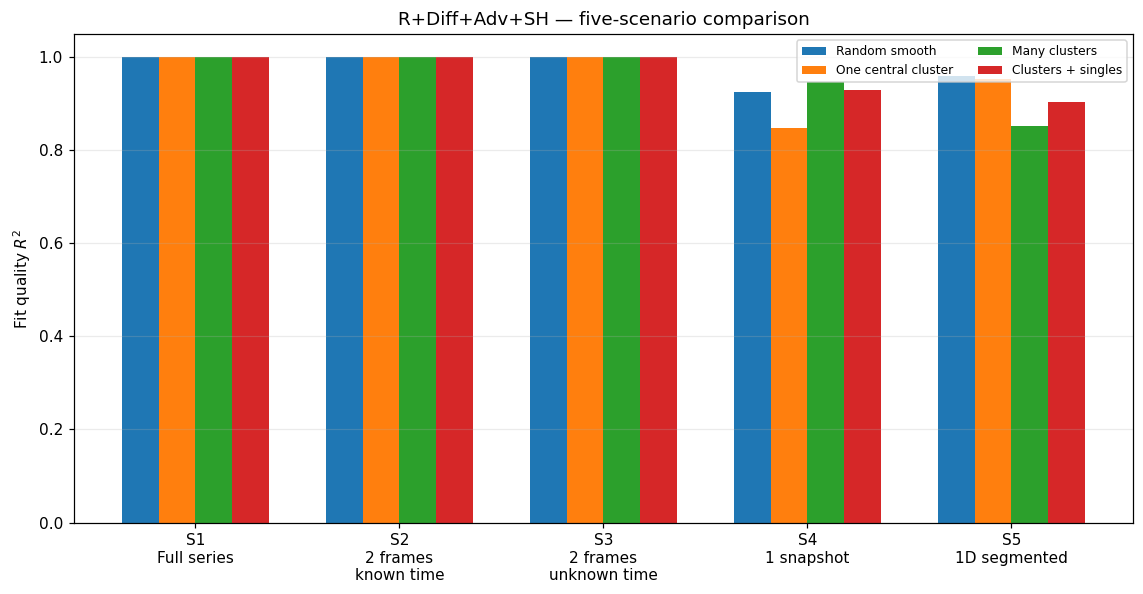

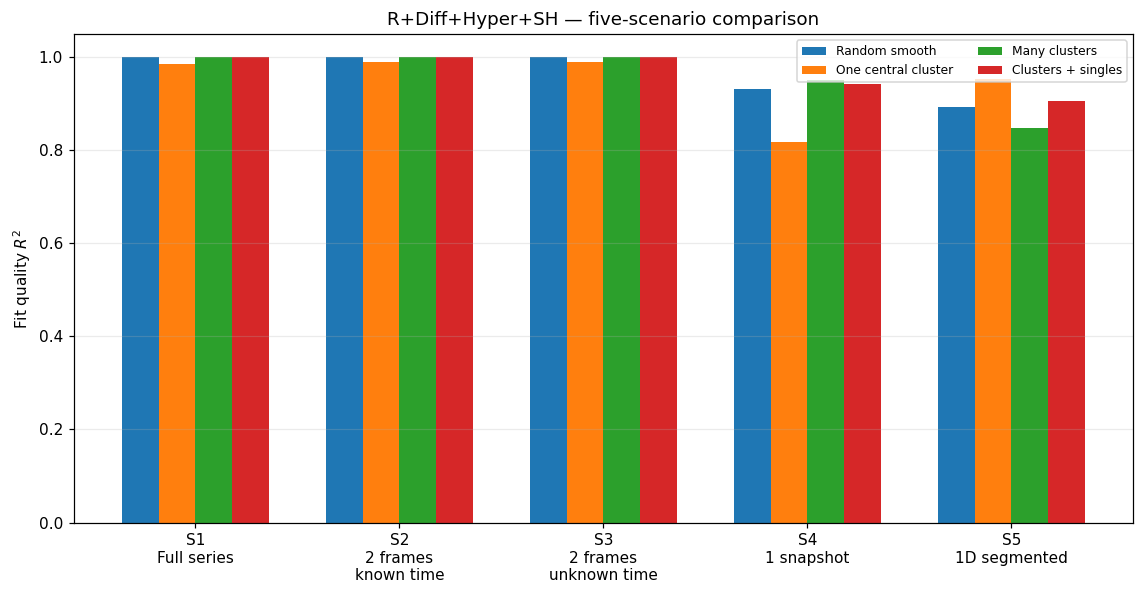

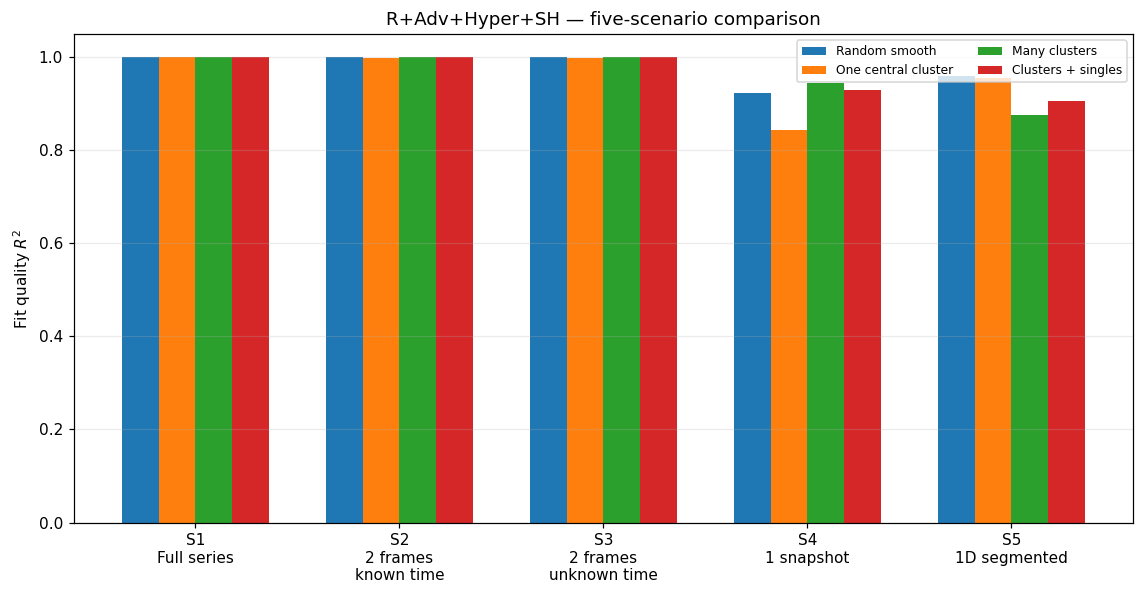

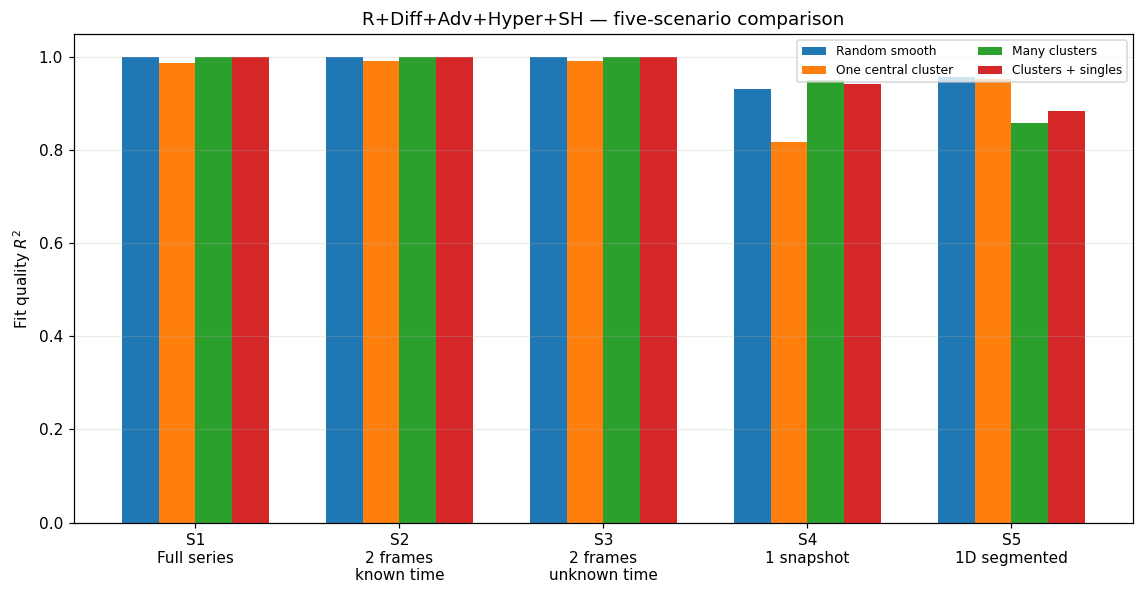

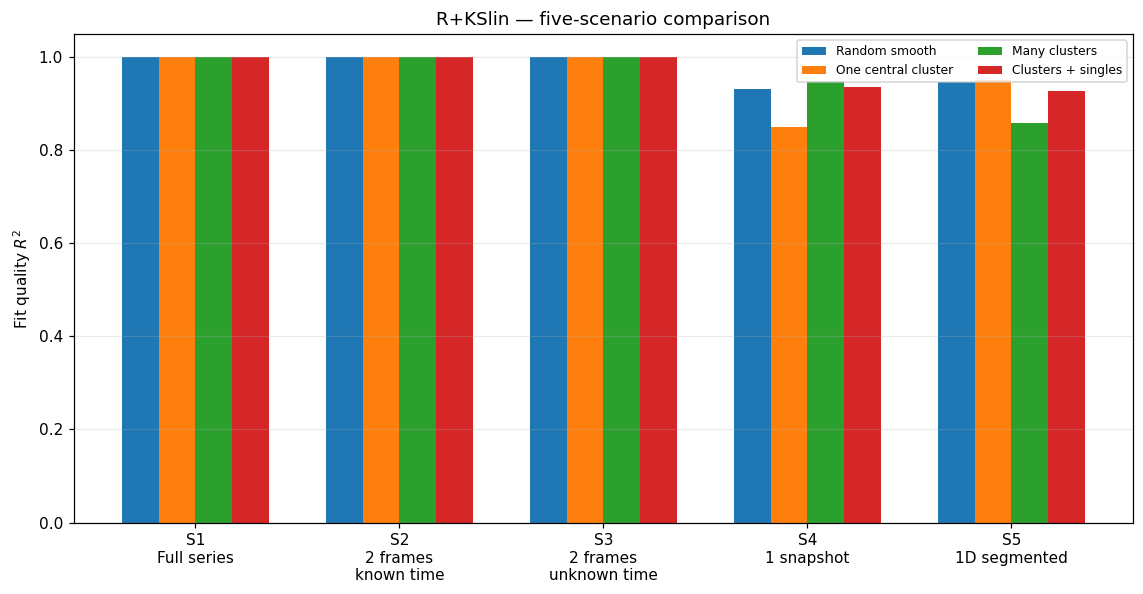

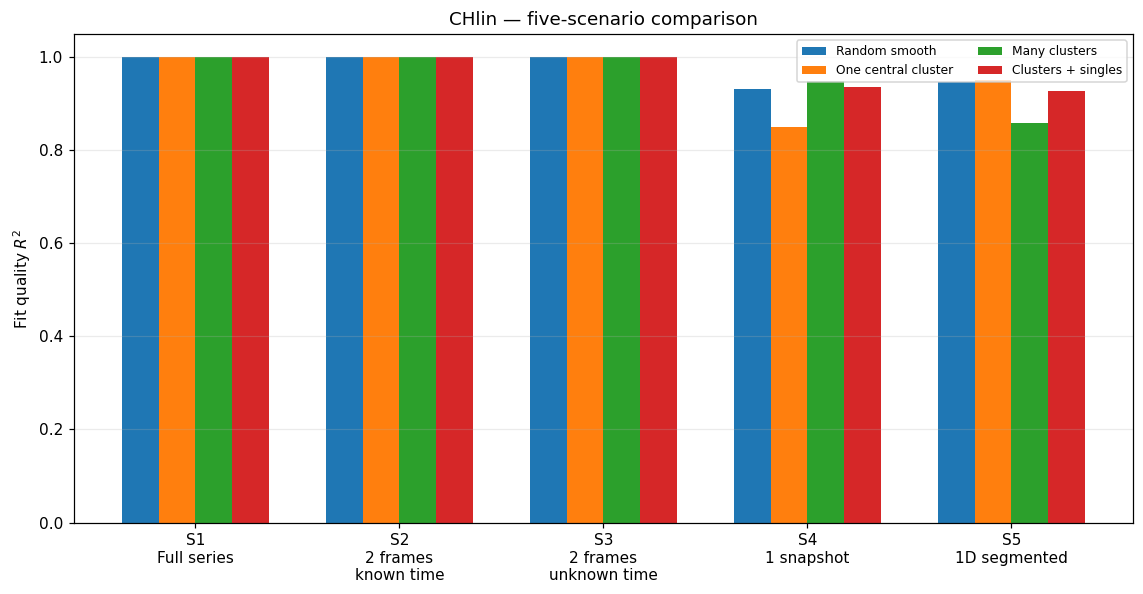

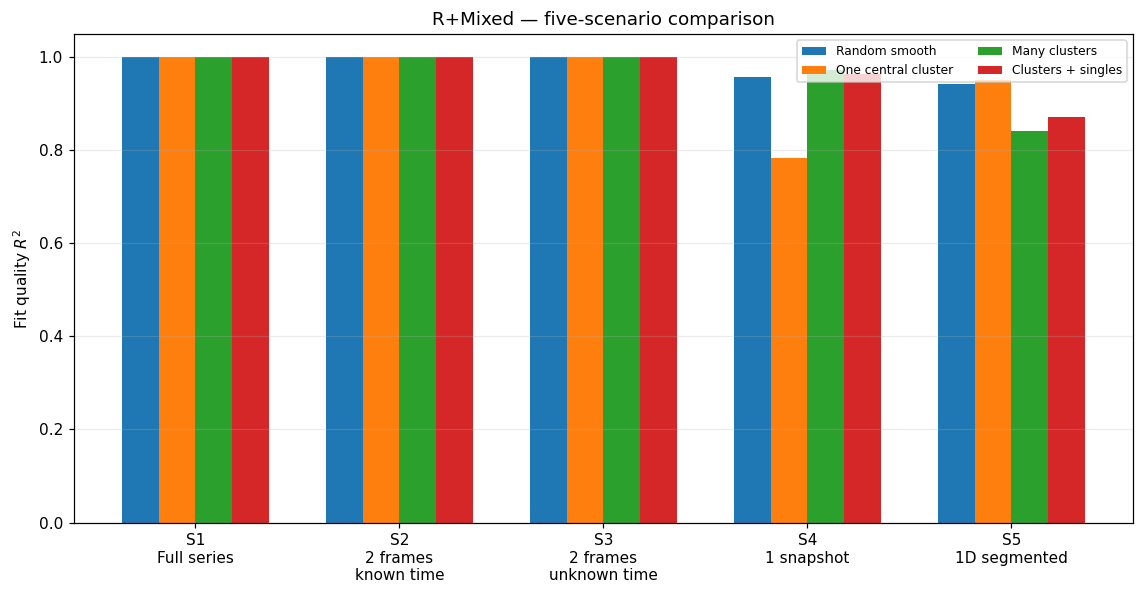

Generated five-scenario comparison plots for 53 PDEs.


In [15]:

# ============================================================
# COMPLETE 5-SCENARIO PLOTS FOR EVERY PDE
# ============================================================

FIVE_SCENARIO_R2_TABLES = {}

for tag,res in ALL_RESULTS.items():
    ic_names = list(ICs.keys())
    scen_names = ["S1","S2","S3","S4","S5"]

    table = np.full((len(ic_names),len(scen_names)),np.nan)

    for i,ic in enumerate(ic_names):
        for j,scen in enumerate(["S1","S2","S3","S4"]):
            rr = res[scen].get(ic)
            if rr is not None and "R2" in rr:
                table[i,j] = rr["R2"]

        rr5 = res["S5"].get(ic)
        if rr5 is not None:
            # IMPORTANT: accepted-segment median only
            table[i,4] = rr5.get("median_R2",np.nan)

    FIVE_SCENARIO_R2_TABLES[tag] = pd.DataFrame(
        table,
        index=ic_names,
        columns=scen_names
    )

    fig,ax = plt.subplots(figsize=(10.5,5.5))

    xloc = np.arange(len(scen_names))
    width = 0.18
    offsets = np.linspace(-1.5*width,1.5*width,len(ic_names))

    for off,ic in zip(offsets,ic_names):
        vals = FIVE_SCENARIO_R2_TABLES[tag].loc[ic].values
        ax.bar(xloc+off,vals,width,label=ic)

    ax.set_xticks(xloc)
    ax.set_xticklabels([
        "S1\nFull series",
        "S2\n2 frames\nknown time",
        "S3\n2 frames\nunknown time",
        "S4\n1 snapshot",
        "S5\n1D segmented"
    ])
    ax.set_ylim(0,1.05)
    ax.set_ylabel(r"Fit quality $R^2$")
    ax.set_title(f"{tag} — five-scenario comparison")
    ax.grid(axis="y",alpha=.25)
    ax.legend(fontsize=8,ncol=2)

    plt.tight_layout()

    if SAVE_FIGURES:
        safe = tag.replace("+","_").replace("/","_")
        fig.savefig(
            os.path.join(FIG_DIR,f"{safe}_five_scenarios.png"),
            dpi=180,bbox_inches="tight"
        )

    plt.show()

print("Generated five-scenario comparison plots for",len(FIVE_SCENARIO_R2_TABLES),"PDEs.")



# 15. Final comparison plots across all PDEs

These plots summarize the entire model library after the individual PDE analyses are complete.

They include:

1. theoretical PSD-visible dispersion signatures;
2. median S1/S2 parameter-recovery error;
3. median \(R^2\) across all four ICs for S1–S5;
4. scenario-specific heatmaps;
5. identifiability / recoverability map;
6. Scenario-5 accepted-segment fraction;
7. Scenario-5 detailed reaction–diffusion grid sweep;
8. overall ranking summaries, separated by scenario so unlike \(R^2\) definitions are not mixed into one score.


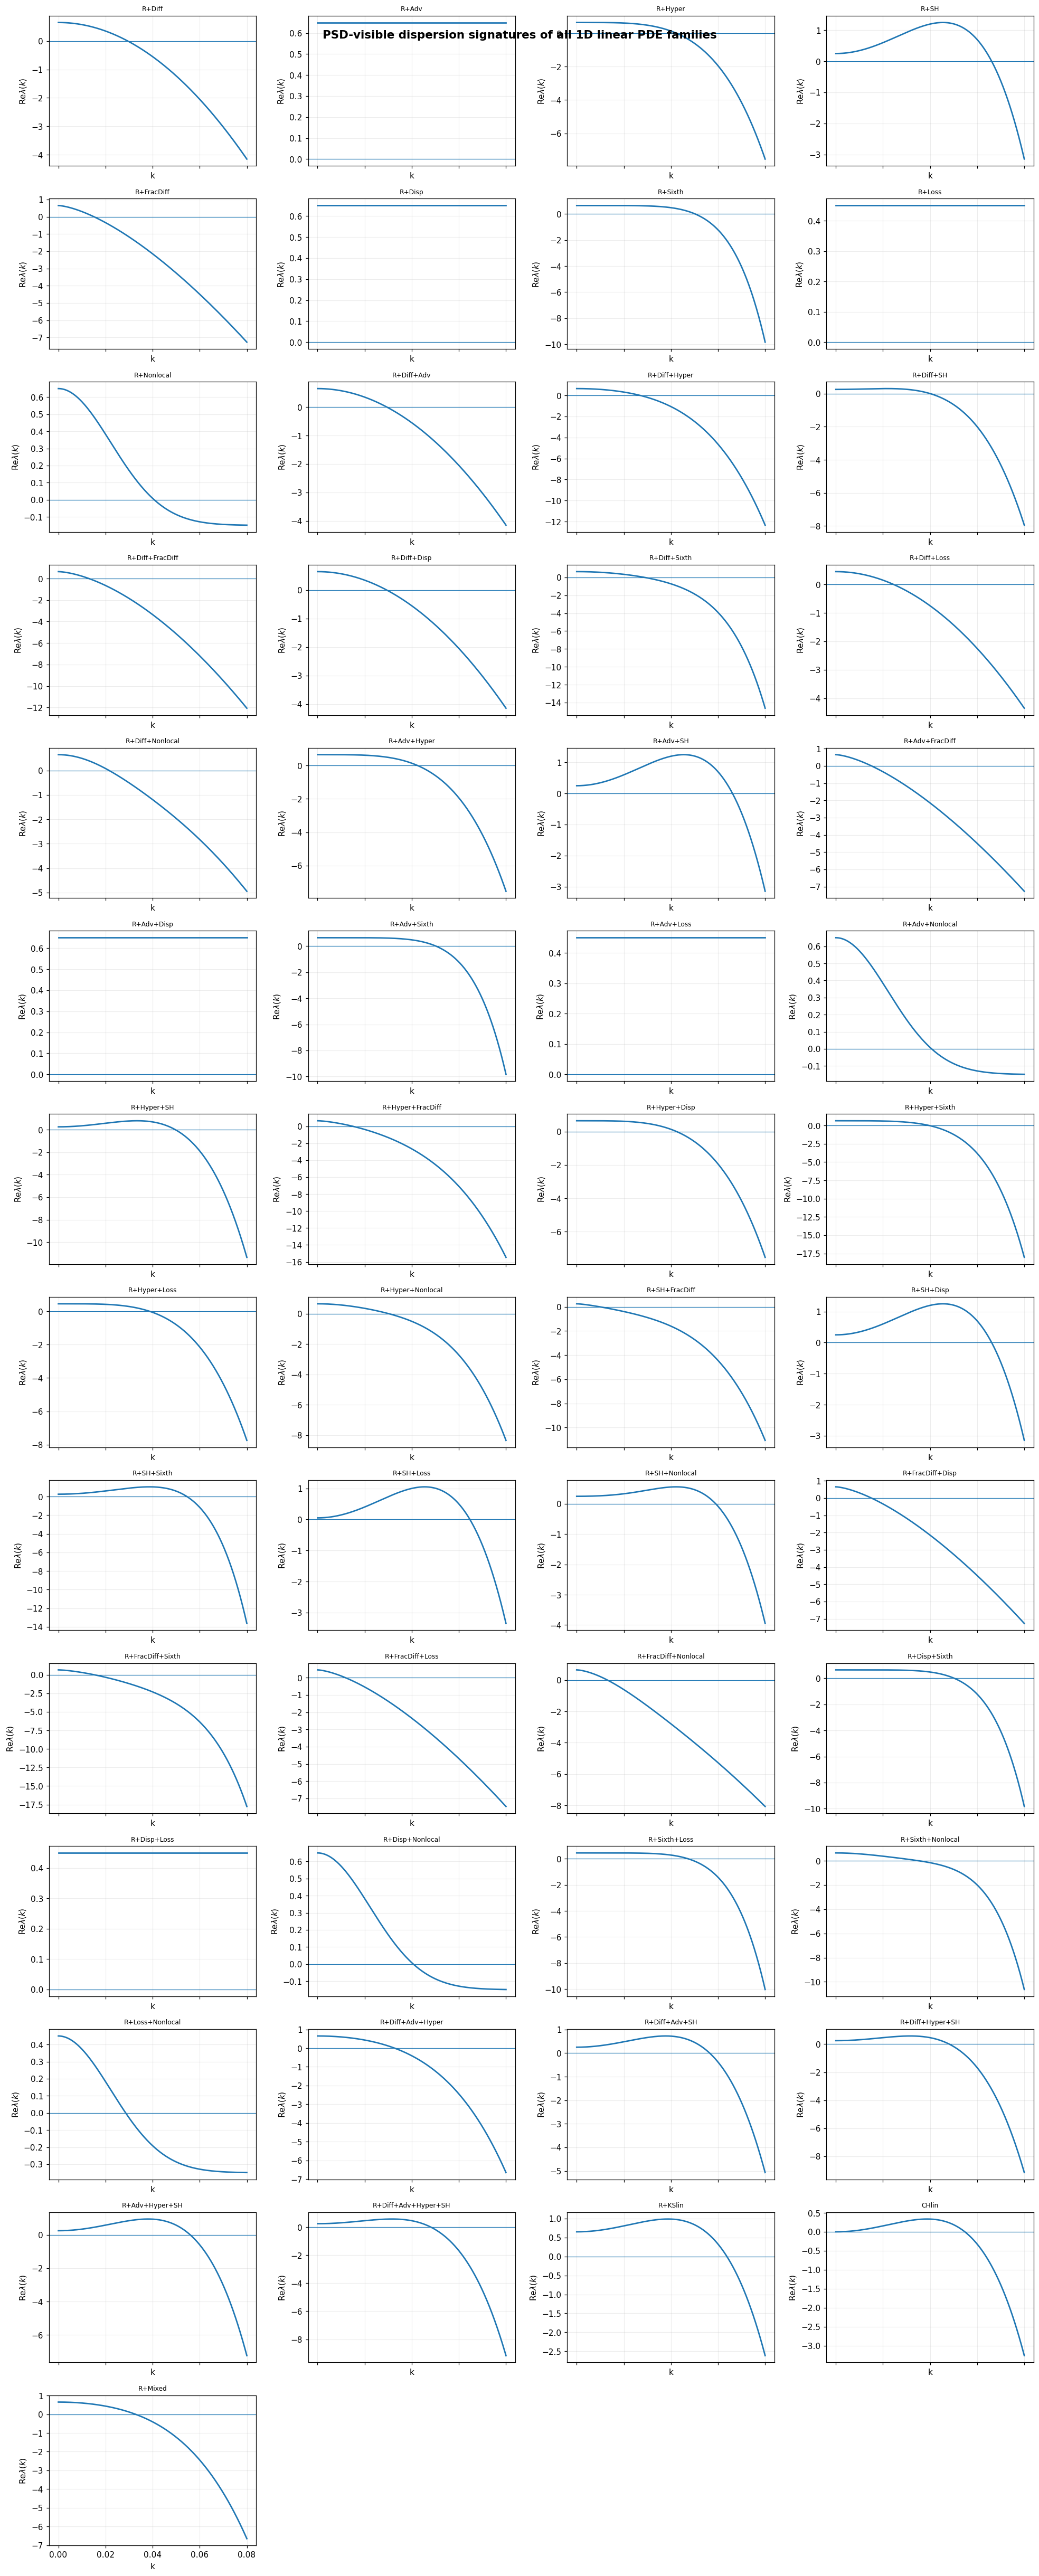

In [16]:

# ============================================================
# FINAL COMPARISON 1 — THEORETICAL PSD-VISIBLE SYMBOLS
# ============================================================

n_models = len(MODEL_LIBRARY)
ncols = 4
nrows = int(np.ceil(n_models/ncols))

fig,axs = plt.subplots(nrows,ncols,figsize=(18,3.2*nrows),sharex=True)
axs = np.atleast_1d(axs).ravel()

kplot = np.linspace(0,0.08,500)

for ax,(tag,spec) in zip(axs,MODEL_LIBRARY.items()):
    p = spec["true"]
    ax.plot(kplot,real_symbol(kplot,tag,p),linewidth=1.8)
    ax.axhline(0,linewidth=.8)
    ax.set_title(tag,fontsize=8)
    ax.set_xlabel("k")
    ax.set_ylabel(r"$\mathrm{Re}\lambda(k)$")
    ax.grid(alpha=.22)

for ax in axs[n_models:]:
    ax.axis("off")

fig.suptitle(
    "PSD-visible dispersion signatures of all 1D linear PDE families",
    fontsize=14,fontweight="bold"
)
plt.tight_layout()
plt.show()


,PDE,Scenario,MedianAbsPercentError,MeanAbsPercentError
0,R+Diff,S1,2.118728e-09,0.070127
1,R+Diff,S2,1.930059e-09,0.063833
2,R+Adv,S1,8.967186e-13,0.000080
3,R+Adv,S2,1.187085e-12,0.000049
4,R+Hyper,S1,2.328387e-08,0.820078
...,...,...,...,...
101,R+KSlin,S2,5.638823e-10,0.016139
102,CHlin,S1,1.079426e-09,0.021577
103,CHlin,S2,7.731657e-10,0.017520
104,R+Mixed,S1,1.587605e-09,0.680719


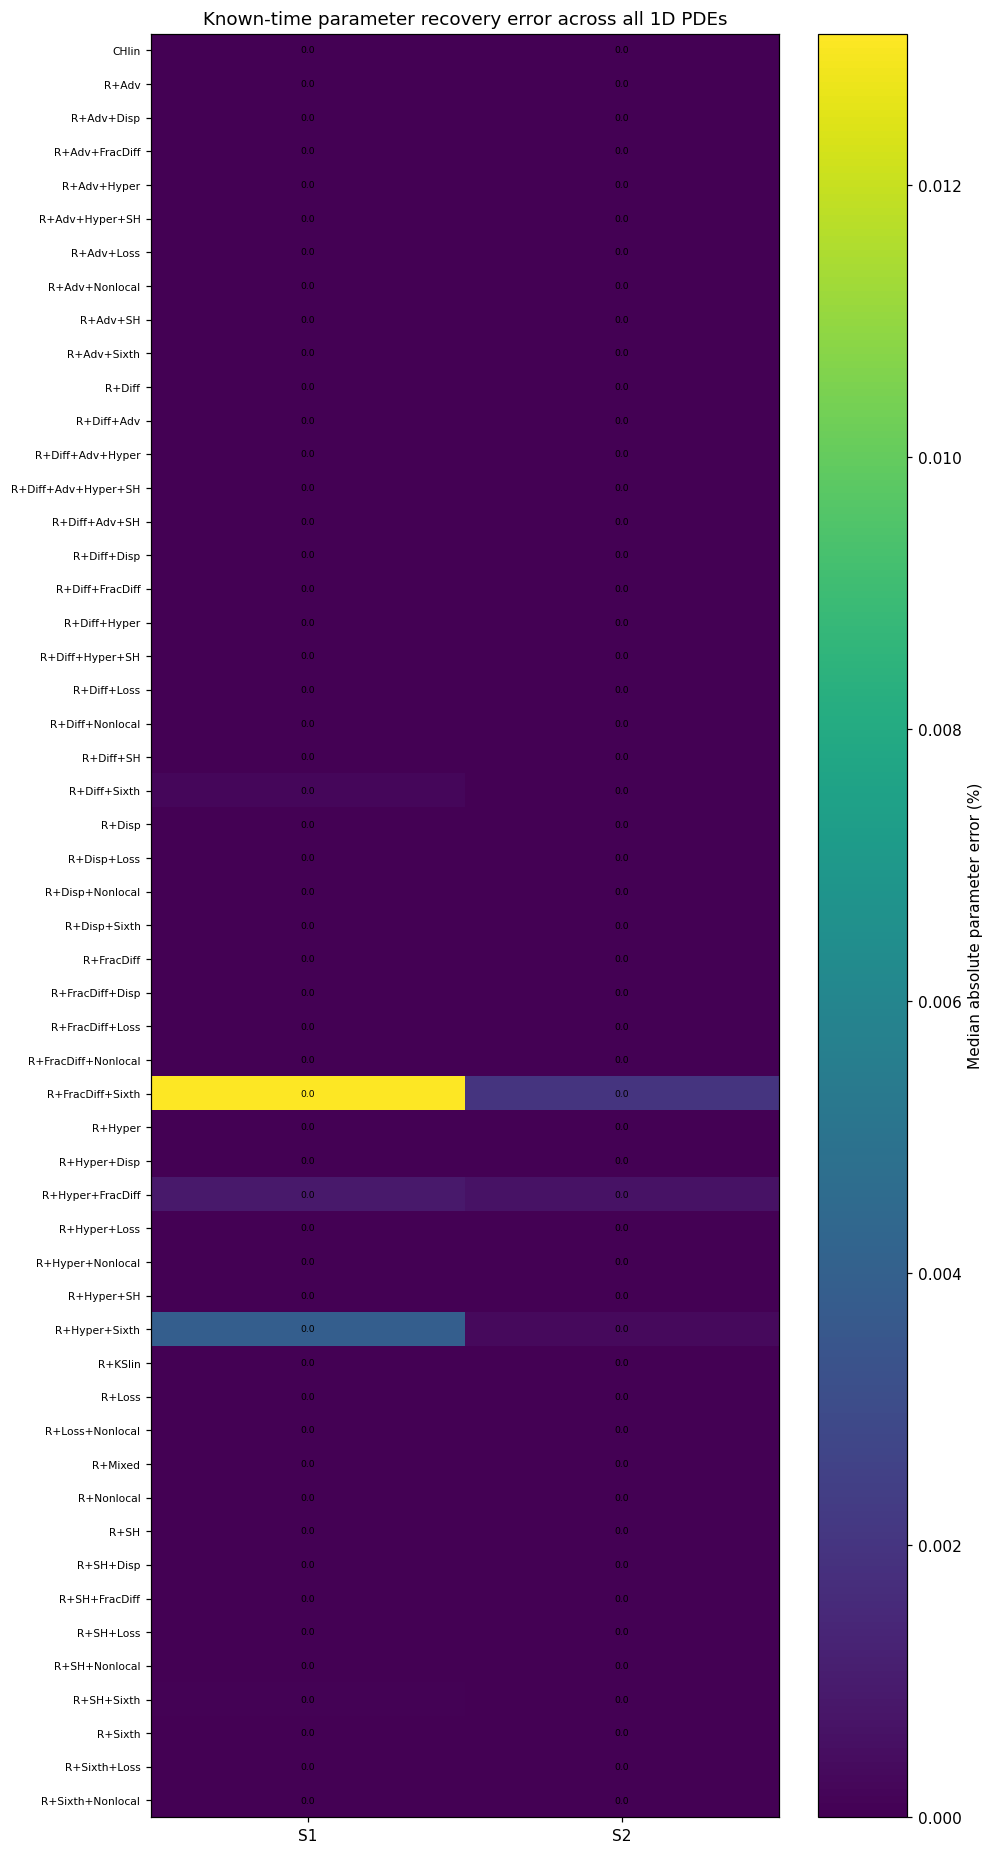

In [17]:

# ============================================================
# FINAL COMPARISON 2 — S1 / S2 PARAMETER RECOVERY ERROR
# ============================================================

err_rows=[]

for tag,res in ALL_RESULTS.items():
    for scen in ("S1","S2"):
        errs=[]

        for ic,rr in res[scen].items():
            if rr is None:
                continue

            for pname,est in rr.get("fit",{}).items():
                tv = true_identifiable_value(tag,pname)

                if np.isfinite(tv) and abs(tv)>1e-30:
                    errs.append(abs(relative_error(est,tv)))

        err_rows.append({
            "PDE":tag,
            "Scenario":scen,
            "MedianAbsPercentError":np.nanmedian(errs) if errs else np.nan,
            "MeanAbsPercentError":np.nanmean(errs) if errs else np.nan,
        })

PARAM_ERROR_DF = pd.DataFrame(err_rows)
display(PARAM_ERROR_DF)

pivot = PARAM_ERROR_DF.pivot(
    index="PDE",
    columns="Scenario",
    values="MedianAbsPercentError"
).reindex(columns=["S1","S2"])

fig,ax = plt.subplots(figsize=(9,max(10,.32*len(pivot))))
im = ax.imshow(pivot.values,aspect="auto")

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index,fontsize=7)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v=pivot.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.1f}",ha="center",va="center",fontsize=6)

fig.colorbar(im,ax=ax,label="Median absolute parameter error (%)")
ax.set_title("Known-time parameter recovery error across all 1D PDEs")
plt.tight_layout()
plt.show()


Scenario,S1,S2,S3,S4,S5
PDE,,,,,
CHlin,1.0,1.0,1.0000,0.9339,0.9376
R+Adv,NaN,NaN,0.0000,0.0000,NaN
R+Adv+Disp,NaN,NaN,0.0000,0.0000,NaN
R+Adv+FracDiff,1.0,1.0,1.0000,0.9950,0.9517
R+Adv+Hyper,1.0,1.0,1.0000,0.9484,0.9170
R+Adv+Hyper+SH,1.0,1.0,1.0000,0.9263,0.9304
R+Adv+Loss,NaN,NaN,0.0000,0.0000,NaN
R+Adv+Nonlocal,1.0,1.0,1.0000,0.9273,0.9527
R+Adv+SH,1.0,1.0,1.0000,0.9146,0.9467


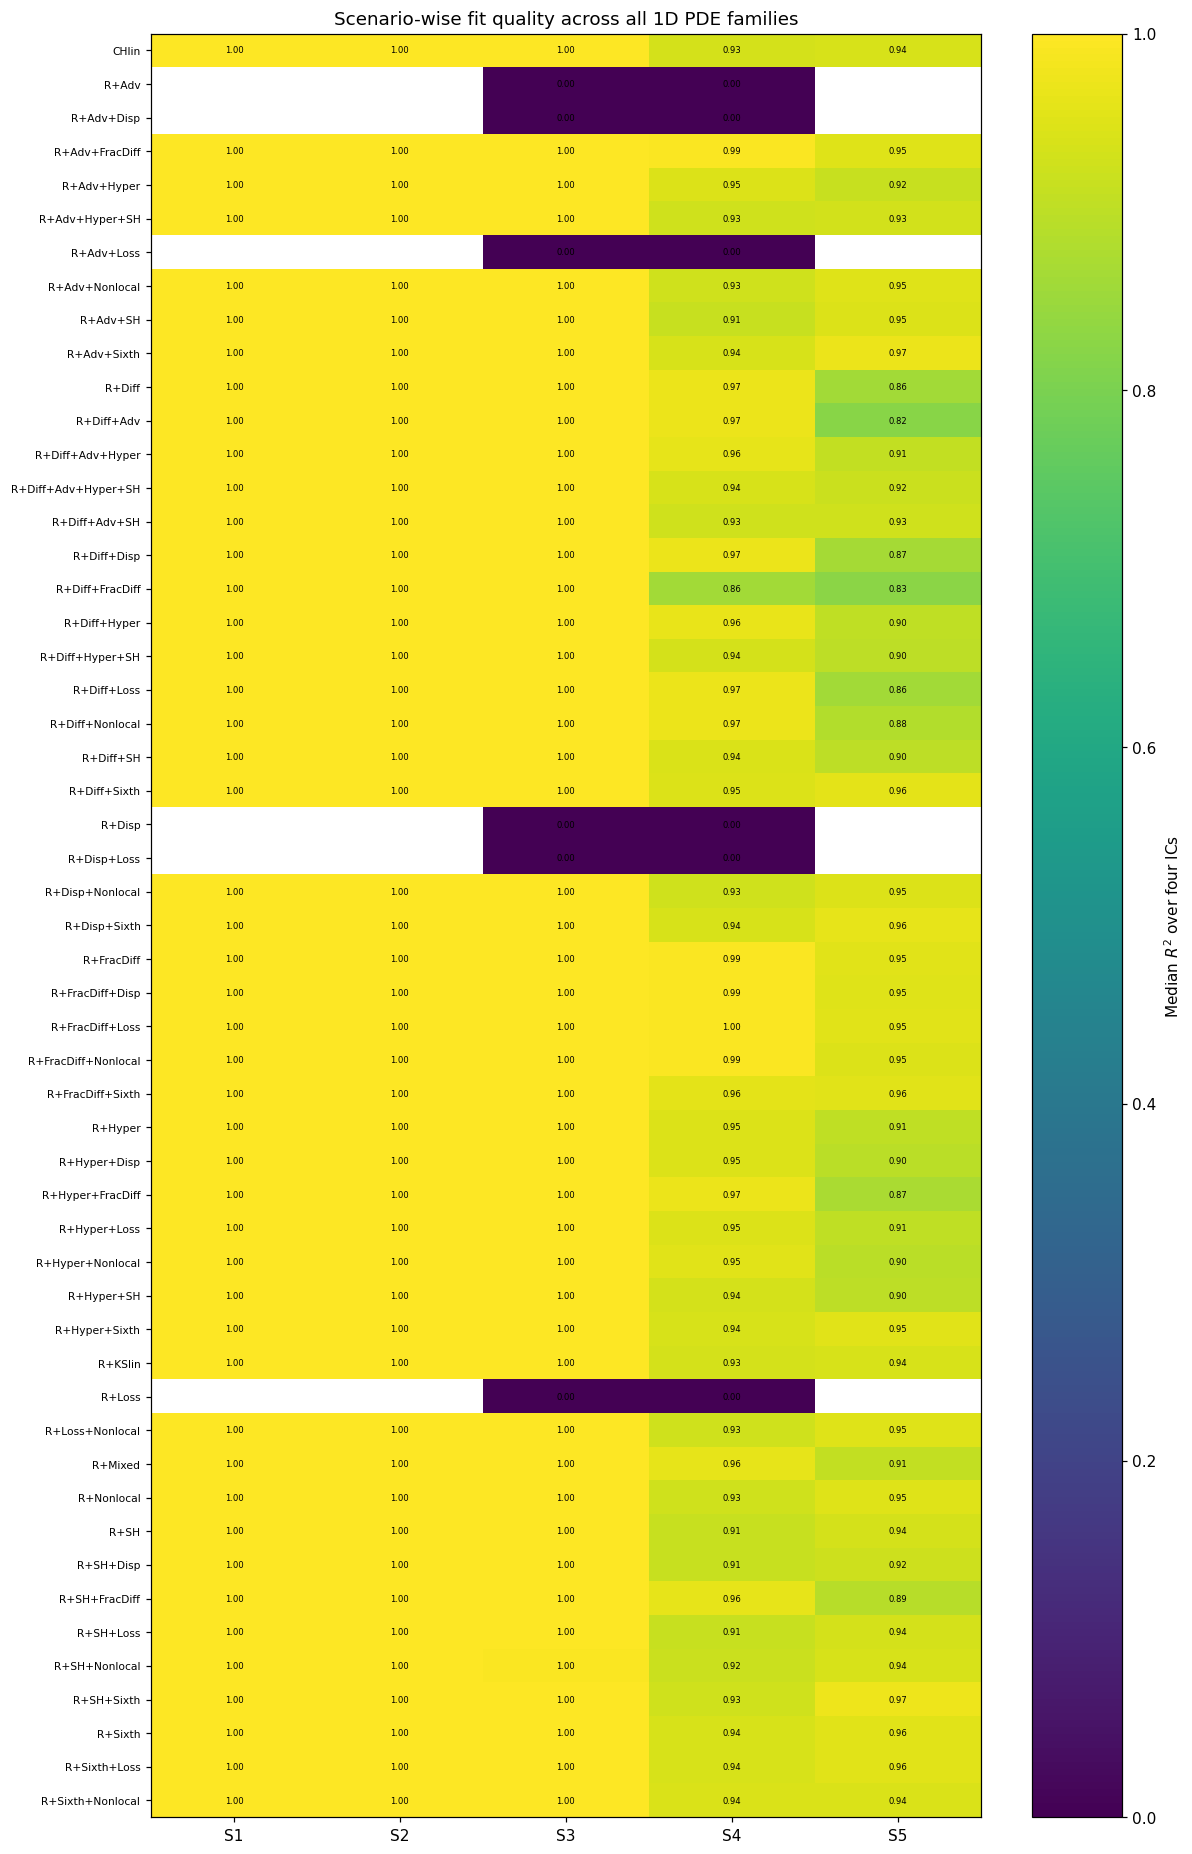

In [18]:

# ============================================================
# FINAL COMPARISON 3 — MEDIAN R2 ACROSS THE FOUR ICs
# ============================================================

R2_MEDIAN_FULL = (
    MASTER_SUMMARY_DF
    .groupby(["PDE","Scenario"],as_index=False)["R2"]
    .median()
    .pivot(index="PDE",columns="Scenario",values="R2")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)

display(R2_MEDIAN_FULL.round(4))

fig,ax = plt.subplots(figsize=(11,max(10,.32*len(R2_MEDIAN_FULL))))
im = ax.imshow(R2_MEDIAN_FULL.values,aspect="auto",vmin=0,vmax=1)

ax.set_xticks(np.arange(5))
ax.set_xticklabels(["S1","S2","S3","S4","S5"])
ax.set_yticks(np.arange(len(R2_MEDIAN_FULL.index)))
ax.set_yticklabels(R2_MEDIAN_FULL.index,fontsize=7)

for i in range(R2_MEDIAN_FULL.shape[0]):
    for j in range(R2_MEDIAN_FULL.shape[1]):
        v=R2_MEDIAN_FULL.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

fig.colorbar(im,ax=ax,label=r"Median $R^2$ over four ICs")
ax.set_title("Scenario-wise fit quality across all 1D PDE families")
plt.tight_layout()
plt.show()


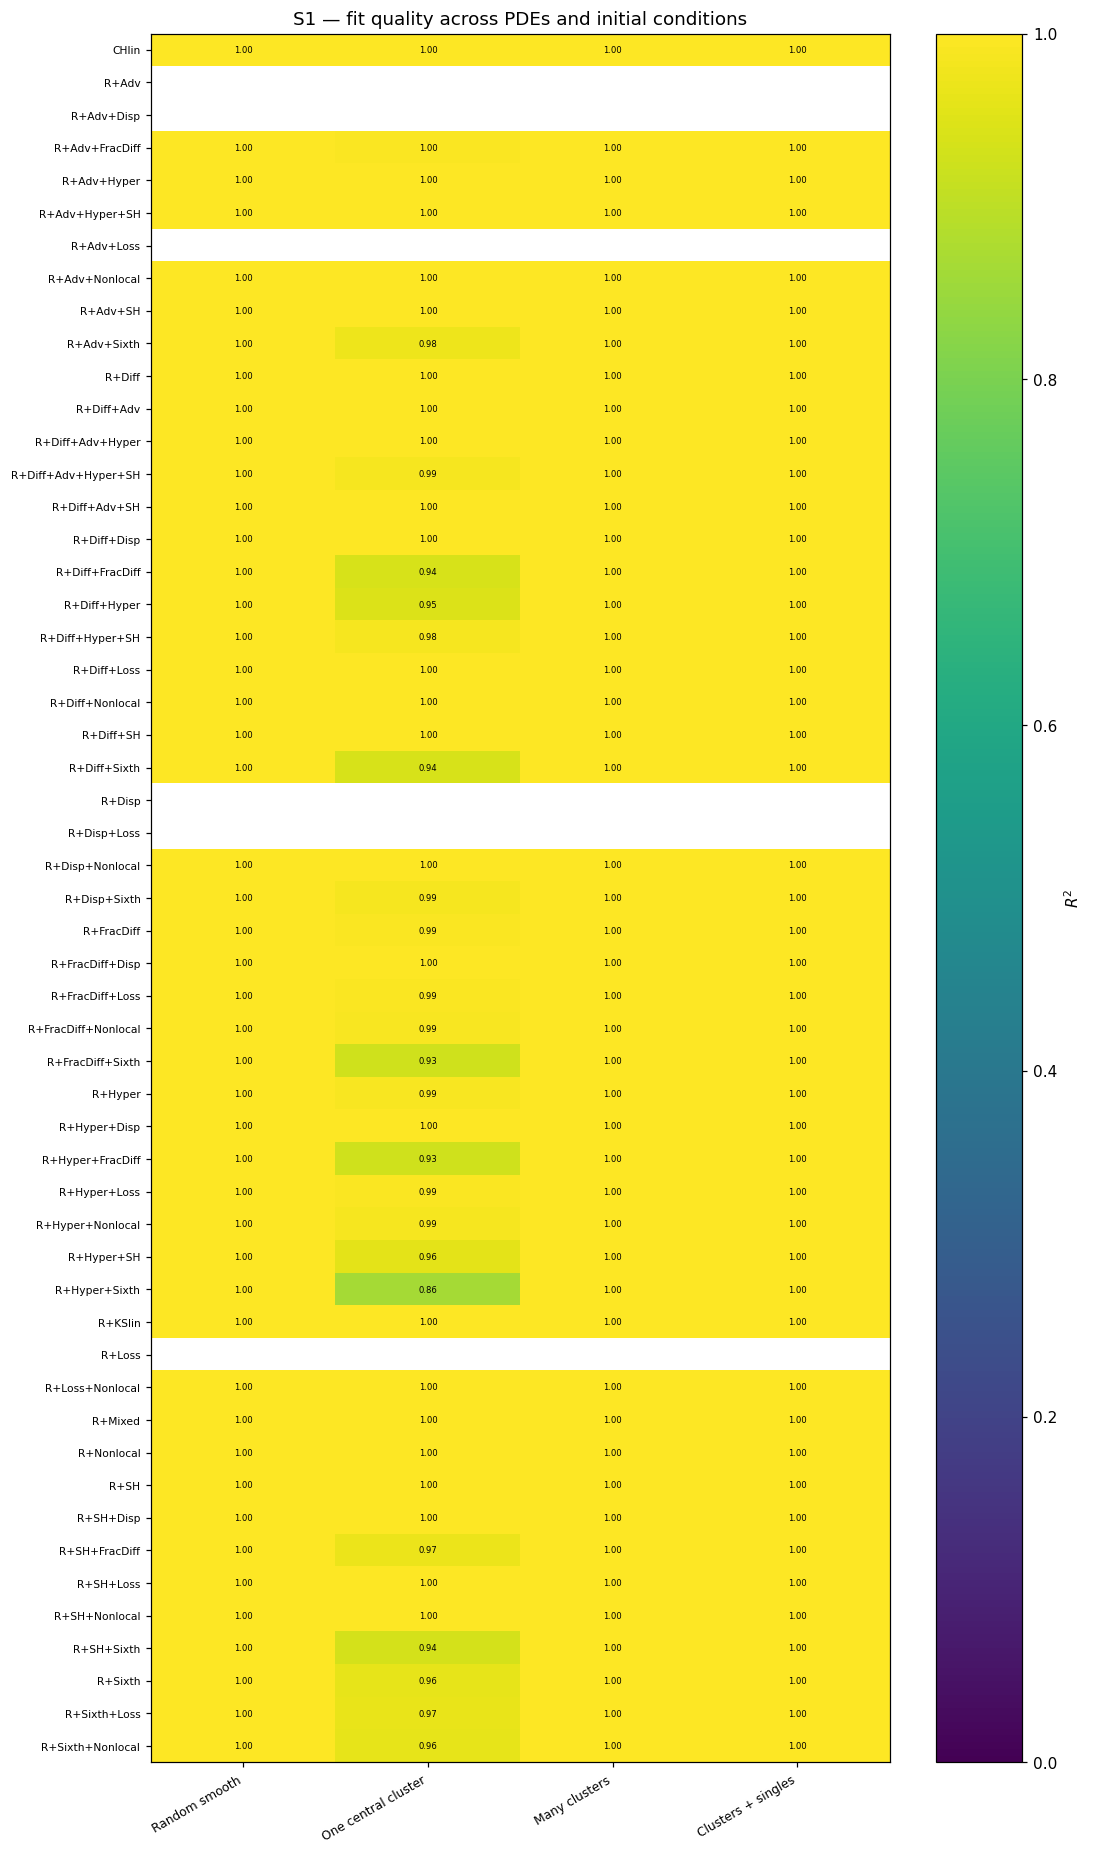

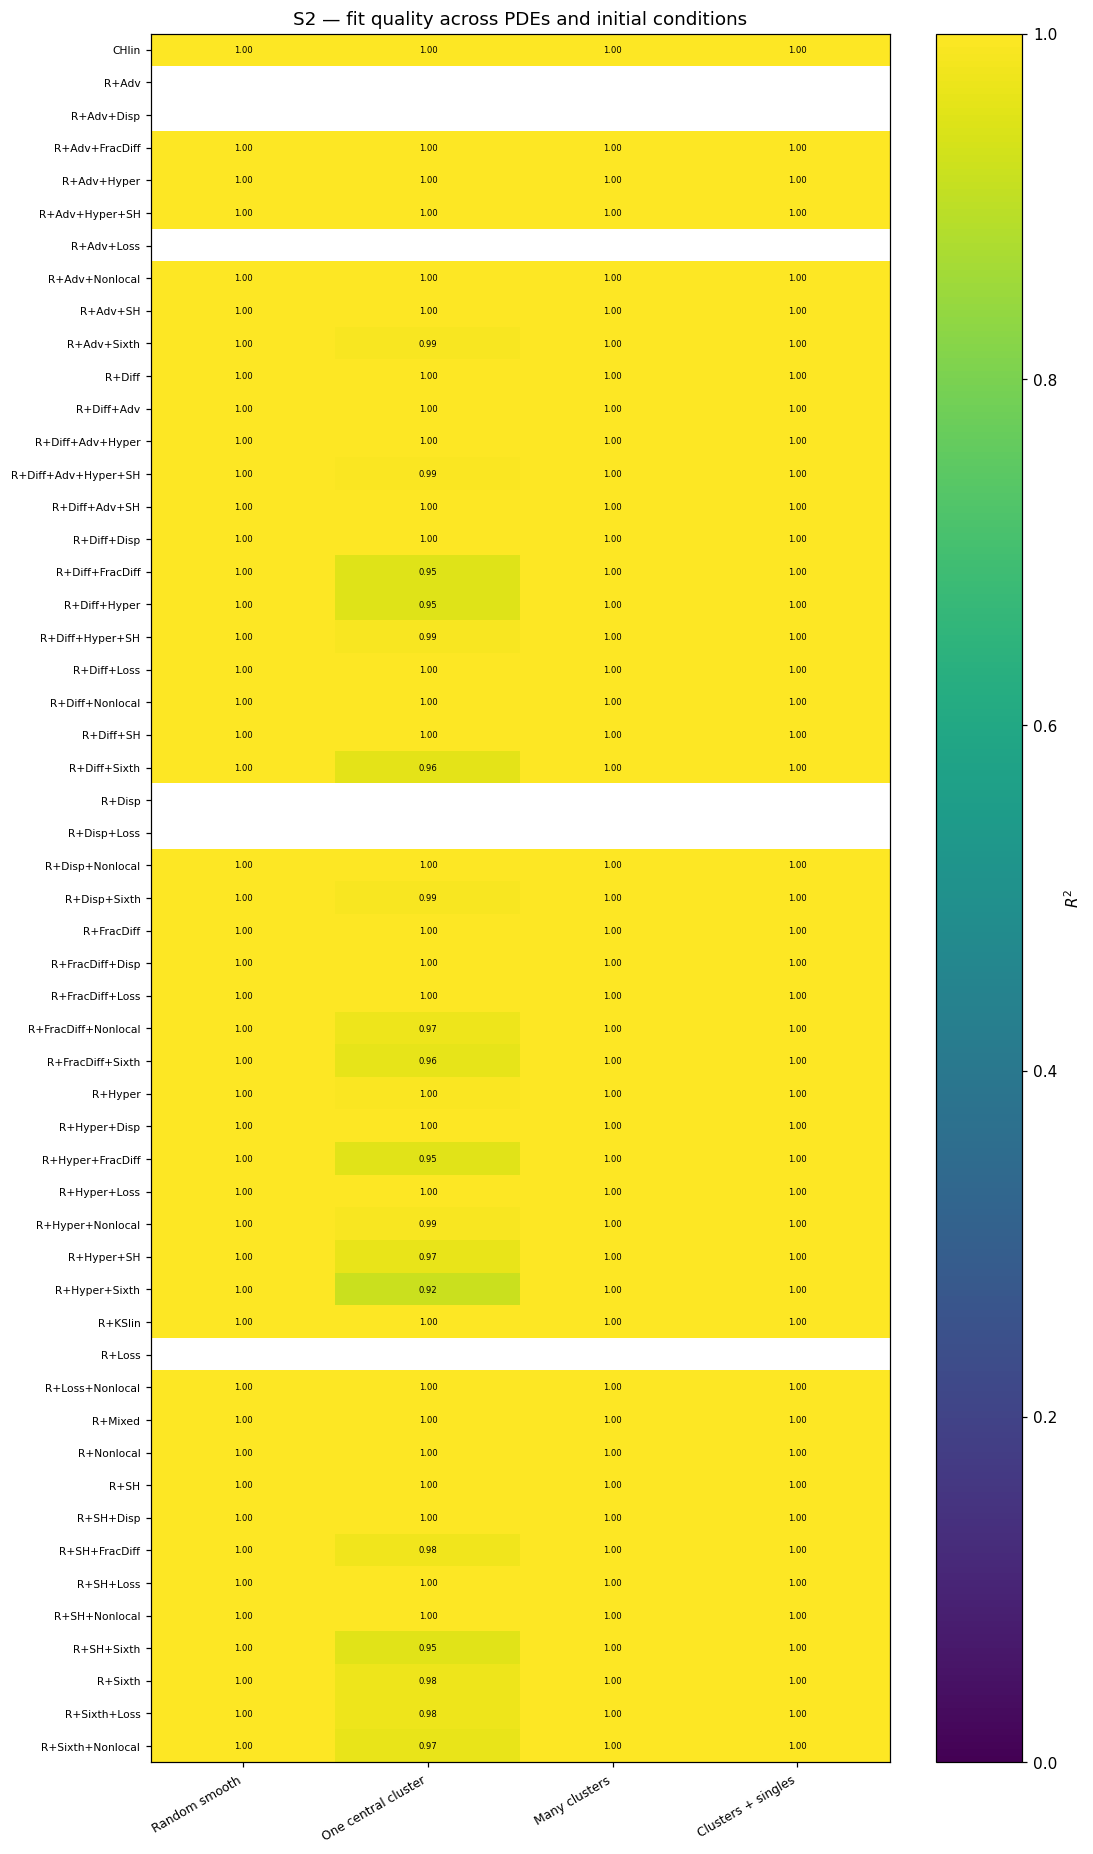

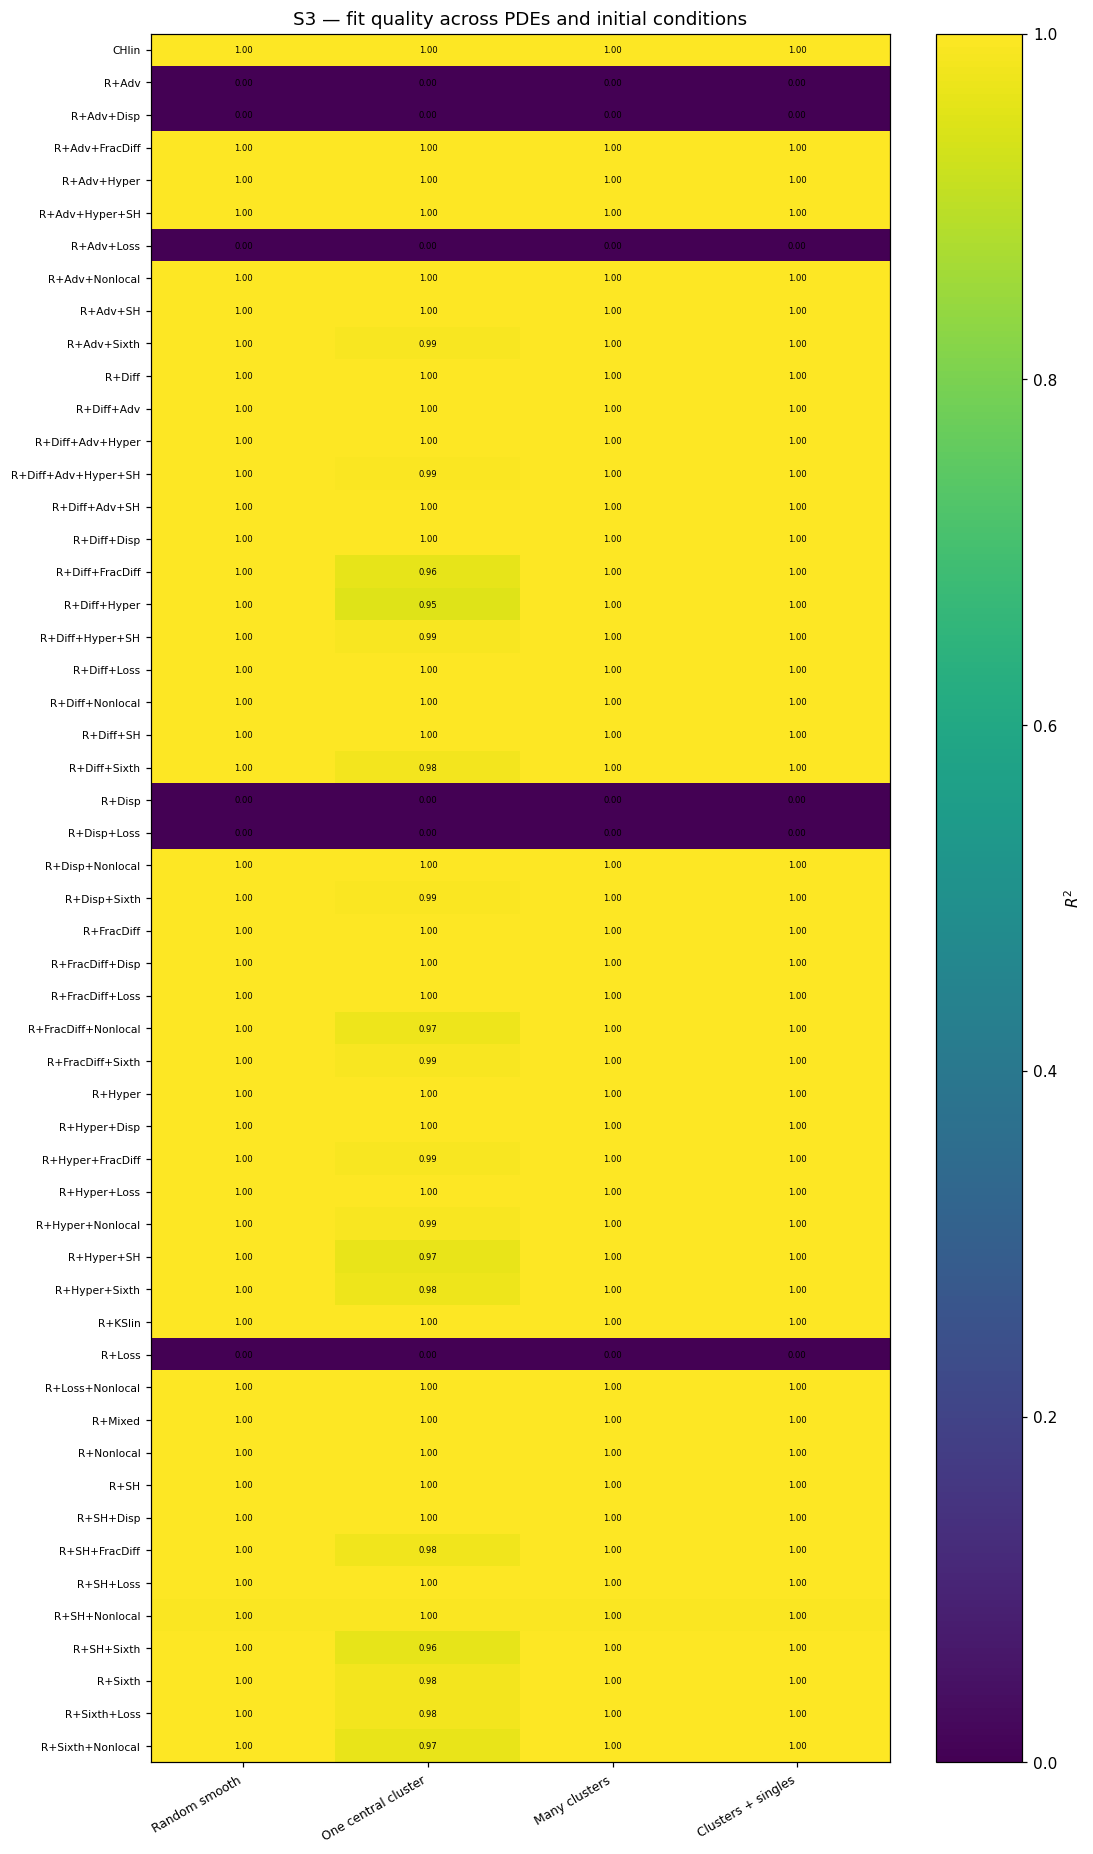

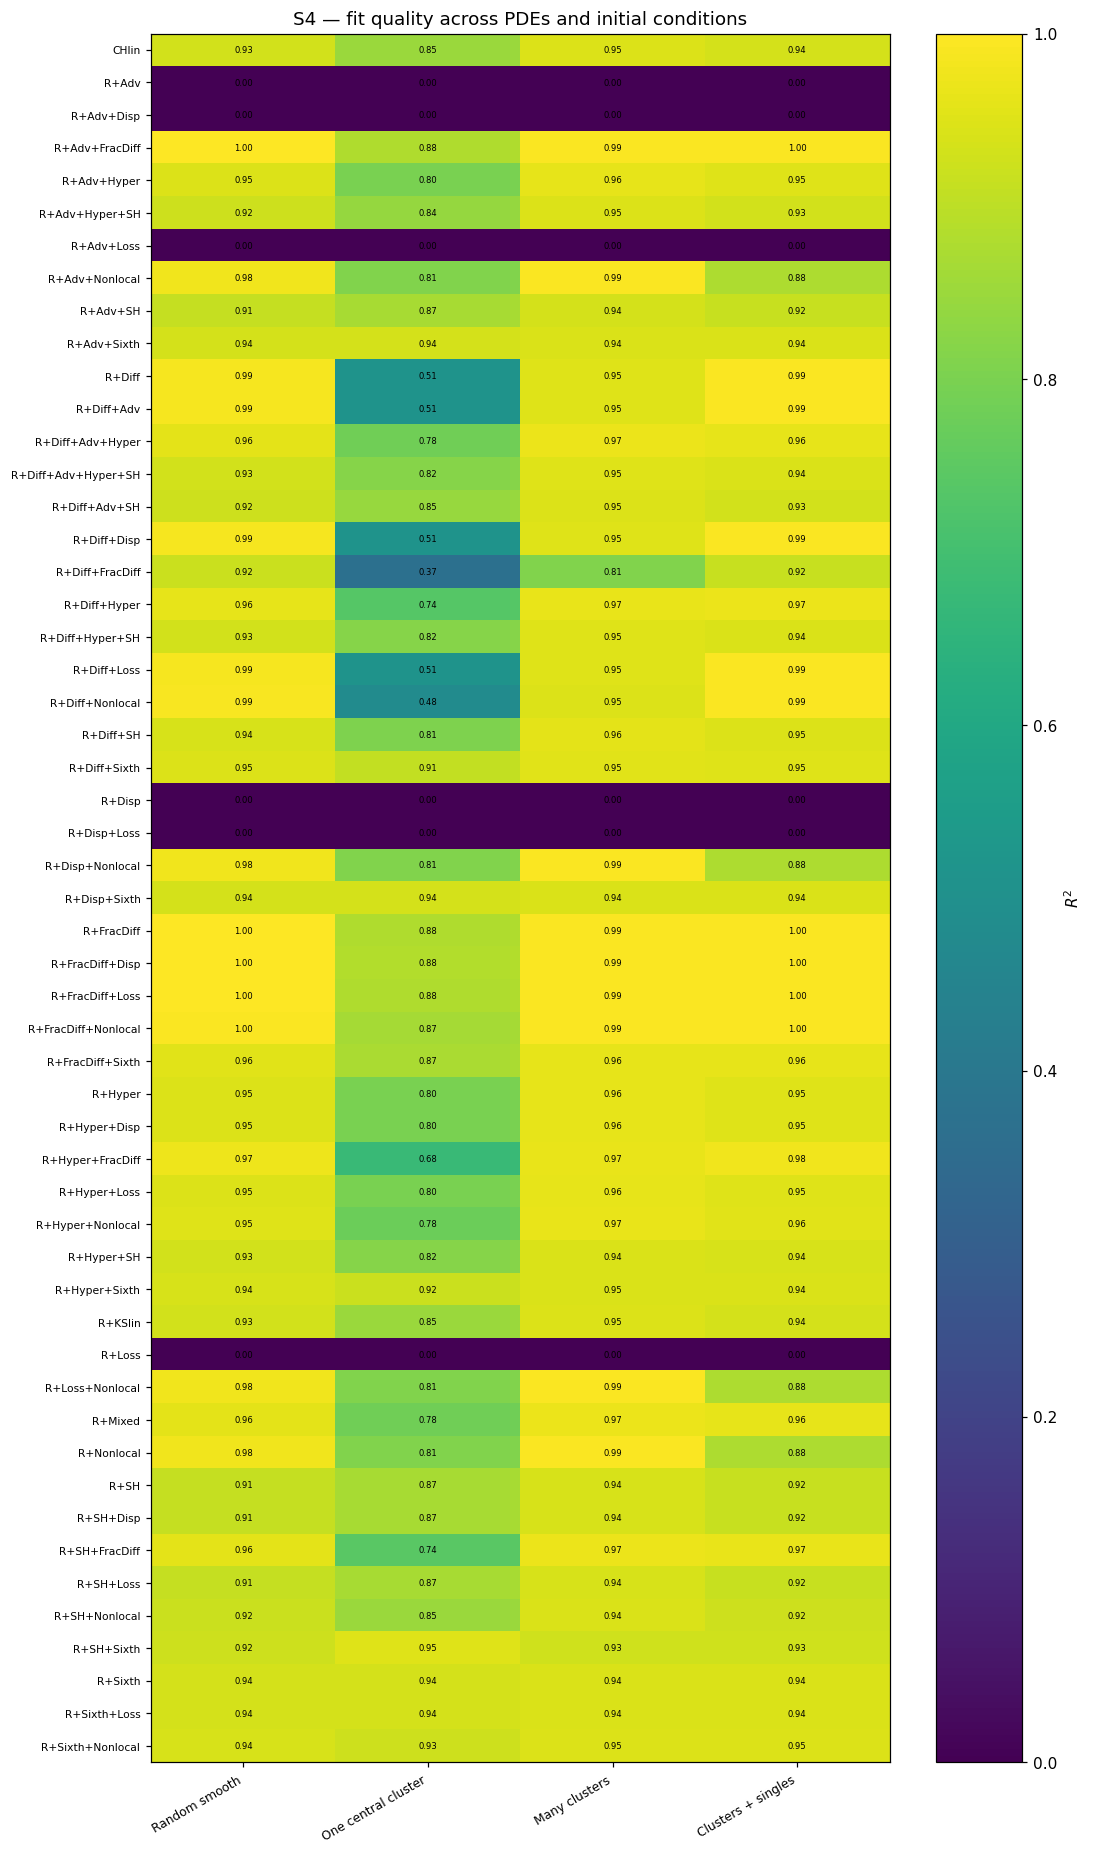

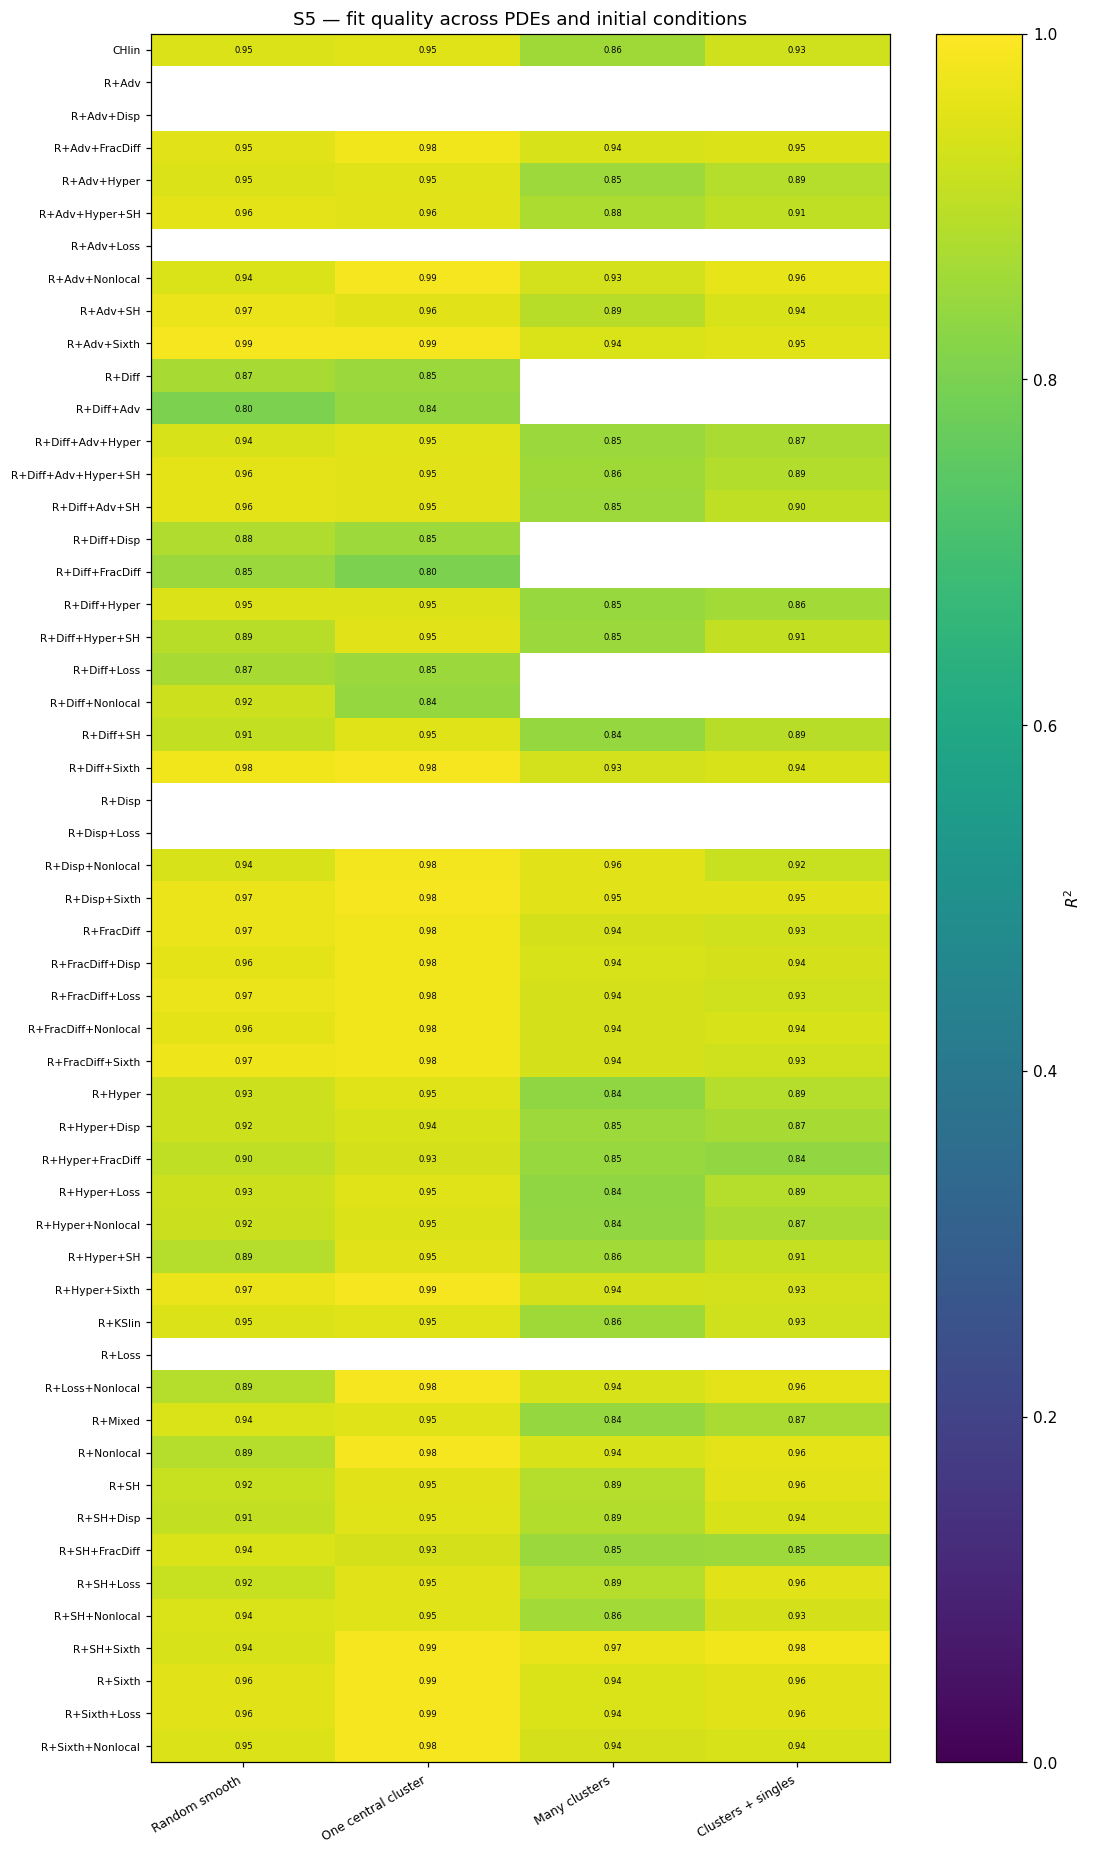

In [19]:

# ============================================================
# FINAL COMPARISON 4 — ONE HEATMAP PER SCENARIO
# ============================================================

for scen in ["S1","S2","S3","S4","S5"]:
    pivot = (
        MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"]==scen]
        .pivot(index="PDE",columns="Initial condition",values="R2")
        .reindex(columns=list(ICs.keys()))
    )

    fig,ax = plt.subplots(figsize=(10,max(10,.32*len(pivot))))
    im = ax.imshow(pivot.values,aspect="auto",vmin=0,vmax=1)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns,rotation=30,ha="right",fontsize=8)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index,fontsize=7)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v=pivot.iloc[i,j]
            if np.isfinite(v):
                ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

    fig.colorbar(im,ax=ax,label=r"$R^2$")
    ax.set_title(f"{scen} — fit quality across PDEs and initial conditions")
    plt.tight_layout()
    plt.show()


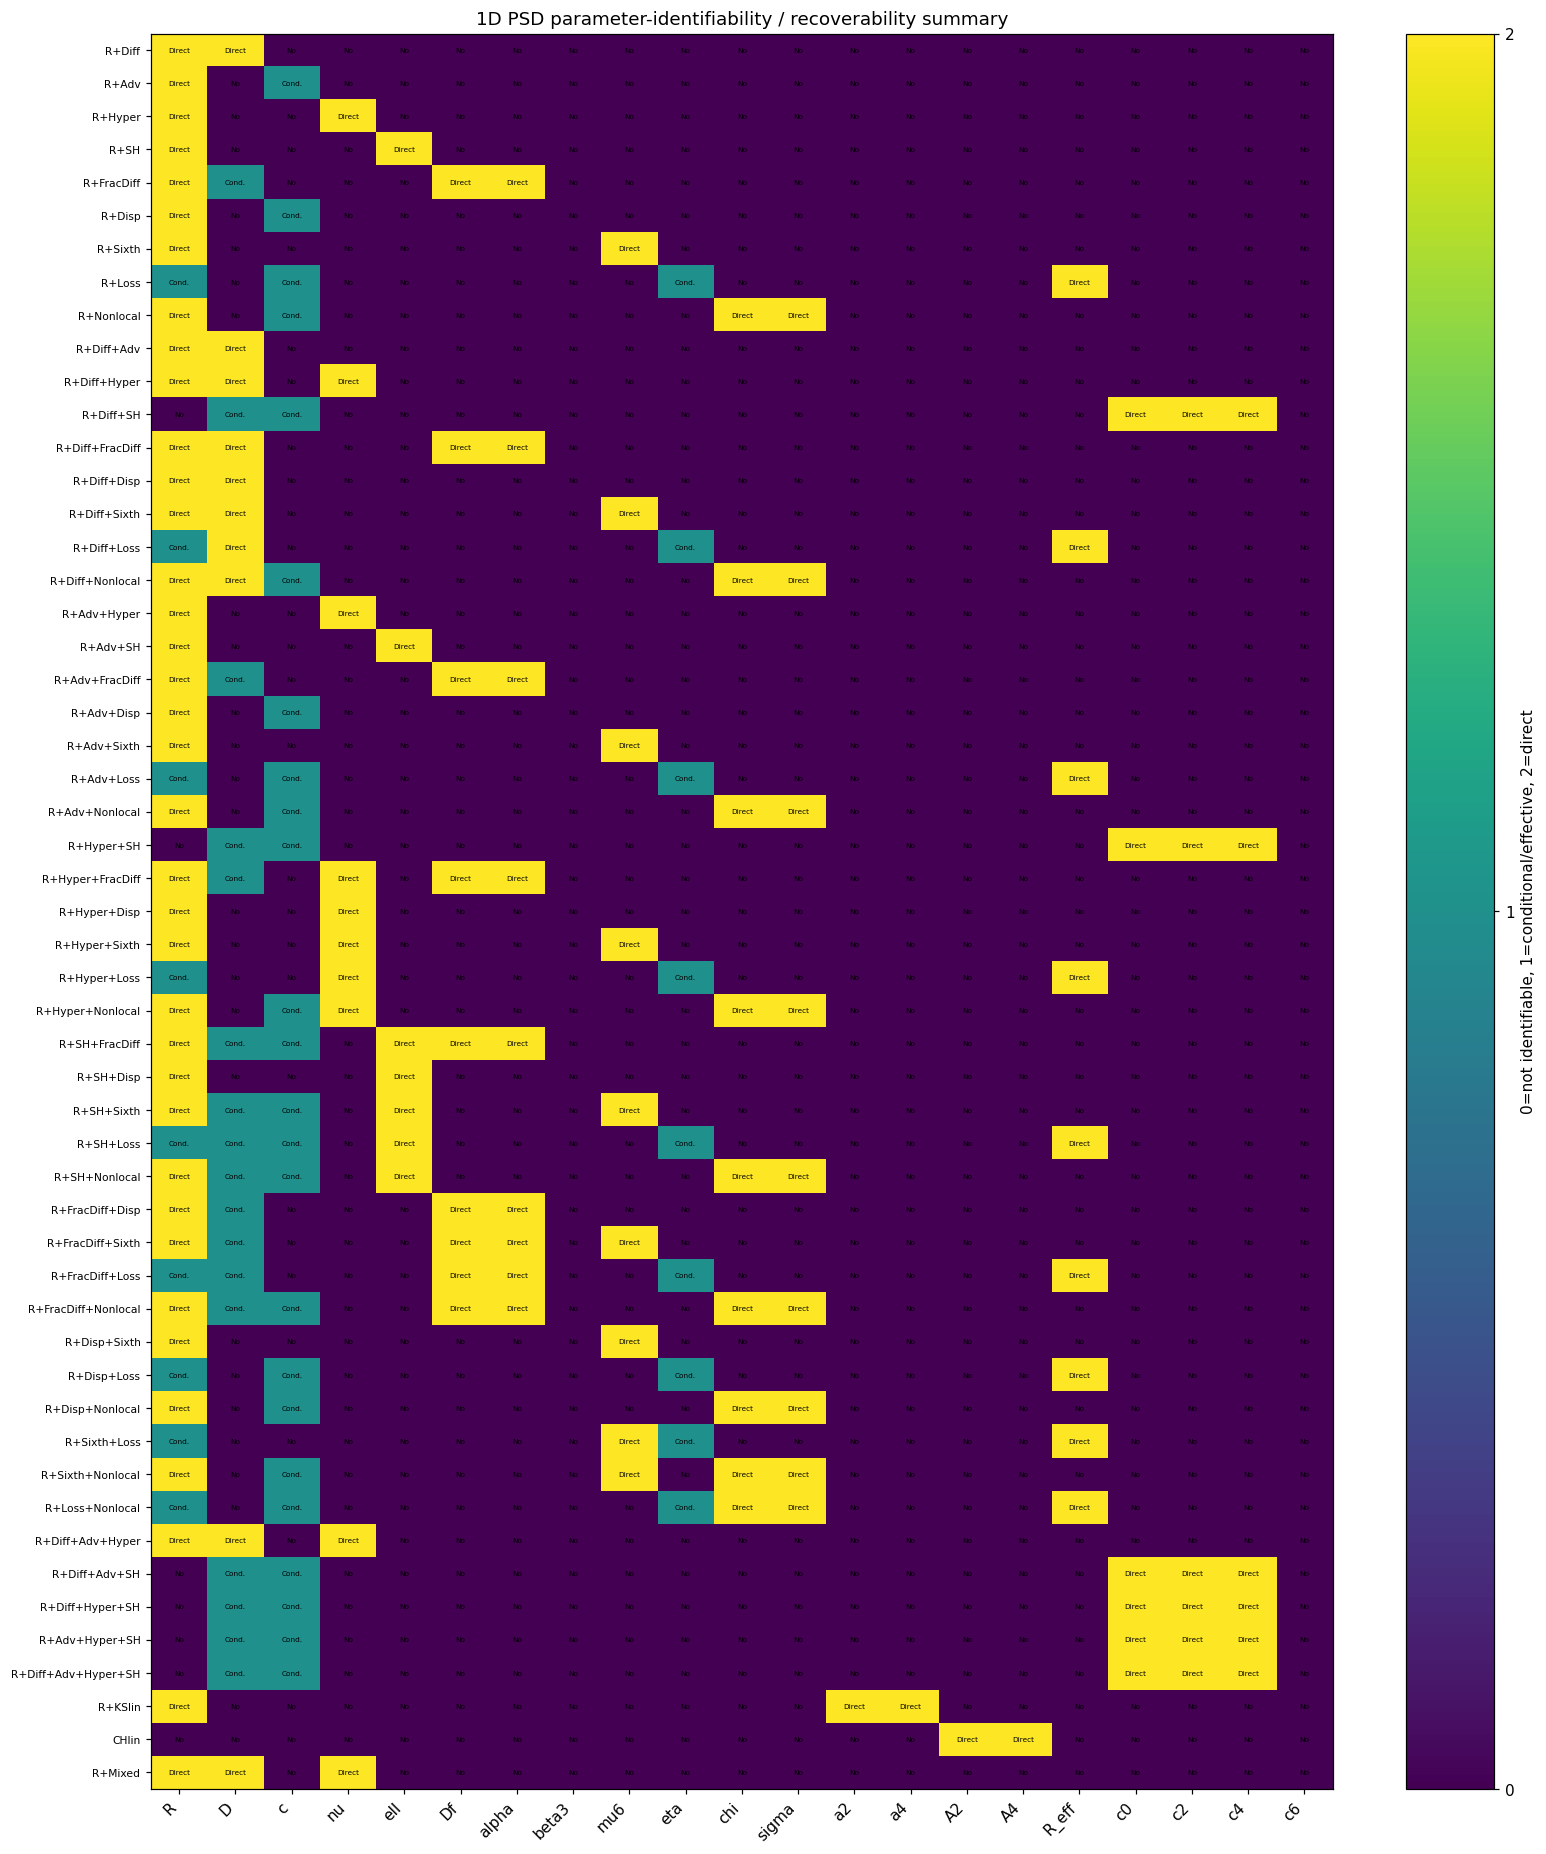

In [20]:

# ============================================================
# FINAL COMPARISON 5 — IDENTIFIABILITY / RECOVERABILITY MAP
# ============================================================

PARAM_ORDER = [
    "R","D","c","nu","ell","Df","alpha","beta3",
    "mu6","eta","chi","sigma","a2","a4","A2","A4",
    "R_eff","c0","c2","c4","c6"
]

mat = np.zeros((len(MODEL_VARIANTS),len(PARAM_ORDER)))

for i,tag in enumerate(MODEL_VARIANTS):
    direct = set(identifiable_names(tag))
    invisible = set(invisible_names(tag))
    s3_text = " ".join(identifiable_combinations_S3(tag))

    for j,p in enumerate(PARAM_ORDER):
        status = 0

        if p in direct:
            status = 2

        if p in invisible:
            status = 0

        # loss primitives only through R_eff
        if "Loss" in MODEL_LIBRARY[tag]["ops"] and p in ("R","eta"):
            status = max(status,1)

        # S3 conditional / ratio recovery
        if p in s3_text and status==0:
            status = 1

        mat[i,j]=status

fig,ax = plt.subplots(figsize=(15,max(10,.32*len(MODEL_VARIANTS))))
im = ax.imshow(mat,aspect="auto",vmin=0,vmax=2)

ax.set_xticks(np.arange(len(PARAM_ORDER)))
ax.set_xticklabels(PARAM_ORDER,rotation=45,ha="right")
ax.set_yticks(np.arange(len(MODEL_VARIANTS)))
ax.set_yticklabels(MODEL_VARIANTS,fontsize=7)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(
            j,i,
            {0:"No",1:"Cond.",2:"Direct"}[int(mat[i,j])],
            ha="center",va="center",fontsize=4.8
        )

fig.colorbar(
    im,ax=ax,ticks=[0,1,2],
    label="0=not identifiable, 1=conditional/effective, 2=direct"
)
ax.set_title("1D PSD parameter-identifiability / recoverability summary")
plt.tight_layout()
plt.show()


Initial condition,Random smooth,One central cluster,Many clusters,Clusters + singles
PDE,,,,
CHlin,0.500,1.000,0.500,0.875
R+Adv,0.000,0.000,0.000,0.000
R+Adv+Disp,0.000,0.000,0.000,0.000
R+Adv+FracDiff,0.750,1.000,1.000,1.000
R+Adv+Hyper,1.000,1.000,0.875,0.750
R+Adv+Hyper+SH,1.000,1.000,0.625,1.000
R+Adv+Loss,0.000,0.000,0.000,0.000
R+Adv+Nonlocal,0.750,1.000,1.000,0.875
R+Adv+SH,0.750,1.000,0.750,1.000


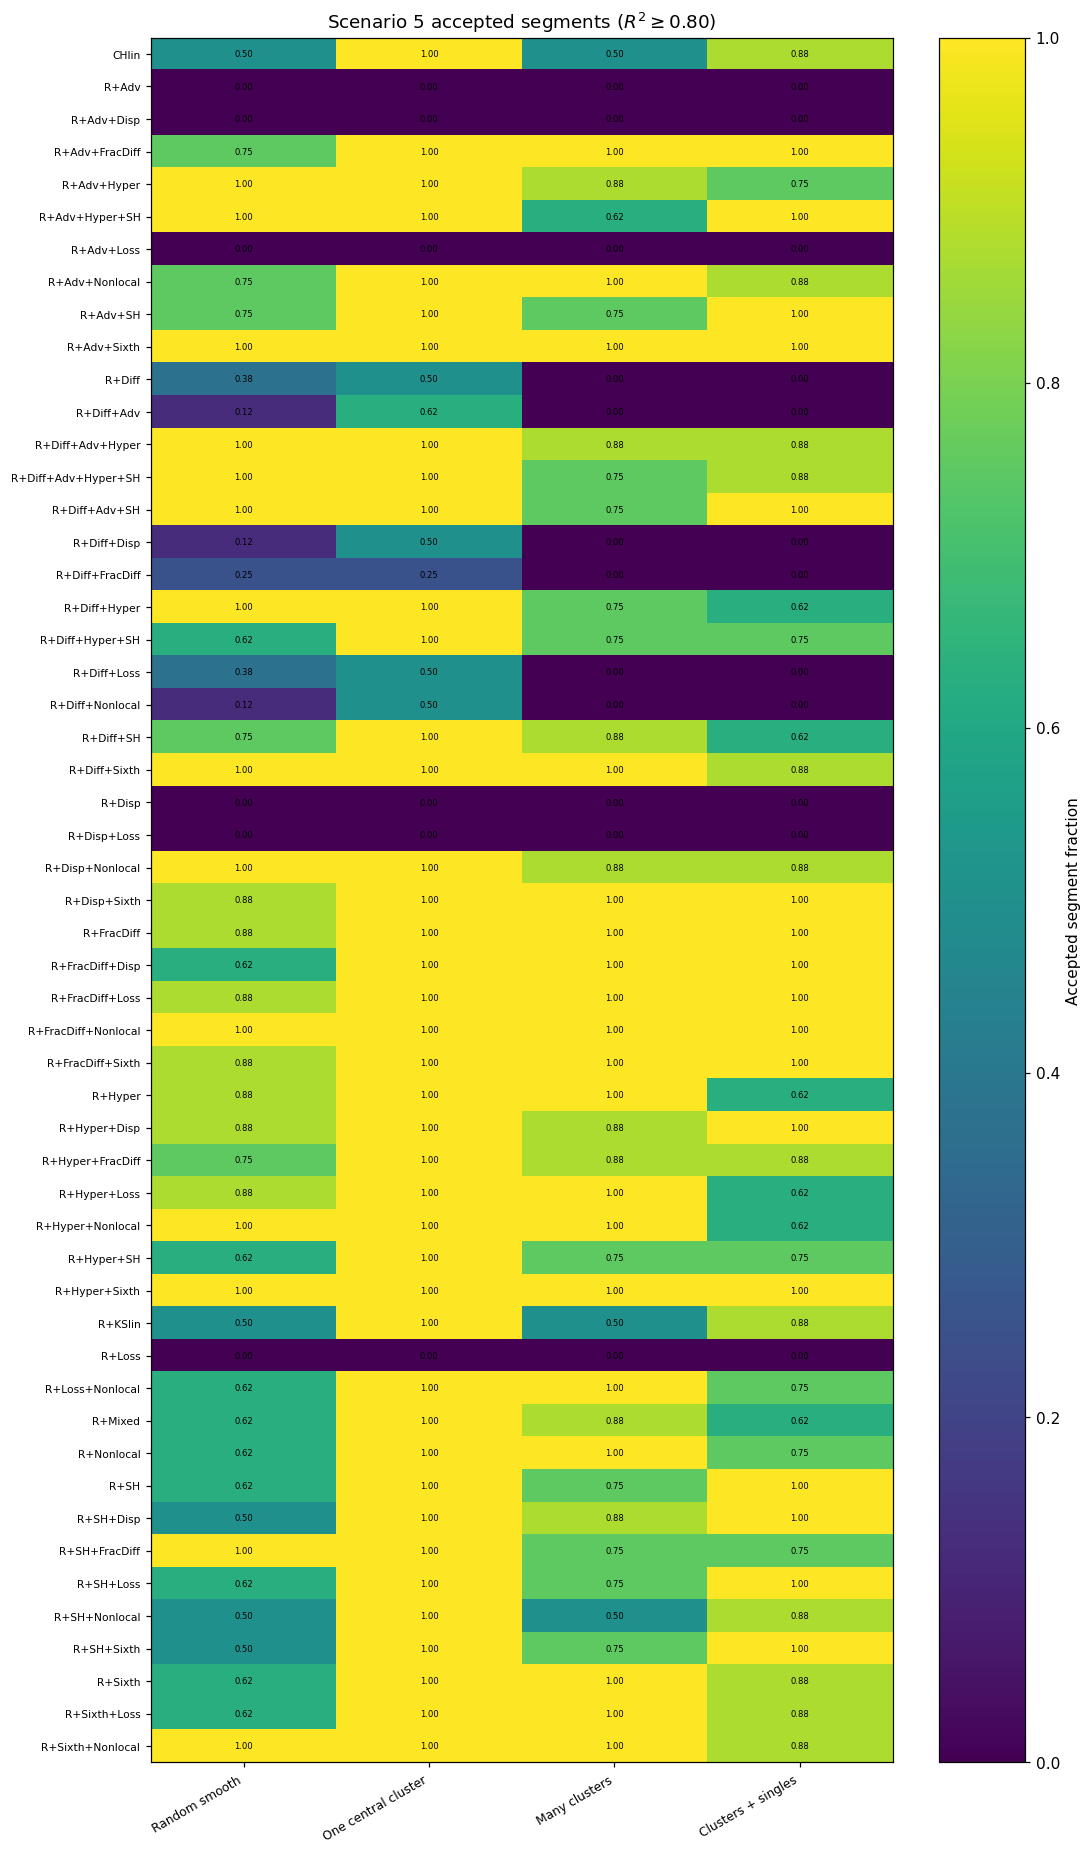

In [21]:

# ============================================================
# FINAL COMPARISON 6 — S5 ACCEPTED-SEGMENT FRACTION
# ============================================================

s5_accept_rows=[]

for tag,res in ALL_RESULTS.items():
    for ic,rr in res["S5"].items():
        if rr is None or rr.get("n_total",0)==0:
            frac=np.nan
        else:
            frac=rr["n_good"]/rr["n_total"]

        s5_accept_rows.append({
            "PDE":tag,
            "Initial condition":ic,
            "Accepted fraction":frac,
        })

S5_ACCEPT_DF=pd.DataFrame(s5_accept_rows)

pivot=S5_ACCEPT_DF.pivot(
    index="PDE",
    columns="Initial condition",
    values="Accepted fraction"
).reindex(columns=list(ICs.keys()))

display(pivot.round(3))

fig,ax=plt.subplots(figsize=(10,max(10,.32*len(pivot))))
im=ax.imshow(pivot.values,aspect="auto",vmin=0,vmax=1)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns,rotation=30,ha="right",fontsize=8)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index,fontsize=7)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v=pivot.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

fig.colorbar(im,ax=ax,label="Accepted segment fraction")
ax.set_title(f"Scenario 5 accepted segments ($R^2 \\geq {R2_MIN:.2f}$)")
plt.tight_layout()
plt.show()


,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments
0,Random smooth,2,NaN,3.0621,NaN,0,2
1,Random smooth,4,NaN,3.0621,NaN,0,4
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6
3,Random smooth,8,2.0305,3.0621,-1.0316,3,8
4,Random smooth,10,2.1147,3.0621,-0.9474,3,10
5,Random smooth,12,NaN,3.0621,NaN,0,0
6,Random smooth,16,NaN,3.0621,NaN,0,0
7,One central cluster,2,NaN,3.0621,NaN,0,2
8,One central cluster,4,1.9594,3.0621,-1.1027,2,4
9,One central cluster,6,1.9238,3.0621,-1.1383,2,6


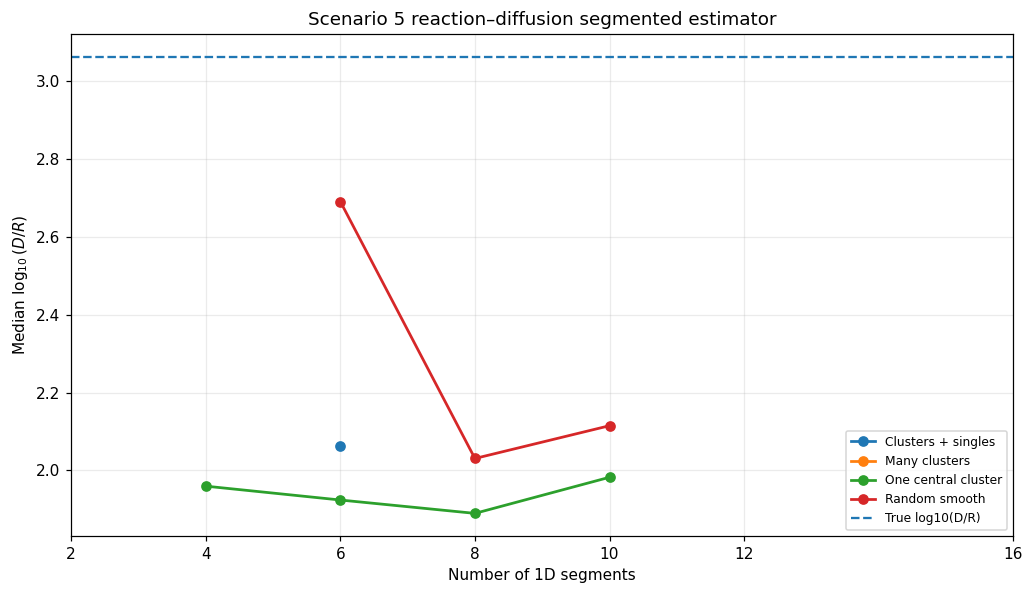

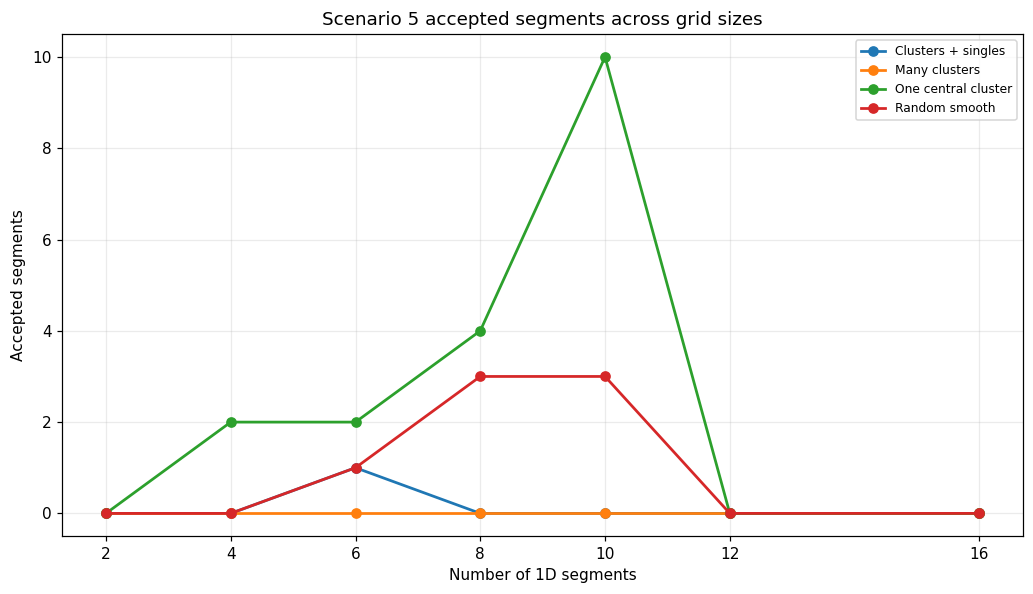

In [22]:

# ============================================================
# FINAL COMPARISON 7 — DETAILED S5 RD GRID SWEEP
# ============================================================

display(S5_RD_GRID_DF.round(4))

fig,ax=plt.subplots(figsize=(9.5,5.5))

for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(
        grp["Grid"],
        grp["Median log10(D/R)"],
        marker="o",
        linewidth=1.8,
        label=ic
    )

ax.axhline(
    TRUE_LOG10_DR,
    linestyle="--",
    linewidth=1.5,
    label="True log10(D/R)"
)

ax.set_xlabel("Number of 1D segments")
ax.set_ylabel(r"Median $\log_{10}(D/R)$")
ax.set_xticks(GRID_LIST)
ax.grid(alpha=.25)
ax.legend(fontsize=8)
ax.set_title("Scenario 5 reaction–diffusion segmented estimator")
plt.tight_layout()
plt.show()

# Accepted-segment count by grid
fig,ax=plt.subplots(figsize=(9.5,5.5))

for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(
        grp["Grid"],
        grp["Good segments"],
        marker="o",
        linewidth=1.8,
        label=ic
    )

ax.set_xlabel("Number of 1D segments")
ax.set_ylabel("Accepted segments")
ax.set_xticks(GRID_LIST)
ax.grid(alpha=.25)
ax.legend(fontsize=8)
ax.set_title("Scenario 5 accepted segments across grid sizes")
plt.tight_layout()
plt.show()


In [23]:

# ============================================================
# FINAL COMPARISON 8 — SCENARIO-SPECIFIC RANKING TABLES
# ============================================================

SCENARIO_RANKINGS={}

for scen in ["S1","S2","S3","S4","S5"]:
    rank = (
        MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"]==scen]
        .groupby("PDE",as_index=False)["R2"]
        .median()
        .rename(columns={"R2":"Median_R2"})
        .sort_values("Median_R2",ascending=False)
        .reset_index(drop=True)
    )

    rank["Rank"]=np.arange(1,len(rank)+1)
    SCENARIO_RANKINGS[scen]=rank[["Rank","PDE","Median_R2"]]

    print(f"\n{scen} ranking:")
    display(SCENARIO_RANKINGS[scen].head(20))

# Known-time recovery ranking using parameter error
KNOWN_TIME_RANKING = (
    PARAM_ERROR_DF
    .pivot(index="PDE",columns="Scenario",values="MedianAbsPercentError")
    .reindex(columns=["S1","S2"])
)

KNOWN_TIME_RANKING["MedianKnownTimeError"] = KNOWN_TIME_RANKING.median(axis=1)
KNOWN_TIME_RANKING = KNOWN_TIME_RANKING.sort_values("MedianKnownTimeError")

print("Known-time parameter-recovery ranking:")
display(KNOWN_TIME_RANKING.head(25).round(3))



S1 ranking:


,Rank,PDE,Median_R2
0,1,CHlin,1.0
1,2,R+Adv+FracDiff,1.0
2,3,R+Adv+Hyper,1.0
3,4,R+Adv+Hyper+SH,1.0
4,5,R+Adv+Nonlocal,1.0
5,6,R+Adv+SH,1.0
6,7,R+Adv+Sixth,1.0
7,8,R+Diff,1.0
8,9,R+Diff+Adv,1.0
9,10,R+Diff+Adv+Hyper,1.0



S2 ranking:


,Rank,PDE,Median_R2
0,1,CHlin,1.0
1,2,R+Adv+FracDiff,1.0
2,3,R+Adv+Hyper,1.0
3,4,R+Adv+Hyper+SH,1.0
4,5,R+Adv+Nonlocal,1.0
5,6,R+Adv+SH,1.0
6,7,R+Adv+Sixth,1.0
7,8,R+Diff,1.0
8,9,R+Diff+Adv,1.0
9,10,R+Diff+Adv+Hyper,1.0



S3 ranking:


...

,Rank,PDE,Median_R2
0,1,R+FracDiff+Loss,0.995020
1,2,R+Adv+FracDiff,0.994978
2,3,R+FracDiff,0.994914
3,4,R+FracDiff+Disp,0.994873
4,5,R+FracDiff+Nonlocal,0.994305
5,6,R+Hyper+FracDiff,0.969993
6,7,R+Diff,0.969829
7,8,R+Diff+Loss,0.969748
8,9,R+Diff+Adv,0.969722
9,10,R+Diff+Disp,0.969720



S5 ranking:


,Rank,PDE,Median_R2
0,1,R+SH+Sixth,0.972834
1,2,R+Adv+Sixth,0.969120
2,3,R+Disp+Sixth,0.962967
3,4,R+Diff+Sixth,0.957756
4,5,R+Sixth,0.955909
5,6,R+Sixth+Loss,0.955909
6,7,R+FracDiff+Sixth,0.955041
7,8,R+FracDiff,0.954339
8,9,R+FracDiff+Loss,0.954339
9,10,R+Hyper+Sixth,0.953658


Known-time parameter-recovery ranking:


Scenario,S1,S2,MedianKnownTimeError
PDE,,,
R+Adv,0.0,0.0,0.0
R+Disp+Nonlocal,0.0,0.0,0.0
R+Adv+Nonlocal,0.0,0.0,0.0
R+Adv+Disp,0.0,0.0,0.0
R+Disp+Loss,0.0,0.0,0.0
R+Disp,0.0,0.0,0.0
R+Adv+SH,0.0,0.0,0.0
R+Adv+Loss,0.0,0.0,0.0
R+Loss,0.0,0.0,0.0



# 16. Final summary tables and exports

The notebook now ends with both numeric tables and the complete plotting set.

The main outputs are:

- `MASTER_SUMMARY_DF`: every PDE × scenario × IC;
- `MASTER_R2_MATRIX`: one row per PDE × IC with S1–S5 columns;
- `PDE_SCENARIO_MEDIAN_R2`: one row per PDE, median over the four ICs;
- `PARAM_ERROR_DF`: known-time S1/S2 recovery errors;
- `S5_ACCEPT_DF`: Scenario-5 accepted-segment fractions;
- `S5_RD_GRID_DF`: detailed reaction–diffusion segmentation sweep;
- `SCENARIO_RANKINGS`: separate PDE rankings for each scenario.

The scenario-specific rankings are kept separate because the meaning of \(R^2\) differs between S1–S3, S4, and S5.


In [24]:

# ============================================================
# FINAL EXPORT CELL
# ============================================================

MASTER_SUMMARY_DF.to_csv(
    "MASTER2_1D_ALL_PDEs_ALL_5_SCENARIOS_tidy.csv",
    index=False
)

MASTER_R2_MATRIX.to_csv(
    "MASTER2_1D_ALL_PDEs_R2_matrix.csv"
)

PDE_SCENARIO_MEDIAN_R2.to_csv(
    "MASTER2_1D_PDE_scenario_median_R2.csv"
)

PARAM_ERROR_DF.to_csv(
    "MASTER2_1D_known_time_parameter_error_long.csv",
    index=False
)

S5_ACCEPT_DF.to_csv(
    "MASTER2_1D_S5_accepted_segment_fraction.csv",
    index=False
)

S5_RD_GRID_DF.to_csv(
    "MASTER2_1D_S5_RD_grid_sweep.csv",
    index=False
)

for scen,df in SCENARIO_RANKINGS.items():
    df.to_csv(
        f"MASTER2_1D_{scen}_ranking.csv",
        index=False
    )

print("Complete 1D notebook outputs exported.")


Complete 1D notebook outputs exported.
